# MMMU-Pro Eval300 × InternVL3.5-8B Q4_K_M — P2 Per-Image Scene Graph
## Production, two-stage, resume-safe | MAX=8192 | CTX=16384 | Local Kaggle Input

This is a P2 experiment. This notebook preserves the same P2 per-image scene-graph protocol and uses the
already-attached InternVL3.5-8B Kaggle artifacts.

Expected model bundle layout:

```text
<InternVL Kaggle input root>/
├── internvl35_8b_saved/
│   ├── InternVL3_5-8B-Q4_K_M.gguf
│   ├── mmproj-model-f16.gguf
│   └── model_manifest.json
└── internvl35_llama_runtime/
    └── llama
```

A sibling `llama_runtime/llama` is also accepted for compatibility with older
saved outputs. The outer Kaggle mount slug is not hard-coded; candidates are
discovered under `/kaggle/input` and verified by SHA-256.

The scientific P2 pipeline is unchanged: one independent scene-graph call per
unique image column, role-specific question/option graph prompts, verbatim graph
checkpointing, and final interleaving of each image occurrence immediately with
its graph. Repeated image references reuse the one graph generated for that
source image.

Generation remains `MAX_TOKENS=8192`, `CTX_SIZE=16384`, `temperature=0.0`,
and `seed=42`. No model-specific thinking request parameter is sent for
InternVL3.5; llama reasoning parsing is disabled with `--reasoning off`.


## Revision note — reconstruct Eval300 from a frozen ordered ID list

The evaluation subset is reconstructed from the official Hugging Face source:

```text
MMMU/MMMU_Pro / standard (10 options) / test
```

at the exact immutable source revision:

```text
563f3e84bb3b90893083a1f039cfa13077f2302b
```

The notebook first downloads all 1,730 rows in this source setting and then
performs exact ID lookup using `selected_ids.txt`. There is no re-sampling,
nearest-match lookup, question-text matching, or subject-based replacement.

The line order of `selected_ids.txt` is the evaluation order. Candidate options
are preserved row-faithfully:

- answer letters are derived dynamically from each row's actual option count;
- every option is preserved exactly as published;
- no option is padded, truncated, invented, or rewritten;
- every gold label must be valid for the row's actual choice set;
- the selected option-count distribution is archived.

Because the inference notebook receives only the frozen ID list (not the
few-shot pool), it does **not** claim to independently recompute few-shot
disjointness. That property belongs to the upstream dataset-construction stage.
This notebook instead proves that it evaluates the exact cryptographically
pinned ID list produced by that stage.


## Fixed two-stage generation protocol

Both P2 stages use:

```text
temperature = 0.0
top_p       = not sent
top_k       = not sent
seed        = 42
max_tokens  = 8192
ctx_size    = 16384
stream      = false
```

No model-specific thinking request parameter or thinking system prompt is sent
for InternVL3.5. The local llama server uses `--reasoning off` only as a
reasoning-parser/transport control.

The P2 scene-graph and final-answer templates are preserved from the supplied
P2 notebook.


# 0. Kaggle resume protocol

Attach the local InternVL3.5-8B Kaggle input containing:

```text
internvl35_8b_saved/InternVL3_5-8B-Q4_K_M.gguf
internvl35_8b_saved/mmproj-model-f16.gguf
internvl35_8b_saved/model_manifest.json
```

and the matching local llama runtime from the same saved notebook output,
preferably:

```text
internvl35_llama_runtime/llama
```

Then attach the same frozen `selected_ids.txt`, use **2× NVIDIA T4**, and run all
cells. No model/projector download fallback exists in this notebook.


# 1. Install only missing lightweight Python packages

The InternVL3.5 model, multimodal projector, and llama runtime are read from
Kaggle Input and are not downloaded by this notebook.


In [1]:
import importlib.util, subprocess, sys

requirements = {
    "datasets": "datasets>=3.0",
    "huggingface_hub": "huggingface_hub>=0.24",
    "requests": "requests>=2.31",
    "sklearn": "scikit-learn>=1.3",
    "statsmodels": "statsmodels>=0.14",
    "PIL": "Pillow>=10",
    "pandas": "pandas>=2",
    "numpy": "numpy>=1.26",
    "matplotlib": "matplotlib>=3.8",
}

to_install = [
    spec for mod, spec in requirements.items()
    if importlib.util.find_spec(mod) is None
]

if to_install:
    print("Installing only missing lightweight packages:", to_install)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *to_install]
    )
else:
    print("All required Python packages already available.")

print("No model/runtime/MMMU-Pro download was performed by this cell.")


All required Python packages already available.
No model/runtime/MMMU-Pro download was performed by this cell.


# 2. Frozen experimental configuration

The block below is the protocol control plane. Do not alter it between runs
that will be merged into one reported experiment.


In [2]:
import os, io, re, ast, json, time, math, base64, random, string, shutil
import hashlib, html, platform, subprocess, sys, shlex, threading, logging, importlib.metadata
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from PIL import Image
from tqdm.auto import tqdm
from datasets import load_dataset, Image as HFImage
from huggingface_hub import snapshot_download
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    confusion_matrix,
)
from statsmodels.stats.proportion import proportion_confint

EXPERIMENT_ID = (
    "MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__"
    "P2-PerImageSceneGraph__LocalLlamaCpp__ImageGraphInterleaved__"
    "ValidatedTwoStageResume__LongDeferredTimeout__"
    "Temperature0__Seed42__MAX8192__CTX16384__LocalInput"
)
PROMPT_ID = "P2-PerImageSceneGraph"
PROMPT_FAMILY = "Two-stage per-image question-conditioned scene-graph prompting"
EVALUATION_COHORT_ID = "MMMUPro-frozen-balanced-eval300-v1"

MODEL = "InternVL3.5-8B-Q4_K_M"
MODEL_API_NAME = "internvl3.5-8b"
BASE_MODEL = "OpenGVLab/InternVL3_5-8B"
MODEL_REPO = "lmstudio-community/InternVL3_5-8B-GGUF"
QUANTIZATION = "Q4_K_M"
MODEL_FILENAME = "InternVL3_5-8B-Q4_K_M.gguf"
MMPROJ_FILENAME = "mmproj-model-f16.gguf"
MMPROJ_PRECISION = "F16"

MODEL_ARTIFACT_REVISION = "ae2ec0fbf3e4abb20a33e9d682c5ebf33f638ab7"
MMPROJ_ARTIFACT_REVISION = "98b41ac52d1cfb464694a45faab81ab685ad2dfb"
MODEL_SHA256 = "2809043479b8d3aab30378766c7a2a4bd93eedd97c86efc6d65d627fd680faba"
MMPROJ_SHA256 = "212cc090f81ea2981b870186d4b424fae69489a5313a14e52ffdb2e877852389"

PROVIDER = "local llama.cpp"
API_METHOD = "OpenAI-compatible /v1/chat/completions"
API_MODE = "local stateless HTTP"
SDK_PIN = (
    "llama.app build 10679 commit 50f068fff; exact local binary SHA-256 pinned"
)
LLAMA_CPP_COMMIT = "50f068fff"
LLAMA_RUNTIME_SHA256 = "29cf4dddaad7d8249546e1258e553e12435749345db37905a5dd0c5c35e3e36f"
LLAMA_RUNTIME_POLICY = (
    "use only the attached local InternVL llama runtime; require exact "
    "SHA-256 and build-10679 / 50f068fff version identity"
)

# Local Kaggle input discovery. The top-level input slug is intentionally not
# hard-coded; the bundle is identified by filenames + hashes.
INPUT_ROOT = Path("/kaggle/input")
LOCAL_MODEL_DIRNAME = "internvl35_8b_saved"
LOCAL_RUNTIME_DIRNAME = "internvl35_llama_runtime"
LOCAL_MANIFEST_FILENAME = "model_manifest.json"


DATASET_REPO = "MMMU/MMMU_Pro"
DATASET_CONFIG = "standard (10 options)"
DATASET_SUBDIR = "standard (10 options)"
DATASET_SPLIT = "test"
DATASET_REVISION = "563f3e84bb3b90893083a1f039cfa13077f2302b"
REVISION_SOURCE = "hard-pinned full Hugging Face commit SHA"
EXPECTED_SOURCE_N = 1730
EXPECTED_N = 300

EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION = {
    2: 28, 3: 42, 4: 125, 5: 41, 6: 16, 7: 12,
    8: 31, 9: 221, 10: 1213, 12: 1,
}

SELECTION_PROTOCOL_NAME = (
    "fixed ordered selected_ids.txt; exact ID extraction from pinned official "
    "MMMU-Pro standard (10 options) test source; no resampling"
)
EXPECTED_SELECTED_IDS_CANONICAL_SHA256 = (
    "db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3"
)

INPUT_ROOT = Path("/kaggle/input")
if not INPUT_ROOT.exists():
    raise RuntimeError("/kaggle/input is missing; this notebook is intended for Kaggle.")


def canonical_id_text(ids):
    return "\n".join(ids) + "\n"


def canonical_id_sha256(ids):
    return hashlib.sha256(canonical_id_text(ids).encode("utf-8")).hexdigest()


def read_id_file_strict(path):
    text = Path(path).read_text(encoding="utf-8")
    lines = text.splitlines()

    if any((not line) or line != line.strip() for line in lines):
        raise RuntimeError(
            f"ID file contains blank lines or surrounding whitespace: {path}"
        )

    return lines, hashlib.sha256(Path(path).read_bytes()).hexdigest()


# Accept duplicate copies only if they resolve to the exact frozen ordered list.
all_selected_id_files = sorted({
    p.resolve()
    for p in INPUT_ROOT.rglob("selected_ids.txt")
    if p.is_file()
})

matching_id_files = []
id_file_diagnostics = []

for p in all_selected_id_files:
    try:
        ids_here, raw_sha_here = read_id_file_strict(p)
        canonical_sha_here = canonical_id_sha256(ids_here)
        id_file_diagnostics.append({
            "path": str(p),
            "rows": len(ids_here),
            "unique_rows": len(set(ids_here)),
            "raw_sha256": raw_sha_here,
            "canonical_sha256": canonical_sha_here,
        })
        if canonical_sha_here == EXPECTED_SELECTED_IDS_CANONICAL_SHA256:
            matching_id_files.append((p, ids_here, raw_sha_here))
    except Exception as e:
        id_file_diagnostics.append({
            "path": str(p),
            "error": repr(e),
        })

if not matching_id_files:
    raise RuntimeError(
        "No uploaded selected_ids.txt matches the frozen 300-ID selection.\n"
        f"Expected canonical SHA256: {EXPECTED_SELECTED_IDS_CANONICAL_SHA256}\n"
        f"Discovered files: {json.dumps(id_file_diagnostics, ensure_ascii=False, indent=2)}"
    )

# Multiple matching copies are scientifically equivalent; choose a stable path.
matching_id_files.sort(key=lambda x: str(x[0]))
SELECTED_IDS_PATH, selected_ids, SELECTED_IDS_RAW_SHA256 = matching_id_files[0]
SELECTED_IDS_CANONICAL_SHA256 = canonical_id_sha256(selected_ids)

if len(selected_ids) != EXPECTED_N:
    raise RuntimeError(
        f"selected_ids.txt rows={len(selected_ids)} != {EXPECTED_N}"
    )
if len(set(selected_ids)) != EXPECTED_N:
    raise RuntimeError("selected_ids.txt contains duplicate IDs.")

_id_pattern = re.compile(r"^(test|validation)_(.+)_([0-9]+)$")
id_subject_tokens = []
for sid in selected_ids:
    m = _id_pattern.fullmatch(sid)
    if not m:
        raise RuntimeError(f"Unexpected MMMU ID format: {sid!r}")
    id_subject_tokens.append(m.group(2))

id_subject_counts = Counter(id_subject_tokens)
if len(id_subject_counts) != 30:
    raise RuntimeError(
        f"Expected 30 subject tokens in selected_ids.txt; got {len(id_subject_counts)}"
    )
if set(id_subject_counts.values()) != {10}:
    raise RuntimeError(
        f"selected_ids.txt is not exactly 10 IDs per subject: {dict(id_subject_counts)}"
    )

if SELECTED_IDS_CANONICAL_SHA256 != EXPECTED_SELECTED_IDS_CANONICAL_SHA256:
    raise RuntimeError("Internal selected-ID canonical hash mismatch.")

API_SEED = 42
SEED_POLICY = "fixed_seed_all_requests_v1"

PROTOCOL_VERSION = 'P2_PER_IMAGE_SCENE_GRAPH_INTERNVL35_8B_Q4KM_EVAL300_INTERLEAVED_PAIRING_RESUMESAFE_MAX8192_CTX16384_LOCALINPUT_V1'
PARSER_VERSION = 'deterministic_final_line_answer_v1'
SCENE_GRAPH_JSON_PARSER_VERSION = 'strict_json_object_with_common_wrapper_removal_v1'
LOGGING_VERSION = "two_stage_live_per_request_full_error_v1"
SCHEDULING_VERSION = "two_stage_per_sample_defer_timeout_then_long_retry_v1"
IMAGE_ENCODING_POLICY = "lossless_png_preserve_transparency_v3"
IMAGE_ORDER_POLICY = (
    "MMMU-Pro marker occurrence order; each occurrence emits label, image, then "
    "that image's scene graph; repeated references reuse and repeat the pair"
)
SCENE_GRAPH_UNIT_POLICY = "one successful call per sample_id + unique image column"
SCENE_GRAPH_INJECTION_POLICY = "raw visible scene-graph response injected verbatim"

TEMPERATURE = 0.0
TOP_P = None
TOP_K = None
MAX_TOKENS = 8192
SCENE_GRAPH_MAX_TOKENS = MAX_TOKENS
ANSWER_MAX_TOKENS = MAX_TOKENS
CTX_SIZE = 16384
STREAM = False
NATIVE_THINKING = False
REQUEST_SEED = API_SEED
TENSOR_SPLIT = "1,1"
PORT = 8080

assert TEMPERATURE == 0.0
assert TOP_P is None and TOP_K is None
assert MAX_TOKENS == 8192
assert API_SEED == 42
assert NATIVE_THINKING is False
assert PARSER_VERSION == 'deterministic_final_line_answer_v1'

REQUEST_TIMEOUT_S = 1800
DEFERRED_REQUEST_TIMEOUT_S = 7200
REQUEST_TIMEOUT_MS = REQUEST_TIMEOUT_S * 1000
SDK_INTERNAL_RETRY_ATTEMPTS = 0
MAX_ATTEMPTS = 2
DEFERRED_MAX_ATTEMPTS = 2
BASE_BACKOFF_S = 5.0
MAX_BACKOFF_S = 30.0
INTER_REQUEST_DELAY_S = 0.0
RETRYABLE_STATUS = {408, 409, 429, 500, 502, 503, 504}
DEFERRED_RETRY_PASSES = 1
MAX_CONSECUTIVE_EXHAUSTED_429 = 3
SOFT_WALLCLOCK_HOURS = 10.5
MAX_TOTAL_SERVER_RESTARTS = 100

ARCHIVE_IMAGES = True
GENERATE_HTML_AUDIT = True
N_BOOTSTRAP = 2000
PRICE_INPUT_PER_1M_USD = None
PRICE_OUTPUT_PER_1M_USD = None

WORKDIR = Path('/kaggle/working/internvl35_8b_q4km_p2_per_image_scene_graph_eval300_MAX8192_CTX16384_localinput_v1')
MEDIA_DIR = WORKDIR / "media"
PLOTS_DIR = WORKDIR / "plots"
SOURCE_CACHE_ROOT = Path("/kaggle/working/mmmu_pro_source_pinned_563f3e84")

for p in (WORKDIR, MEDIA_DIR, PLOTS_DIR, SOURCE_CACHE_ROOT):
    p.mkdir(parents=True, exist_ok=True)

RAW = WORKDIR / "raw_results.jsonl"
SG_RAW = WORKDIR / "scene_graph_results.jsonl"
EVENTS = WORKDIR / "api_events.jsonl"
SESSIONS = WORKDIR / "run_sessions.jsonl"
MANIFEST = WORKDIR / "run_manifest.json"
DSET_CSV = WORKDIR / "dataset_manifest.csv"
DSET_JSONL = WORKDIR / "dataset_manifest.jsonl"
INTEGRITY_JSON = WORKDIR / "dataset_integrity_audit.json"
SOURCE_PROVENANCE_JSON = WORKDIR / "source_dataset_provenance.json"
SELECTED_IDS_AUDIT_JSON = WORKDIR / "selected_ids_audit.json"
SELECTED_IDS_ARCHIVE = WORKDIR / "selected_ids.txt"
RESULTS_CSV = WORKDIR / "results_all.csv"
RESULTS_PARQUET = WORKDIR / "results_all.parquet"
SG_RESULTS_CSV = WORKDIR / "scene_graphs_all.csv"
ERROR_ANALYSIS_CSV = WORKDIR / "wrong_results_for_error_analysis.csv"
PARSER_AUDIT_CSV = WORKDIR / "parser_audit.csv"
SUMMARY_JSON = WORKDIR / "summary_metrics.json"
SUMMARY_CSV = WORKDIR / "summary_metrics.csv"
CLASS_CSV = WORKDIR / "class_metrics_all_choice_letters.csv"
SUBJECT_CSV = WORKDIR / "accuracy_by_subject.csv"
DOMAIN_CSV = WORKDIR / "accuracy_by_domain.csv"
DIFF_CSV = WORKDIR / "accuracy_by_difficulty.csv"
IMGTYPE_CSV = WORKDIR / "accuracy_by_image_type.csv"
IMGCOUNT_CSV = WORKDIR / "accuracy_by_image_count.csv"
AUDIT_HTML = WORKDIR / "audit_viewer.html"
README = WORKDIR / "README_RESULTS.md"
ENV_JSON = WORKDIR / "environment.json"
PIP_TXT = WORKDIR / "pip_freeze.txt"
MODEL_INFO_JSON = WORKDIR / "internvl35_8b_p2_local_model_info.json"
PREFLIGHT_JSON = WORKDIR / "api_preflight.json"
DEFERRED_QUEUE_JSON = WORKDIR / "deferred_queue.json"
MISSING_IDS_TXT = WORKDIR / "missing_ids.txt"
MISSING_SG_UNITS_JSON = WORKDIR / "missing_scene_graph_units.json"
CHECKPOINT_REPAIR_AUDIT = WORKDIR / "checkpoint_repair_audit.jsonl"

ALL_LETTERS = list(string.ascii_uppercase)
IMAGE_COLS = [f"image_{i}" for i in range(1, 8)]

# Archive the exact canonical ordered ID list used by this experiment.
SELECTED_IDS_ARCHIVE.write_text(
    canonical_id_text(selected_ids),
    encoding="utf-8",
)
selected_ids_audit = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "selected_ids_input_path": str(SELECTED_IDS_PATH),
    "matching_input_copies": [str(x[0]) for x in matching_id_files],
    "discovered_id_file_diagnostics": id_file_diagnostics,
    "rows": len(selected_ids),
    "unique_rows": len(set(selected_ids)),
    "raw_input_sha256": SELECTED_IDS_RAW_SHA256,
    "canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "expected_canonical_sha256": EXPECTED_SELECTED_IDS_CANONICAL_SHA256,
    "order_policy": "line order of canonical selected_ids.txt",
    "subject_token_counts": dict(sorted(id_subject_counts.items())),
}
SELECTED_IDS_AUDIT_JSON.write_text(
    json.dumps(selected_ids_audit, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

SESSION_START_MONO = time.monotonic()
SESSION_START_UTC = datetime.now(timezone.utc).isoformat()

logger = logging.getLogger("internvl35_8b_eval300_p2_scene_graph")
logger.setLevel(logging.INFO)
logger.handlers.clear()
_fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
_fh = logging.FileHandler(WORKDIR / "run.log", mode="a", encoding="utf-8")
_fh.setFormatter(_fmt)
logger.addHandler(_fh)
_sh = logging.StreamHandler(sys.stdout)
_sh.setFormatter(_fmt)
logger.addHandler(_sh)

print(EXPERIMENT_ID)
print("selected_ids input:", SELECTED_IDS_PATH)
print("selected_ids rows:", len(selected_ids))
print("selected_ids canonical SHA256:", SELECTED_IDS_CANONICAL_SHA256)
print("Matching identical selected_ids copies:", len(matching_id_files))
print("Output:", WORKDIR)


MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P2-PerImageSceneGraph__LocalLlamaCpp__ImageGraphInterleaved__ValidatedTwoStageResume__LongDeferredTimeout__Temperature0__Seed42__MAX8192__CTX16384__LocalInput
selected_ids input: /kaggle/input/datasets/zahranafe/300-mmmu-pro/selected_ids.txt
selected_ids rows: 300
selected_ids canonical SHA256: db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Matching identical selected_ids copies: 1
Output: /kaggle/working/internvl35_8b_q4km_p2_per_image_scene_graph_eval300_MAX8192_CTX16384_localinput_v1


# 3. Discover and verify the local InternVL3.5-8B bundle

No model, projector, or runtime download is performed. The notebook searches
under `/kaggle/input` for the exact local model/projector filenames and pairs
them with a runtime from the same logical Kaggle input source.

Preferred runtime layout:

```text
internvl35_llama_runtime/llama
```

A sibling `llama_runtime/llama` is also accepted. Model, projector, and runtime
must match the frozen SHA-256 identities; the runtime must report build 10679 /
commit 50f068fff and expose both T4 CUDA devices.

Because `/kaggle/input` is read-only, the notebook never changes permissions on
the attached runtime. If the saved `llama` binary is not executable, its exact
bytes are copied to `/kaggle/temp/internvl35_8b_local_runtime/llama`, the copy is
marked executable, and SHA-256 is checked again before execution.


**Kaggle runtime policy:** the attached `llama` binary under `/kaggle/input` is
used only as the provenance source and is never executed directly. Its verified
bytes are always copied to
`/kaggle/temp/internvl35_8b_local_runtime/llama`, the copy is marked executable,
and SHA-256 is verified again before `version`, `--list-devices`, or `serve`.
This handles both read-only and `noexec` Kaggle input mounts.


In [3]:

def sha_file(p, chunk_size=16 * 1024 * 1024):
    h = hashlib.sha256()
    with Path(p).open("rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def gguf_ok(path):
    path = Path(path)
    if not path.is_file():
        return False
    try:
        with path.open("rb") as f:
            return f.read(4) == b"GGUF"
    except Exception:
        return False


def kaggle_source_root(path):
    p = Path(path).resolve()
    parts = p.parts
    try:
        i = parts.index("input")
    except ValueError:
        return p.parent
    if len(parts) > i + 1 and parts[i + 1] == "notebooks" and len(parts) > i + 3:
        return Path(*parts[:i + 4])
    if len(parts) > i + 1:
        return Path(*parts[:i + 2])
    return p.parent


gpu_lines = subprocess.check_output(
    ["nvidia-smi", "--query-gpu=index,name,memory.total,compute_cap", "--format=csv,noheader"],
    text=True,
).strip().splitlines()
gpu_names = [
    x.strip()
    for x in subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"], text=True
    ).strip().splitlines()
]
compute_caps = [
    float(v.strip())
    for v in subprocess.check_output(
        ["nvidia-smi", "--query-gpu=compute_cap", "--format=csv,noheader,nounits"],
        text=True,
    ).strip().splitlines()
    if v.strip()
]
if len(gpu_names) != 2 or not all("T4" in name.upper() for name in gpu_names):
    raise RuntimeError(f"Frozen protocol requires exactly 2× NVIDIA T4; detected {gpu_names}")
if compute_caps != [7.5, 7.5]:
    raise RuntimeError(f"Expected compute capability [7.5, 7.5]; got {compute_caps}")
print("✅ Hardware gate passed:", gpu_lines)


model_candidates = sorted({
    p.resolve()
    for p in INPUT_ROOT.rglob(MODEL_FILENAME)
    if p.is_file() and p.parent.name == LOCAL_MODEL_DIRNAME
}, key=str)

if not model_candidates:
    relevant = []
    for p in INPUT_ROOT.rglob("*"):
        try:
            if p.is_file() and (
                p.suffix.lower() == ".gguf" or p.name in {"llama", "model_manifest.json"}
            ):
                relevant.append(str(p.resolve()))
        except Exception:
            pass
    raise FileNotFoundError(
        "Could not find local InternVL3.5-8B model bundle.\n"
        f"Expected suffix: {LOCAL_MODEL_DIRNAME}/{MODEL_FILENAME}\n"
        "Relevant discovered files:\n"
        + ("\n".join(relevant[:250]) if relevant else "<none>")
    )


bundle_diagnostics = []
valid_bundles = []

for model_path in model_candidates:
    model_dir = model_path.parent
    source_root = kaggle_source_root(model_path)
    mmproj = (model_dir / MMPROJ_FILENAME).resolve()
    manifest = (model_dir / LOCAL_MANIFEST_FILENAME).resolve()

    preferred_runtime_candidates = [
        source_root / "internvl35_llama_runtime" / "llama",
        source_root / "llama_runtime" / "llama",
    ]
    discovered_runtime_candidates = []
    try:
        for p in source_root.rglob("llama"):
            if p.is_file() and "llama_runtime" in p.parent.name.lower():
                discovered_runtime_candidates.append(p.resolve())
    except Exception:
        pass

    runtime_candidates = sorted({
        Path(p).resolve()
        for p in preferred_runtime_candidates + discovered_runtime_candidates
        if Path(p).is_file() and kaggle_source_root(p) == source_root
    }, key=str)

    diag = {
        "source_root": str(source_root),
        "model_path": str(model_path),
        "mmproj_path": str(mmproj),
        "manifest_path": str(manifest),
        "runtime_candidates": [str(p) for p in runtime_candidates],
    }

    model_sha = sha_file(model_path) if gguf_ok(model_path) else None
    mmproj_sha = sha_file(mmproj) if gguf_ok(mmproj) else None
    diag["model_sha256"] = model_sha
    diag["model_matches_expected_sha"] = (model_sha == MODEL_SHA256)
    diag["mmproj_sha256"] = mmproj_sha
    diag["mmproj_matches_expected_sha"] = (mmproj_sha == MMPROJ_SHA256)

    if manifest.is_file():
        try:
            diag["manifest_json_ok"] = True
            diag["manifest"] = json.loads(manifest.read_text(encoding="utf-8"))
        except Exception as exc:
            diag["manifest_json_ok"] = False
            diag["manifest_error"] = repr(exc)

    verified_runtimes = []
    for runtime in runtime_candidates:
        rt = {"path": str(runtime), "sha256": sha_file(runtime)}
        rt["matches_expected_sha"] = (rt["sha256"] == LLAMA_RUNTIME_SHA256)
        if not rt["matches_expected_sha"]:
            diag.setdefault("runtime_diagnostics", []).append(rt)
            continue

        # Kaggle /kaggle/input may be mounted with `noexec`. A runtime can have
        # executable permission bits and still fail with PermissionError when
        # launched directly from the input mount.
        #
        # Therefore ALWAYS execute a byte-identical copy from writable
        # /kaggle/temp. The original input runtime remains provenance-only.
        runtime_copy_dir = Path("/kaggle/temp/internvl35_8b_local_runtime")
        runtime_copy_dir.mkdir(parents=True, exist_ok=True)
        runtime_for_exec = (runtime_copy_dir / "llama").resolve()

        shutil.copy2(runtime, runtime_for_exec)
        os.chmod(runtime_for_exec, 0o755)

        copied_sha = sha_file(runtime_for_exec)
        if copied_sha != rt["sha256"]:
            raise RuntimeError(
                "Writable llama runtime copy changed bytes: "
                f"{copied_sha} != {rt['sha256']}"
            )

        ver_proc = subprocess.run(
            [str(runtime_for_exec), "version"],
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            check=False,
        )
        version_here = ver_proc.stdout or ""
        rt["version"] = version_here.strip()
        rt["version_ok"] = ("10679" in version_here or "50f068fff" in version_here)

        dev_proc = subprocess.run(
            [str(runtime_for_exec), "serve", "--list-devices"],
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            check=False,
            env={**os.environ, "CUDA_VISIBLE_DEVICES": "0,1"},
        )
        dev_text = dev_proc.stdout or ""
        cuda_here = [
            line.strip()
            for line in dev_text.splitlines()
            if line.strip().lower().startswith("cuda")
        ]
        rt["cuda_lines"] = cuda_here
        rt["cuda_ok"] = len(cuda_here) >= 2
        rt["exec_path"] = str(runtime_for_exec)
        rt["used_writable_copy"] = True
        diag.setdefault("runtime_diagnostics", []).append(rt)

        if rt["version_ok"] and rt["cuda_ok"]:
            verified_runtimes.append({
                "path": runtime_for_exec,
                "input_path": runtime,
                "sha": rt["sha256"],
                "version": version_here,
                "cuda_lines": cuda_here,
            })

    bundle_diagnostics.append(diag)

    if model_sha == MODEL_SHA256 and mmproj_sha == MMPROJ_SHA256 and verified_runtimes:
        verified_runtimes.sort(
            key=lambda rec: (
                0 if rec["input_path"].parent.name == "internvl35_llama_runtime" else 1,
                str(rec["path"]),
            )
        )
        rt = verified_runtimes[0]
        valid_bundles.append({
            "source_root": source_root,
            "model_path": model_path,
            "mmproj_path": mmproj,
            "manifest_path": manifest if manifest.is_file() else None,
            "runtime_input_path": rt["input_path"],
            "runtime_path": rt["path"],
            "model_sha": model_sha,
            "mmproj_sha": mmproj_sha,
            "runtime_sha": rt["sha"],
            "runtime_version": rt["version"],
            "cuda_lines": rt["cuda_lines"],
        })


if len(valid_bundles) != 1:
    inventory = []
    try:
        for p in INPUT_ROOT.rglob("*"):
            if p.is_file() and (
                p.suffix.lower() == ".gguf" or p.name in {"llama", "model_manifest.json"}
            ):
                inventory.append(str(p.resolve()))
    except Exception:
        pass
    raise RuntimeError(
        "Expected exactly one SHA-verified InternVL3.5-8B local input bundle. "
        f"Found {len(valid_bundles)}.\n"
        "Bundle diagnostics:\n"
        + json.dumps(bundle_diagnostics, ensure_ascii=False, indent=2)
        + "\nRelevant /kaggle/input inventory:\n"
        + ("\n".join(inventory[:300]) if inventory else "<none>")
    )


selected = valid_bundles[0]
MODEL_PATH = Path(selected["model_path"]).resolve()
MMPROJ_PATH = Path(selected["mmproj_path"]).resolve()
LLAMA_INPUT_PATH = Path(selected["runtime_input_path"]).resolve()
LLAMA_BIN = Path(selected["runtime_path"]).resolve()
SAVED_LLAMA = LLAMA_BIN

MODEL_SHA_OBSERVED = selected["model_sha"]
MMPROJ_SHA_OBSERVED = selected["mmproj_sha"]
LLAMA_SHA_OBSERVED = selected["runtime_sha"]
version_text = selected["runtime_version"]
cuda_lines = selected["cuda_lines"]

MODEL_INPUT_ROOT = Path(selected["source_root"]).resolve()
PREFERRED_MODEL_PATH = MODEL_PATH
MODEL_SOURCE = "local_kaggle_input_sha_verified"
MMPROJ_REPO = MODEL_REPO
MMPROJ_REVISION = MMPROJ_ARTIFACT_REVISION
MMPROJ_SOURCE = "local_kaggle_input_sha_verified"
LLAMA_RUNTIME_SOURCE = "local_kaggle_input_exact_build10679_sha_verified"
LLAMA_INSTALLER_SHA256 = None
INSTALL_LOG = None

assert MODEL_SHA_OBSERVED == MODEL_SHA256
assert MMPROJ_SHA_OBSERVED == MMPROJ_SHA256
assert LLAMA_SHA_OBSERVED == LLAMA_RUNTIME_SHA256
assert sha_file(LLAMA_BIN) == LLAMA_RUNTIME_SHA256

print("\n✅ Local InternVL3.5-8B bundle verified")
print("Kaggle source root:", MODEL_INPUT_ROOT)
print("Model             :", MODEL_PATH)
print("Model SHA256      :", MODEL_SHA_OBSERVED)
print("Projector         :", MMPROJ_PATH)
print("Projector SHA256  :", MMPROJ_SHA_OBSERVED)
print("Runtime input     :", LLAMA_INPUT_PATH)
print("Runtime exec      :", LLAMA_BIN)
print("Runtime SHA256    :", LLAMA_SHA_OBSERVED)
print("Runtime version   :", version_text.strip())
print("CUDA devices      :", cuda_lines)


✅ Hardware gate passed: ['0, Tesla T4, 15360 MiB, 7.5', '1, Tesla T4, 15360 MiB, 7.5']

✅ Local InternVL3.5-8B bundle verified
Kaggle source root: /kaggle/input/notebooks/vernvern/notebookf785af4a9b
Model             : /kaggle/input/notebooks/vernvern/notebookf785af4a9b/internvl35_8b_saved/InternVL3_5-8B-Q4_K_M.gguf
Model SHA256      : 2809043479b8d3aab30378766c7a2a4bd93eedd97c86efc6d65d627fd680faba
Projector         : /kaggle/input/notebooks/vernvern/notebookf785af4a9b/internvl35_8b_saved/mmproj-model-f16.gguf
Projector SHA256  : 212cc090f81ea2981b870186d4b424fae69489a5313a14e52ffdb2e877852389
Runtime input     : /kaggle/input/notebooks/vernvern/notebookf785af4a9b/internvl35_llama_runtime/llama
Runtime exec      : /kaggle/temp/internvl35_8b_local_runtime/llama
Runtime SHA256    : 29cf4dddaad7d8249546e1258e553e12435749345db37905a5dd0c5c35e3e36f
Runtime version   : version: 0.3.0-dev (build 10679, commit 50f068fff)
built with GNU 12.3.0 for Linux x86_64
CUDA devices      : ['CUDA0: Tesl

# 4. Frozen P2 templates and immutable inference signature

The option-image and question-image templates are separate. The final template
uses interleaved image/scene-graph pairs. Parser identity remains outside the
inference signature and is frozen separately by the scoring signature.


In [4]:
SCENE_GRAPH_INSTRUCTION = 'For the provided image and its associated question, generate a scene graph in JSON format that includes the following:\n\n1. Objects that are relevant to answering the question.\n2. Object attributes that are relevant to answering the question.\n3. Object relationships that are relevant to answering the question.\n\nScene Graph:'

QUESTION_IMAGE_SG_TEMPLATE_CANONICAL = '[{image_label}]\n<image>\n\n{question_text}\n\n{options}\n\nFor the provided image and its associated question, generate a scene graph in JSON format that includes the following:\n\n1. Objects that are relevant to answering the question.\n2. Object attributes that are relevant to answering the question.\n3. Object relationships that are relevant to answering the question.\n\nScene Graph:'
OPTION_IMAGE_SG_TEMPLATE_CANONICAL = '[{image_label}]\n<image>\n\nThis image corresponds to Option {option_letter} of the multiple-choice question below.\n\n{question_text}\n\n{options}\n\nFor the provided image and its associated question, generate a scene graph in JSON format that includes the following:\n\n1. Objects that are relevant to answering the question.\n2. Object attributes that are relevant to answering the question.\n3. Object relationships that are relevant to answering the question.\n\nScene Graph:'
FINAL_ANSWER_SUFFIX = "Answer the preceding multiple choice question.\nThe last line of your response should be of the following format:\n'Answer: $LETTER' (without quotes) where LETTER is one of options.\nExplain your reasoning before answering."
FINAL_ANSWER_TEMPLATE_CANONICAL = "{interleaved_image_scene_graph_pairs}\n\nUse the images and their corresponding scene graphs as context and answer the following question:\n\n{question_text}\n\n{options}\n\nAnswer the preceding multiple choice question.\nThe last line of your response should be of the following format:\n'Answer: $LETTER' (without quotes) where LETTER is one of options.\nExplain your reasoning before answering."

EXPECTED_SCENE_GRAPH_INSTRUCTION_SHA256 = "3a37bf27bd67ecb3437e7d3666c9ee876a31f8bea8a8e07874ae64d759a0c560"
EXPECTED_QUESTION_IMAGE_SG_TEMPLATE_SHA256 = "4a845483a84ff76d6de1c7c1d840ae43d925f3f2972beb64b5fb5e4101ac49e9"
EXPECTED_OPTION_IMAGE_SG_TEMPLATE_SHA256 = "f0930f487b709029b0c46f5260502ade55a33daf0814088da4822ae542fa842e"
EXPECTED_FINAL_ANSWER_SUFFIX_SHA256 = "acac7da8792f4b0fef57eaf1c1a2ac3668dc63ac503f936f3dea1b3e2e8a91d0"
EXPECTED_FINAL_ANSWER_TEMPLATE_SHA256 = "88cab2b1dc8a69cf02741b4ace826aa1dab245b1d32b8e7fda33e2ab1340765b"

SCENE_GRAPH_INSTRUCTION_SHA256 = hashlib.sha256(
    SCENE_GRAPH_INSTRUCTION.encode("utf-8")
).hexdigest()
QUESTION_IMAGE_SG_TEMPLATE_SHA256 = hashlib.sha256(
    QUESTION_IMAGE_SG_TEMPLATE_CANONICAL.encode("utf-8")
).hexdigest()
OPTION_IMAGE_SG_TEMPLATE_SHA256 = hashlib.sha256(
    OPTION_IMAGE_SG_TEMPLATE_CANONICAL.encode("utf-8")
).hexdigest()
FINAL_ANSWER_SUFFIX_SHA256 = hashlib.sha256(
    FINAL_ANSWER_SUFFIX.encode("utf-8")
).hexdigest()
FINAL_ANSWER_TEMPLATE_SHA256 = hashlib.sha256(
    FINAL_ANSWER_TEMPLATE_CANONICAL.encode("utf-8")
).hexdigest()

assert SCENE_GRAPH_INSTRUCTION_SHA256 == EXPECTED_SCENE_GRAPH_INSTRUCTION_SHA256
assert QUESTION_IMAGE_SG_TEMPLATE_SHA256 == EXPECTED_QUESTION_IMAGE_SG_TEMPLATE_SHA256
assert OPTION_IMAGE_SG_TEMPLATE_SHA256 == EXPECTED_OPTION_IMAGE_SG_TEMPLATE_SHA256
assert FINAL_ANSWER_SUFFIX_SHA256 == EXPECTED_FINAL_ANSWER_SUFFIX_SHA256
assert FINAL_ANSWER_TEMPLATE_SHA256 == EXPECTED_FINAL_ANSWER_TEMPLATE_SHA256

# Compatibility aliases used by common reporting code.
PROMPT_SUFFIX = FINAL_ANSWER_SUFFIX
PROMPT_SUFFIX_SHA = FINAL_ANSWER_SUFFIX_SHA256
PROMPT_TEMPLATE_CANONICAL = FINAL_ANSWER_TEMPLATE_CANONICAL
PROMPT_TEMPLATE_SHA = FINAL_ANSWER_TEMPLATE_SHA256

sig_payload = {
    "experiment_id": EXPERIMENT_ID,
    "evaluation_cohort_id": EVALUATION_COHORT_ID,
    "prompt_id": PROMPT_ID,
    "prompt_family": PROMPT_FAMILY,
    "scene_graph_instruction_sha256": SCENE_GRAPH_INSTRUCTION_SHA256,
    "question_image_sg_template_sha256": QUESTION_IMAGE_SG_TEMPLATE_SHA256,
    "option_image_sg_template_sha256": OPTION_IMAGE_SG_TEMPLATE_SHA256,
    "final_answer_suffix_sha256": FINAL_ANSWER_SUFFIX_SHA256,
    "final_answer_template_sha256": FINAL_ANSWER_TEMPLATE_SHA256,
    "scene_graph_unit_policy": SCENE_GRAPH_UNIT_POLICY,
    "scene_graph_injection_policy": SCENE_GRAPH_INJECTION_POLICY,
    "model": MODEL,
    "base_model": BASE_MODEL,
    "model_repo": MODEL_REPO,
    "model_artifact_revision": MODEL_ARTIFACT_REVISION,
    "model_sha256": MODEL_SHA256,
    "mmproj_artifact_revision": MMPROJ_ARTIFACT_REVISION,
    "mmproj_sha256": MMPROJ_SHA256,
    "llama_source_commit": LLAMA_CPP_COMMIT,
    "llama_runtime_sha256": LLAMA_SHA_OBSERVED,
    "provider": PROVIDER,
    "api_method": API_METHOD,
    "api_mode": API_MODE,
    "dataset_repo": DATASET_REPO,
    "dataset_config": DATASET_CONFIG,
    "dataset_split": DATASET_SPLIT,
    "dataset_revision": DATASET_REVISION,
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "selected_ids_count": len(selected_ids),
    "execution_order_policy": "all 300 lines of selected_ids.txt",
    "temperature": TEMPERATURE,
    "top_p": TOP_P,
    "top_k": TOP_K,
    "scene_graph_max_tokens": SCENE_GRAPH_MAX_TOKENS,
    "answer_max_tokens": ANSWER_MAX_TOKENS,
    "ctx_size": CTX_SIZE,
    "seed": API_SEED,
    "stream": STREAM,
    "native_thinking": NATIVE_THINKING,
    "reasoning_control": "InternVL default mode; no thinking system prompt; llama --reasoning off parser/transport control",
    "tensor_split": TENSOR_SPLIT,
    "protocol_version": PROTOCOL_VERSION,
    "image_encoding_policy": IMAGE_ENCODING_POLICY,
    "image_order_policy": IMAGE_ORDER_POLICY,
}
EXPERIMENT_SIGNATURE = hashlib.sha256(
    json.dumps(sig_payload, sort_keys=True, separators=(",", ":")).encode("utf-8")
).hexdigest()

print("P2 scene-graph instruction SHA256 :", SCENE_GRAPH_INSTRUCTION_SHA256)
print("Question-image template SHA256    :", QUESTION_IMAGE_SG_TEMPLATE_SHA256)
print("Option-image template SHA256      :", OPTION_IMAGE_SG_TEMPLATE_SHA256)
print("Final-answer template SHA256      :", FINAL_ANSWER_TEMPLATE_SHA256)
print("Selected IDs SHA256               :", SELECTED_IDS_CANONICAL_SHA256)
print("Experiment signature              :", EXPERIMENT_SIGNATURE)


P2 scene-graph instruction SHA256 : 3a37bf27bd67ecb3437e7d3666c9ee876a31f8bea8a8e07874ae64d759a0c560
Question-image template SHA256    : 4a845483a84ff76d6de1c7c1d840ae43d925f3f2972beb64b5fb5e4101ac49e9
Option-image template SHA256      : f0930f487b709029b0c46f5260502ade55a33daf0814088da4822ae542fa842e
Final-answer template SHA256      : 88cab2b1dc8a69cf02741b4ace826aa1dab245b1d32b8e7fda33e2ab1340765b
Selected IDs SHA256               : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Experiment signature              : 42b07d48ca6e0d0f6ada16fb2d450ae389434176e80ffab85e943b175bc42826


# 5. Auto-discover an exact-signature two-stage checkpoint

Candidate outputs are ranked by completed final answers and then completed
scene-graph units. Both JSONL files are copied before record-level validation.


In [5]:
def read_jsonl(path, allow_incomplete_final_line=True):
    path = Path(path)
    if not path.exists():
        return []
    physical_lines = path.read_text(encoding="utf-8").splitlines()
    nonempty = [i for i, line in enumerate(physical_lines) if line.strip()]
    last_nonempty = nonempty[-1] if nonempty else None
    rows = []
    for zero_index, line in enumerate(physical_lines):
        if not line.strip():
            continue
        try:
            row = json.loads(line)
        except json.JSONDecodeError as exc:
            if allow_incomplete_final_line and zero_index == last_nonempty:
                print(
                    f"WARNING: ignoring one incomplete final JSONL line in {path} "
                    f"(physical line {zero_index + 1}): {exc}", flush=True,
                )
                break
            raise RuntimeError(
                f"Corrupt JSONL checkpoint {path} at physical line "
                f"{zero_index + 1}: {exc}"
            ) from exc
        if not isinstance(row, dict):
            raise RuntimeError(
                f"JSONL row is not an object in {path}, line {zero_index + 1}."
            )
        rows.append(row)
    return rows


def final_success_count(path):
    return len({
        row.get("sample_id") for row in read_jsonl(path)
        if row.get("api_ok") is True and row.get("sample_id")
    })


def scene_graph_success_count(path):
    return len({
        row.get("scene_graph_key") for row in read_jsonl(path)
        if row.get("api_ok") is True and row.get("scene_graph_key")
    })


def repair_incomplete_final_jsonl_line(path):
    path = Path(path)
    if not path.exists():
        return False
    physical_lines = path.read_text(encoding="utf-8").splitlines(keepends=True)
    nonempty = [i for i, line in enumerate(physical_lines) if line.strip()]
    if not nonempty:
        return False
    last_index = nonempty[-1]
    try:
        json.loads(physical_lines[last_index])
        return False
    except json.JSONDecodeError as exc:
        rejected = physical_lines[last_index]
        kept = physical_lines[:last_index] + physical_lines[last_index + 1:]
        tmp = path.with_suffix(path.suffix + ".repairing")
        tmp.write_text("".join(kept), encoding="utf-8")
        os.replace(tmp, path)
        audit = {
            "repaired_utc": datetime.now(timezone.utc).isoformat(),
            "path": str(path),
            "action": "removed_incomplete_final_jsonl_fragment",
            "rejected_sha256": hashlib.sha256(rejected.encode("utf-8")).hexdigest(),
            "rejected_chars": len(rejected),
            "json_error": str(exc),
        }
        with CHECKPOINT_REPAIR_AUDIT.open("a", encoding="utf-8") as handle:
            handle.write(json.dumps(audit, ensure_ascii=False) + "\n")
            handle.flush()
            os.fsync(handle.fileno())
        print(f"Repaired one incomplete final fragment in {path}", flush=True)
        return True


if MANIFEST.exists():
    try:
        local_manifest = json.loads(MANIFEST.read_text(encoding="utf-8"))
    except Exception as exc:
        raise RuntimeError(f"Unreadable local manifest {MANIFEST}: {exc!r}")
    if local_manifest.get("experiment_signature") != EXPERIMENT_SIGNATURE:
        raise RuntimeError(
            "Existing /kaggle/working results belong to a different experiment. "
            "Start a clean Kaggle session."
        )


def discover_resume():
    candidates = []
    for manifest_path in INPUT_ROOT.rglob("run_manifest.json"):
        try:
            manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        except Exception:
            continue
        if manifest.get("experiment_signature") != EXPERIMENT_SIGNATURE:
            continue
        base = manifest_path.parent
        final_path = base / "raw_results.jsonl"
        graph_path = base / "scene_graph_results.jsonl"
        candidates.append((
            final_success_count(final_path),
            scene_graph_success_count(graph_path),
            base,
            manifest,
        ))
    return sorted(candidates, key=lambda item: (item[0], item[1], str(item[2])), reverse=True)


candidates = discover_resume()
PRIOR_MANIFEST = None
RESUME_SOURCE = None
if candidates:
    for i, (n_final, n_graph, base, _) in enumerate(candidates[:10]):
        print(i, "final=", n_final, "graphs=", n_graph, base)
    _, _, RESUME_SOURCE, PRIOR_MANIFEST = candidates[0]
    print("Using exact-signature P2 checkpoint:", RESUME_SOURCE)
    for name in [
        "raw_results.jsonl", "scene_graph_results.jsonl",
        "api_events.jsonl", "run_sessions.jsonl",
    ]:
        src = RESUME_SOURCE / name
        dst = WORKDIR / name
        if src.exists() and not dst.exists():
            shutil.copy2(src, dst)
    if (RESUME_SOURCE / "media").exists():
        shutil.copytree(RESUME_SOURCE / "media", MEDIA_DIR, dirs_exist_ok=True)
else:
    print("No exact-signature P2 checkpoint found; starting a new run.")

for checkpoint_path in (RAW, SG_RAW, EVENTS, SESSIONS):
    repair_incomplete_final_jsonl_line(checkpoint_path)


No exact-signature P2 checkpoint found; starting a new run.


# 6. Download the pinned official 1,730-row source and reconstruct Eval300 by exact ID

This section downloads only the official MMMU-Pro source setting used by the
experiment:

```text
MMMU/MMMU_Pro
standard (10 options)
test
revision = 563f3e84bb3b90893083a1f039cfa13077f2302b
```

All source Parquet shards for this setting are downloaded before selection.
The source is hard-audited for row count, ID uniqueness, schema, option-count
profile, and valid gold labels.

The 300-row evaluation set is then reconstructed by **exact ID lookup** using
the uploaded `selected_ids.txt`, preserving its line order. No matching by
question text and no replacement/resampling is allowed.

The reconstructed subset is independently checked for:

- exactly 300 recovered IDs and no missing IDs;
- exact ID order equality to `selected_ids.txt`;
- 30 subjects × exactly 10 rows;
- expected final difficulty composition;
- valid row-level option/gold mappings;
- at least one image for every selected benchmark item.

The exact source shard sizes and SHA-256 values observed at runtime are archived
for provenance.


In [6]:
from collections import Counter

print("=" * 92)
print("MMMU-PRO PINNED SOURCE DOWNLOAD + EXACT ID RECONSTRUCTION")
print("=" * 92)
print("Repository            :", DATASET_REPO)
print("Physical setting      :", DATASET_SUBDIR)
print("Split                 :", DATASET_SPLIT)
print("Pinned revision       :", DATASET_REVISION)
print("Expected source rows  :", EXPECTED_SOURCE_N)
print("Selected ID rows      :", len(selected_ids))
print("Selected IDs SHA256   :", SELECTED_IDS_CANONICAL_SHA256)
print("Selection protocol    :", SELECTION_PROTOCOL_NAME)

try:
    snapshot_root = Path(
        snapshot_download(
            repo_id=DATASET_REPO,
            repo_type="dataset",
            revision=DATASET_REVISION,
            allow_patterns=[f"{DATASET_SUBDIR}/*.parquet"],
            local_dir=str(SOURCE_CACHE_ROOT),
        )
    )
except Exception as e:
    raise RuntimeError(
        "Failed to download the pinned official MMMU-Pro source. "
        "Ensure Kaggle Internet is enabled. "
        f"Repository={DATASET_REPO}, revision={DATASET_REVISION}. "
        f"Original error: {e!r}"
    ) from e

subset_dir = snapshot_root / DATASET_SUBDIR
parquet_files = sorted(subset_dir.glob(f"{DATASET_SPLIT}-*.parquet"))

if len(parquet_files) != 2:
    raise RuntimeError(
        "Pinned source should expose exactly two Standard-(10-options) test "
        f"Parquet shards; found {len(parquet_files)}: {parquet_files}"
    )

source_shards = []
for p in parquet_files:
    info = {
        "relative_path": str(p.relative_to(snapshot_root)),
        "size_bytes": int(p.stat().st_size),
        "sha256": sha_file(p),
    }
    source_shards.append(info)
    print(
        "Source shard:",
        info["relative_path"],
        f"| {info['size_bytes']/(1024**2):.2f} MiB",
        "| SHA256",
        info["sha256"],
    )

source_ds = load_dataset(
    "parquet",
    data_files={DATASET_SPLIT: [str(p) for p in parquet_files]},
    split=DATASET_SPLIT,
)

for col in IMAGE_COLS:
    if col in source_ds.column_names and not isinstance(source_ds.features[col], HFImage):
        source_ds = source_ds.cast_column(col, HFImage())


def choice_letters(n_options):
    n = int(n_options)
    if not (2 <= n <= len(ALL_LETTERS)):
        raise ValueError(f"Unsupported option count {n}.")
    return ALL_LETTERS[:n]


def _audit_parse_options(value):
    if isinstance(value, (list, tuple)):
        parsed = list(value)
    elif hasattr(value, "tolist") and not isinstance(value, str):
        parsed = value.tolist()
    elif isinstance(value, str):
        parsed = None
        for parser in (ast.literal_eval, json.loads):
            try:
                candidate = parser(value.strip())
                if isinstance(candidate, (list, tuple)):
                    parsed = list(candidate)
                    break
            except Exception:
                pass
        if parsed is None:
            raise ValueError(f"Could not parse options: {repr(value)[:300]}")
    else:
        raise TypeError(f"Unsupported options type: {type(value)}")

    return [str(v) for v in parsed]


required_source_columns = {
    "id", "question", "options", "answer", "subject",
    "topic_difficulty", "img_type", *IMAGE_COLS
}
missing_source_columns = required_source_columns - set(source_ds.column_names)
if missing_source_columns:
    raise RuntimeError(
        f"Pinned source missing required columns: {sorted(missing_source_columns)}"
    )

if len(source_ds) != EXPECTED_SOURCE_N:
    raise RuntimeError(
        f"Pinned source rows={len(source_ds)} != {EXPECTED_SOURCE_N}"
    )

source_ids = [str(x) for x in source_ds["id"]]
if len(set(source_ids)) != EXPECTED_SOURCE_N:
    raise RuntimeError("Pinned source IDs are not unique.")

source_option_dist = Counter()
source_invalid_gold = []
source_malformed_options = []

scalar_source = source_ds.select_columns(["id", "options", "answer"])
for idx, row in enumerate(scalar_source):
    try:
        opts = _audit_parse_options(row["options"])
        source_option_dist[len(opts)] += 1
        letters = choice_letters(len(opts))
        gold = str(row["answer"]).strip().upper()
        if gold not in letters:
            source_invalid_gold.append({
                "source_row_index": int(idx),
                "id": str(row["id"]),
                "gold": gold,
                "n_options": len(opts),
            })
    except Exception as e:
        source_malformed_options.append({
            "source_row_index": int(idx),
            "id": str(row["id"]),
            "error": repr(e),
        })

if dict(sorted(source_option_dist.items())) != EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION:
    raise RuntimeError(
        "Pinned source option-count profile differs from the frozen expected "
        f"profile. Observed={dict(sorted(source_option_dist.items()))}, "
        f"expected={EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION}"
    )

if source_malformed_options:
    raise RuntimeError(
        f"Pinned source contains malformed options: {source_malformed_options[:5]}"
    )
if source_invalid_gold:
    raise RuntimeError(
        f"Pinned source contains invalid gold labels: {source_invalid_gold[:5]}"
    )

source_index_by_id = {sid: i for i, sid in enumerate(source_ids)}
missing_selected_ids = [sid for sid in selected_ids if sid not in source_index_by_id]
if missing_selected_ids:
    raise RuntimeError(
        f"{len(missing_selected_ids)} selected IDs were not found in the pinned "
        f"official source. First missing IDs: {missing_selected_ids[:20]}"
    )

selected_source_indices = [
    int(source_index_by_id[sid])
    for sid in selected_ids
]

if len(set(selected_source_indices)) != EXPECTED_N:
    raise RuntimeError("Selected source indices are not unique.")

ds = source_ds.select(selected_source_indices)

# Add explicit provenance/order columns to the reconstructed subset.
if "source_row_index" in ds.column_names:
    ds = ds.remove_columns(["source_row_index"])
if "evaluation_order" in ds.column_names:
    ds = ds.remove_columns(["evaluation_order"])

ds = ds.add_column("source_row_index", selected_source_indices)
ds = ds.add_column("evaluation_order", list(range(1, EXPECTED_N + 1)))

recovered_ids = [str(x) for x in ds["id"]]
if recovered_ids != selected_ids:
    raise RuntimeError(
        "Exact-ID reconstruction order differs from selected_ids.txt."
    )

if canonical_id_sha256(recovered_ids) != EXPECTED_SELECTED_IDS_CANONICAL_SHA256:
    raise RuntimeError(
        "Reconstructed dataset ID hash differs from the frozen selected-ID hash."
    )

selected_subjects = [str(x) for x in ds["subject"]]
selected_subject_counts = Counter(selected_subjects)
if len(selected_subject_counts) != 30:
    raise RuntimeError(
        f"Reconstructed Eval300 has {len(selected_subject_counts)} subjects, expected 30."
    )
if set(selected_subject_counts.values()) != {10}:
    raise RuntimeError(
        "Reconstructed Eval300 is not exactly 10 rows per subject: "
        f"{dict(sorted(selected_subject_counts.items()))}"
    )

selection_frame = pd.DataFrame({
    "id": recovered_ids,
    "subject": selected_subjects,
    "difficulty": [str(x).strip().title() for x in ds["topic_difficulty"]],
    "source_row_index": selected_source_indices,
    "evaluation_order": list(range(1, EXPECTED_N + 1)),
})

actual_counts = (
    selection_frame.groupby(["subject", "difficulty"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Easy", "Medium", "Hard"], fill_value=0)
)

for subject in actual_counts.index:
    expected = {"Easy": 3, "Medium": 4, "Hard": 3}
    if subject == "Electronics":
        expected = {"Easy": 1, "Medium": 6, "Hard": 3}
    elif subject == "Literature":
        expected = {"Easy": 3, "Medium": 6, "Hard": 1}

    observed = {
        d: int(actual_counts.loc[subject, d])
        for d in ["Easy", "Medium", "Hard"]
    }
    if observed != expected:
        raise RuntimeError(
            f"Reconstructed Eval300 difficulty quota mismatch for {subject}: "
            f"observed={observed}, expected={expected}"
        )

selected_option_dist = Counter()
selected_invalid_gold = []
for idx, row in enumerate(ds.select_columns(["id", "options", "answer"])):
    opts = _audit_parse_options(row["options"])
    selected_option_dist[len(opts)] += 1
    letters = choice_letters(len(opts))
    gold = str(row["answer"]).strip().upper()
    if gold not in letters:
        selected_invalid_gold.append({
            "dataset_index": int(idx),
            "id": str(row["id"]),
            "gold": gold,
            "n_options": len(opts),
        })

if selected_invalid_gold:
    raise RuntimeError(
        f"Reconstructed Eval300 contains invalid gold labels: "
        f"{selected_invalid_gold[:5]}"
    )

source_provenance = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "repo": DATASET_REPO,
    "physical_setting": DATASET_SUBDIR,
    "split": DATASET_SPLIT,
    "revision": DATASET_REVISION,
    "revision_source": REVISION_SOURCE,
    "source_rows": len(source_ds),
    "source_unique_ids": len(set(source_ids)),
    "source_dataset_fingerprint": getattr(source_ds, "_fingerprint", None),
    "source_shards": source_shards,
    "source_option_count_distribution": {
        str(k): int(v) for k, v in sorted(source_option_dist.items())
    },
    "selected_ids_input_path": str(SELECTED_IDS_PATH),
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "selected_rows": len(ds),
    "selected_unique_ids": len(set(recovered_ids)),
    "selected_source_indices_sha256": hashlib.sha256(
        "|".join(map(str, selected_source_indices)).encode("utf-8")
    ).hexdigest(),
    "selected_dataset_fingerprint": getattr(ds, "_fingerprint", None),
    "selection_protocol": SELECTION_PROTOCOL_NAME,
}
SOURCE_PROVENANCE_JSON.write_text(
    json.dumps(source_provenance, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

audit = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_repo": DATASET_REPO,
    "dataset_config": DATASET_CONFIG,
    "split": DATASET_SPLIT,
    "dataset_revision": DATASET_REVISION,
    "source_rows": len(source_ds),
    "expected_source_rows": EXPECTED_SOURCE_N,
    "selected_rows": len(ds),
    "expected_selected_rows": EXPECTED_N,
    "selected_ids_raw_input_sha256": SELECTED_IDS_RAW_SHA256,
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "expected_selected_ids_canonical_sha256": EXPECTED_SELECTED_IDS_CANONICAL_SHA256,
    "selection_protocol": SELECTION_PROTOCOL_NAME,
    "execution_order_policy": "selected_ids.txt line order",
    "source_option_count_distribution": {
        str(k): int(v) for k, v in sorted(source_option_dist.items())
    },
    "selected_option_count_distribution": {
        str(k): int(v) for k, v in sorted(selected_option_dist.items())
    },
    "subject_counts": dict(sorted(selected_subject_counts.items())),
    "subject_difficulty_counts": {
        str(subject): {
            d: int(actual_counts.loc[subject, d])
            for d in ["Easy", "Medium", "Hard"]
        }
        for subject in actual_counts.index
    },
    "missing_selected_ids": missing_selected_ids,
    "n_invalid_gold_for_selected_rows": len(selected_invalid_gold),
    "selected_dataset_fingerprint": getattr(ds, "_fingerprint", None),
    "columns": list(ds.column_names),
    "features_repr": repr(ds.features),
    "fewshot_disjointness_note": (
        "Not independently recomputed in this inference notebook because the "
        "few-shot pool is not an input; the exact frozen upstream selection is "
        "instead pinned by selected_ids.txt canonical SHA-256."
    ),
}
INTEGRITY_JSON.write_text(
    json.dumps(audit, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("\n" + "=" * 92)
print("PINNED SOURCE + ID RECONSTRUCTION AUDIT: PASS")
print("=" * 92)
print("Source rows                    :", len(source_ds))
print("Source unique IDs              :", len(set(source_ids)))
print("Source option profile          :", dict(sorted(source_option_dist.items())))
print("Recovered rows                 :", len(ds))
print("Recovered unique IDs           :", len(set(recovered_ids)))
print("Recovered subjects             :", len(selected_subject_counts))
print("Rows per subject               :", sorted(set(selected_subject_counts.values())))
print("Selected IDs canonical SHA256  :", SELECTED_IDS_CANONICAL_SHA256)
print("Selected option profile        :", dict(sorted(selected_option_dist.items())))
print("Source dataset fingerprint     :", getattr(source_ds, "_fingerprint", None))
print("Selected dataset fingerprint   :", getattr(ds, "_fingerprint", None))
print("No resampling/replacement occurred.")
print("No model inference has occurred.")


MMMU-PRO PINNED SOURCE DOWNLOAD + EXACT ID RECONSTRUCTION
Repository            : MMMU/MMMU_Pro
Physical setting      : standard (10 options)
Split                 : test
Pinned revision       : 563f3e84bb3b90893083a1f039cfa13077f2302b
Expected source rows  : 1730
Selected ID rows      : 300
Selected IDs SHA256   : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Selection protocol    : fixed ordered selected_ids.txt; exact ID extraction from pinned official MMMU-Pro standard (10 options) test source; no resampling


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Source shard: standard (10 options)/test-00000-of-00002.parquet | 330.14 MiB | SHA256 0081991bf27dcd011a2cc0e455638ce2f983910cb5838f97f58f0a1e7589be0a
Source shard: standard (10 options)/test-00001-of-00002.parquet | 316.53 MiB | SHA256 8a9105607090e23bf61f747273de09a3dfd0dfca0e16fc5626c2737288a8aec8


Generating test split: 0 examples [00:00, ? examples/s]

Flattening the indices:   0%|          | 0/300 [00:00<?, ? examples/s]


PINNED SOURCE + ID RECONSTRUCTION AUDIT: PASS
Source rows                    : 1730
Source unique IDs              : 1730
Source option profile          : {2: 28, 3: 42, 4: 125, 5: 41, 6: 16, 7: 12, 8: 31, 9: 221, 10: 1213, 12: 1}
Recovered rows                 : 300
Recovered unique IDs           : 300
Recovered subjects             : 30
Rows per subject               : [10]
Selected IDs canonical SHA256  : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Selected option profile        : {2: 4, 3: 8, 4: 23, 5: 3, 6: 6, 7: 2, 8: 4, 9: 38, 10: 211, 12: 1}
Source dataset fingerprint     : 8fb7f07bd8ffbb27
Selected dataset fingerprint   : d876ba696dec9012
No resampling/replacement occurred.
No model inference has occurred.


In [7]:
# Paper-critical proof that the intended pinned source and exact ordered ID list are used.
assert DATASET_CONFIG == "standard (10 options)"
assert DATASET_SUBDIR == "standard (10 options)"
assert DATASET_SPLIT == "test"
assert DATASET_REVISION == "563f3e84bb3b90893083a1f039cfa13077f2302b"

assert len(source_ds) == EXPECTED_SOURCE_N == 1730
assert len(set(source_ids)) == 1730
assert len(ds) == EXPECTED_N == 300
assert len(set(recovered_ids)) == 300

assert SELECTED_IDS_CANONICAL_SHA256 == EXPECTED_SELECTED_IDS_CANONICAL_SHA256
assert recovered_ids == selected_ids
assert canonical_id_sha256(recovered_ids) == EXPECTED_SELECTED_IDS_CANONICAL_SHA256

assert len(selected_subject_counts) == 30
assert set(selected_subject_counts.values()) == {10}
assert not missing_selected_ids
assert not selected_invalid_gold

assert dict(sorted(source_option_dist.items())) == EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION

print("✓ PINNED OFFICIAL SOURCE + EXACT 300-ID RECONSTRUCTION VERIFIED")
print("  Source revision       :", DATASET_REVISION)
print("  Source rows           :", len(source_ds))
print("  Selected rows         :", len(ds))
print("  Selected subjects     :", len(selected_subject_counts))
print("  Rows per subject      : 10")
print("  Selection policy      :", SELECTION_PROTOCOL_NAME)
print("  Selected IDs SHA256   :", SELECTED_IDS_CANONICAL_SHA256)
print("  Source option profile :", dict(sorted(source_option_dist.items())))
print("  Selected option profile:", dict(sorted(selected_option_dist.items())))


✓ PINNED OFFICIAL SOURCE + EXACT 300-ID RECONSTRUCTION VERIFIED
  Source revision       : 563f3e84bb3b90893083a1f039cfa13077f2302b
  Source rows           : 1730
  Selected rows         : 300
  Selected subjects     : 30
  Rows per subject      : 10
  Selection policy      : fixed ordered selected_ids.txt; exact ID extraction from pinned official MMMU-Pro standard (10 options) test source; no resampling
  Selected IDs SHA256   : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
  Source option profile : {2: 28, 3: 42, 4: 125, 5: 41, 6: 16, 7: 12, 8: 31, 9: 221, 10: 1213, 12: 1}
  Selected option profile: {2: 4, 3: 8, 4: 23, 5: 3, 6: 6, 7: 2, 8: 4, 9: 38, 10: 211, 12: 1}


# 7. Archive images and construct image-role / occurrence manifests

Markers are classified by where they occur: the question text or a specific
answer option. A graph target is unique by `sample_id + image_col`; repeated
references remain separate final-message occurrences but reuse that graph.


In [8]:
def parse_options(x):
    if isinstance(x, (list, tuple)):
        options = list(x)
    elif hasattr(x, "tolist") and not isinstance(x, str):
        options = x.tolist()
    elif isinstance(x, str):
        options = None
        for parser in (ast.literal_eval, json.loads):
            try:
                candidate = parser(x.strip())
                if isinstance(candidate, (list, tuple)):
                    options = list(candidate)
                    break
            except Exception:
                pass
        if not isinstance(options, (list, tuple)):
            raise ValueError(f"Could not parse options: {repr(x)[:300]}")
    else:
        raise TypeError(f"Unsupported options type: {type(x)}")
    options = [str(value) for value in options]
    choice_letters(len(options))
    return options


def row_images(row):
    return [(col, row[col]) for col in IMAGE_COLS if col in row and row[col] is not None]


IMAGE_MARKER_RE = re.compile(r"<image\s+(\d+)>", flags=re.IGNORECASE)


def _ordered_unique(values):
    return list(dict.fromkeys(values))


def analyze_image_roles(row):
    """Classify every marker occurrence and define one graph target per image column."""
    options = parse_options(row["options"])
    letters = choice_letters(len(options))
    available = [int(col.split("_")[1]) for col, _ in row_images(row)]
    available_set = set(available)

    segments = [("question", None, str(row["question"]).strip())]
    segments.extend(("option", letter, option) for letter, option in zip(letters, options))

    refs_by_segment = {}
    for kind, option_letter, text in segments:
        key = (kind, option_letter)
        refs_by_segment[key] = [int(m.group(1)) for m in IMAGE_MARKER_RE.finditer(text)]

    all_refs = [ref for refs in refs_by_segment.values() for ref in refs]
    if not all_refs:
        raise RuntimeError(f"No <image n> marker found for sample {row['id']}")
    if set(all_refs) != available_set:
        raise RuntimeError(
            f"Image-marker/source mismatch for {row['id']}: refs={all_refs}, "
            f"available={available}"
        )

    question_unique = _ordered_unique(refs_by_segment[("question", None)])
    question_index = {ref: i + 1 for i, ref in enumerate(question_unique)}
    option_unique = {
        letter: _ordered_unique(refs_by_segment[("option", letter)])
        for letter in letters
    }

    occurrences = []
    role_signatures_by_ref = {}
    for kind, option_letter, text in segments:
        key = (kind, option_letter)
        for segment_occurrence_index, ref in enumerate(refs_by_segment[key], start=1):
            if kind == "question":
                ordinal = question_index[ref]
                image_label = f"Question Image {ordinal}"
                context_placeholder = f"[Question Image {ordinal}]"
                graph_heading = f"Scene Graph for Question Image {ordinal}:"
            else:
                uniques = option_unique[option_letter]
                ordinal = uniques.index(ref) + 1
                if len(uniques) == 1:
                    image_label = f"Option {option_letter} Image"
                    context_placeholder = f"[visual option {option_letter}]"
                    graph_heading = f"Scene Graph for Option {option_letter}:"
                else:
                    image_label = f"Option {option_letter} Image {ordinal}"
                    context_placeholder = f"[visual option {option_letter} image {ordinal}]"
                    graph_heading = f"Scene Graph for Option {option_letter} Image {ordinal}:"

            signature = (kind, option_letter, image_label, context_placeholder, graph_heading)
            role_signatures_by_ref.setdefault(ref, set()).add(signature)
            occurrences.append({
                "occurrence_index": len(occurrences),
                "segment_occurrence_index": segment_occurrence_index,
                "image_ref": ref,
                "image_col": f"image_{ref}",
                "source_section": kind,
                "option_letter": option_letter,
                "image_label": image_label,
                "context_placeholder": context_placeholder,
                "graph_heading": graph_heading,
            })

    ambiguous = {
        ref: sorted(signatures)
        for ref, signatures in role_signatures_by_ref.items()
        if len(signatures) != 1
    }
    if ambiguous:
        raise RuntimeError(
            f"One image column has multiple semantic roles in {row['id']}: {ambiguous}. "
            "The one-call-per-image P2 protocol cannot silently choose a role."
        )

    targets = []
    seen_refs = set()
    for occurrence in occurrences:
        ref = occurrence["image_ref"]
        if ref in seen_refs:
            continue
        seen_refs.add(ref)
        targets.append({
            key: occurrence[key]
            for key in (
                "image_ref", "image_col", "source_section", "option_letter",
                "image_label", "context_placeholder", "graph_heading",
            )
        })
    assert len(targets) == len(available_set)
    return occurrences, targets


def image_reference_order(row):
    occurrences, _ = analyze_image_roles(row)
    return [item["image_ref"] for item in occurrences]


def ordered_row_images(row):
    image_map = {int(col.split("_")[1]): (col, image) for col, image in row_images(row)}
    refs = image_reference_order(row)
    return [image_map[ref] for ref in refs], refs


def normalize_image_markers(text):
    return IMAGE_MARKER_RE.sub("<image>", str(text))


def safe_name(value):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(value))[:180]


def prepare_image_for_send(image):
    sent = image.copy()
    source_mode = sent.mode
    if sent.mode == "P" and "transparency" in sent.info:
        sent = sent.convert("RGBA")
    elif sent.mode not in ("RGB", "RGBA", "L", "LA", "P"):
        sent = sent.convert("RGB")
    return sent, source_mode, sent.mode


def png_bytes(image):
    sent, _, _ = prepare_image_for_send(image)
    buffer = io.BytesIO()
    sent.save(buffer, format="PNG")
    return buffer.getvalue()


def archive_img(sample_id, col, image):
    sent, source_mode, sent_mode = prepare_image_for_send(image)
    buffer = io.BytesIO()
    sent.save(buffer, format="PNG")
    data = buffer.getvalue()
    digest = hashlib.sha256(data).hexdigest()
    filename = f"{safe_name(sample_id)}__{col}.png"
    path = MEDIA_DIR / filename
    if ARCHIVE_IMAGES and not path.exists():
        path.write_bytes(data)
    return {
        "image_col": col,
        "relative_path": f"media/{filename}",
        "width": int(sent.width),
        "height": int(sent.height),
        "source_mode": source_mode,
        "sent_mode": sent_mode,
        "encoding": "PNG",
        "png_bytes": len(data),
        "sha256": digest,
    }


order = list(range(len(ds)))
hf_ids = [str(value) for value in ds["id"]]
if hf_ids != selected_ids:
    raise RuntimeError("Reconstructed Eval300 order differs from selected_ids.txt.")
ORDER_SHA = hashlib.sha256("|".join(hf_ids).encode("utf-8")).hexdigest()
EXPECTED_ORDER_SHA = hashlib.sha256("|".join(selected_ids).encode("utf-8")).hexdigest()
if ORDER_SHA != EXPECTED_ORDER_SHA:
    raise RuntimeError("Selected-ID execution-order hash mismatch")

records = []
for execution_order, dataset_index in enumerate(tqdm(order, desc="Archiving P2 inputs")):
    row = ds[int(dataset_index)]
    options = parse_options(row["options"])
    letters = choice_letters(len(options))
    gold = str(row["answer"]).strip().upper()
    if gold not in letters:
        raise ValueError(f"Invalid gold {gold} for {row['id']}")

    image_meta = [archive_img(row["id"], col, image) for col, image in row_images(row)]
    if not image_meta:
        raise ValueError("No image: " + str(row["id"]))
    occurrences, graph_targets = analyze_image_roles(row)
    refs = [item["image_ref"] for item in occurrences]
    meta_by_ref = {int(item["image_col"].split("_")[1]): item for item in image_meta}
    ordered_meta = [meta_by_ref[ref] for ref in refs]
    estimated_payload = sum(4 * math.ceil(item["png_bytes"] / 3) for item in ordered_meta)

    records.append({
        "execution_order": execution_order,
        "dataset_index": int(dataset_index),
        "source_row_index": int(row["source_row_index"]),
        "sample_id": row["id"],
        "subject": row["subject"],
        "topic_difficulty": row["topic_difficulty"],
        "img_type": row["img_type"],
        "question": row["question"],
        "options": options,
        "n_options": len(options),
        "choice_letters": letters,
        "gold_answer": gold,
        "gold_option_text": options[letters.index(gold)],
        "gold_explanation": None,
        "image_count": len(image_meta),
        "scene_graph_target_count": len(graph_targets),
        "image_occurrence_count": len(occurrences),
        "image_reference_order": refs,
        "image_block_columns": [item["image_col"] for item in occurrences],
        "image_occurrences": occurrences,
        "scene_graph_targets": graph_targets,
        "images": image_meta,
        "estimated_base64_image_bytes_final": int(estimated_payload),
        "api_seed": API_SEED,
        "seed_policy": SEED_POLICY,
    })

with DSET_JSONL.open("w", encoding="utf-8") as handle:
    for record in records:
        handle.write(json.dumps(record, ensure_ascii=False) + "\n")

flat = []
for record in records:
    flat.append({
        **{
            key: value for key, value in record.items()
            if key not in (
                "options", "images", "choice_letters", "image_reference_order",
                "image_block_columns", "image_occurrences", "scene_graph_targets",
            )
        },
        "options_json": json.dumps(record["options"], ensure_ascii=False),
        "choice_letters": "".join(record["choice_letters"]),
        "image_reference_order_json": json.dumps(record["image_reference_order"]),
        "image_block_columns": ";".join(record["image_block_columns"]),
        "image_occurrences_json": json.dumps(record["image_occurrences"], ensure_ascii=False),
        "scene_graph_targets_json": json.dumps(record["scene_graph_targets"], ensure_ascii=False),
        "image_files": ";".join(item["relative_path"] for item in record["images"]),
        "image_sha256": ";".join(item["sha256"] for item in record["images"]),
    })
pd.DataFrame(flat).to_csv(DSET_CSV, index=False)

print("Manifest rows:", len(records))
print("Order SHA:", ORDER_SHA)
print("Unique scene-graph units:", sum(r["scene_graph_target_count"] for r in records))
print("Image occurrences in final requests:", sum(r["image_occurrence_count"] for r in records))
print("Rows with repeated image references:", sum(
    r["image_occurrence_count"] > r["image_count"] for r in records
))


Archiving P2 inputs:   0%|          | 0/300 [00:00<?, ?it/s]

Manifest rows: 300
Order SHA: 789bc1ac18805986f38c3aea51adaa5f33ac533e3398247170a4e4501e2605d3
Unique scene-graph units: 345
Image occurrences in final requests: 348
Rows with repeated image references: 1


In [9]:
assert IMAGE_ENCODING_POLICY == "lossless_png_preserve_transparency_v3"
for record in records:
    assert record["image_count"] == len(record["images"])
    assert record["scene_graph_target_count"] == record["image_count"]
    assert record["image_occurrence_count"] == len(record["image_occurrences"])
    assert record["image_reference_order"] == [
        item["image_ref"] for item in record["image_occurrences"]
    ]
    assert record["image_block_columns"] == [
        item["image_col"] for item in record["image_occurrences"]
    ]
    assert len({item["image_col"] for item in record["scene_graph_targets"]}) == record["image_count"]
    for image in record["images"]:
        assert image["encoding"] == "PNG"
        assert len(image["sha256"]) == 64 and image["png_bytes"] > 0
print("P2 image-role, target and occurrence manifest integrity: PASS")


P2 image-role, target and occurrence manifest integrity: PASS


# 8. P2 prompt builders and interleaved image→graph final message

The final message is not “all images, then all graphs.” Each occurrence is
serialized as a caption, its image block, and immediately its own graph text.


In [10]:
def format_options(x):
    options = parse_options(x)
    return "\n".join(
        f"{letter}. {option}"
        for letter, option in zip(choice_letters(len(options)), options)
    )


def _replace_segment_markers(text, occurrences):
    placeholder_by_ref = {
        int(item["image_ref"]): item["context_placeholder"]
        for item in occurrences
    }
    return IMAGE_MARKER_RE.sub(
        lambda match: placeholder_by_ref[int(match.group(1))],
        str(text).strip(),
    )


def semantic_question_and_options(row):
    occurrences, _ = analyze_image_roles(row)
    question_occurrences = [
        item for item in occurrences if item["source_section"] == "question"
    ]
    question_text = _replace_segment_markers(row["question"], question_occurrences)
    rendered_options = []
    for letter, option in zip(choice_letters(len(parse_options(row["options"]))), parse_options(row["options"])):
        option_occurrences = [
            item for item in occurrences
            if item["source_section"] == "option" and item["option_letter"] == letter
        ]
        rendered = _replace_segment_markers(option, option_occurrences)
        rendered_options.append(f"{letter}. {rendered}")
    return question_text, "\n".join(rendered_options)


def data_url(image):
    return "data:image/png;base64," + base64.b64encode(png_bytes(image)).decode("ascii")


def image_for_target(row, target):
    image_map = {col: image for col, image in row_images(row)}
    if target["image_col"] not in image_map:
        raise RuntimeError(f"Missing {target['image_col']} for {row['id']}")
    return image_map[target["image_col"]]


def scene_graph_prompt_body(row, target):
    question_text, options_text = semantic_question_and_options(row)
    if target["source_section"] == "question":
        return f"{question_text}\n\n{options_text}\n\n{SCENE_GRAPH_INSTRUCTION}"
    letter = target["option_letter"]
    return (
        f"This image corresponds to Option {letter} of the multiple-choice question below.\n\n"
        f"{question_text}\n\n{options_text}\n\n{SCENE_GRAPH_INSTRUCTION}"
    )


def scene_graph_full_prompt_text(row, target):
    return (
        f"[{target['image_label']}]\n<image>\n\n"
        f"{scene_graph_prompt_body(row, target)}"
    )


def scene_graph_message(row, target):
    return {
        "role": "user",
        "content": [
            {"type": "text", "text": f"[{target['image_label']}]"},
            {"type": "image_url", "image_url": {"url": data_url(image_for_target(row, target))}},
            {"type": "text", "text": scene_graph_prompt_body(row, target)},
        ],
    }


def generation_config_dict(max_tokens):
    assert TEMPERATURE == 0.0 and TOP_P is None and TOP_K is None
    assert int(max_tokens) == 8192 and NATIVE_THINKING is False
    return {
        "temperature": TEMPERATURE,
        "seed": int(API_SEED),
        "max_tokens": int(max_tokens),
        "stream": STREAM,
    }


def scene_graph_request_payload(row, target):
    return {
        "model": MODEL_API_NAME,
        "messages": [scene_graph_message(row, target)],
        **generation_config_dict(SCENE_GRAPH_MAX_TOKENS),
    }


def scene_graph_key(sample_id, image_col):
    return f"{sample_id}::{image_col}"


def scene_graph_text(record):
    return str(record.get("scene_graph_text", record.get("visible_response", "")) or "")


def scene_graph_bundle(meta, graph_records_by_key):
    bundle = []
    for target in meta["scene_graph_targets"]:
        key = scene_graph_key(meta["sample_id"], target["image_col"])
        graph = scene_graph_text(graph_records_by_key[key])
        bundle.append({
            "scene_graph_key": key,
            "image_col": target["image_col"],
            "image_label": target["image_label"],
            "scene_graph_sha256": hashlib.sha256(graph.encode("utf-8")).hexdigest(),
        })
    return bundle


def scene_graph_bundle_sha256(meta, graph_records_by_key):
    return hashlib.sha256(
        json.dumps(
            scene_graph_bundle(meta, graph_records_by_key),
            ensure_ascii=False,
            sort_keys=True,
            separators=(",", ":"),
        ).encode("utf-8")
    ).hexdigest()


def final_pairing_sequence(meta, graph_records_by_key):
    sequence = []
    for occurrence in meta["image_occurrences"]:
        key = scene_graph_key(meta["sample_id"], occurrence["image_col"])
        graph = scene_graph_text(graph_records_by_key[key])
        sequence.append({
            "occurrence_index": occurrence["occurrence_index"],
            "image_ref": occurrence["image_ref"],
            "image_col": occurrence["image_col"],
            "image_label": occurrence["image_label"],
            "graph_heading": occurrence["graph_heading"],
            "scene_graph_key": key,
            "scene_graph_sha256": hashlib.sha256(graph.encode("utf-8")).hexdigest(),
        })
    return sequence


def final_answer_text(row):
    question_text, options_text = semantic_question_and_options(row)
    return (
        "Use the images and their corresponding scene graphs as context and answer "
        "the following question:\n\n"
        f"{question_text}\n\n{options_text}\n\n{FINAL_ANSWER_SUFFIX}"
    )


def final_answer_message(row, meta, graph_records_by_key):
    image_map = {col: image for col, image in row_images(row)}
    parts = []
    for occurrence in meta["image_occurrences"]:
        key = scene_graph_key(meta["sample_id"], occurrence["image_col"])
        graph = scene_graph_text(graph_records_by_key[key])
        parts.extend([
            {"type": "text", "text": f"[{occurrence['image_label']}]"},
            {"type": "image_url", "image_url": {"url": data_url(image_map[occurrence["image_col"]])}},
            {"type": "text", "text": f"{occurrence['graph_heading']}\n{graph}"},
        ])
    parts.append({"type": "text", "text": final_answer_text(row)})
    return {"role": "user", "content": parts}


def canonical_message_text(message):
    chunks = []
    for part in message["content"]:
        chunks.append("<image>" if part["type"] == "image_url" else part["text"])
    return "\n\n".join(chunks)


def final_answer_full_prompt_text(row, meta, graph_records_by_key):
    return canonical_message_text(final_answer_message(row, meta, graph_records_by_key))


def final_answer_request_payload(row, meta, graph_records_by_key):
    return {
        "model": MODEL_API_NAME,
        "messages": [final_answer_message(row, meta, graph_records_by_key)],
        **generation_config_dict(ANSWER_MAX_TOKENS),
    }


def diagnostic_payload_bytes(payload):
    return len(json.dumps(payload, ensure_ascii=False).encode("utf-8"))


# Full-cohort structural gate using synthetic graph text (no inference).
for meta in records:
    row = ds[int(meta["dataset_index"])]
    fake_graphs = {
        scene_graph_key(meta["sample_id"], target["image_col"]): {
            "scene_graph_text": "{}"
        }
        for target in meta["scene_graph_targets"]
    }
    for target in meta["scene_graph_targets"]:
        sg_message = scene_graph_message(row, target)
        assert [part["type"] for part in sg_message["content"]] == ["text", "image_url", "text"]
        assert sg_message["content"][0]["text"] == f"[{target['image_label']}]"
    final_message = final_answer_message(row, meta, fake_graphs)
    expected_types = [item for _ in meta["image_occurrences"] for item in ("text", "image_url", "text")] + ["text"]
    assert [part["type"] for part in final_message["content"]] == expected_types
    for index, occurrence in enumerate(meta["image_occurrences"]):
        offset = index * 3
        assert final_message["content"][offset]["text"] == f"[{occurrence['image_label']}]"
        assert final_message["content"][offset + 2]["text"].startswith(occurrence["graph_heading"])
    assert final_message["content"][-1]["text"].endswith(
        "Explain your reasoning before answering."
    )

print("P2 prompt and image→scene-graph interleaving gate: PASS for all 300 rows")


P2 prompt and image→scene-graph interleaving gate: PASS for all 300 rows


# 9. Frozen scoring parsers

The headline parser reads only the last non-empty line, is gold-blind and never
guesses from the reasoning body. Exact prompt-format compliance and the
MMMU-style diagnostic are reported separately.


In [11]:
PARSER_SPEC_CANONICAL = (
    "primary=deterministic_last_nonempty_line_v1;"
    "accepted=Answer:LETTER|Answer:$LETTER|Answer:$LETTER$|Answer:(LETTER);"
    "optional_terminal_period=true;"
    "case_insensitive_primary=true;"
    "exact_format=Answer: LETTER;"
    "truncated=unparsed_and_wrong;"
    "fallback=none;"
    "gold_blind=true"
)
EXPECTED_PARSER_SPEC_SHA256 = (
    "750fb14154114a09fafa43cd2d48c53441b925210f6de044fdaa5fcf21e6fc73"
)
PARSER_SPEC_SHA256 = hashlib.sha256(
    PARSER_SPEC_CANONICAL.encode("utf-8")
).hexdigest()
if PARSER_SPEC_SHA256 != EXPECTED_PARSER_SPEC_SHA256:
    raise RuntimeError("Frozen parser specification hash mismatch.")
SCORING_SIGNATURE = hashlib.sha256(
    json.dumps(
        {
            "experiment_signature": EXPERIMENT_SIGNATURE,
            "parser_version": PARSER_VERSION,
            "parser_spec_sha256": PARSER_SPEC_SHA256,
        },
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()

PRIMARY_FINAL_LINE_PATTERNS = (
    ("plain_letter", re.compile(r"^Answer:\s*([A-Z])\s*\.?$", re.IGNORECASE)),
    ("dollar_prefix", re.compile(r"^Answer:\s*\$([A-Z])\s*\.?$", re.IGNORECASE)),
    ("latex_math", re.compile(r"^Answer:\s*\$([A-Z])\$\s*\.?$", re.IGNORECASE)),
    ("parenthesized", re.compile(r"^Answer:\s*\(([A-Z])\)\s*\.?$", re.IGNORECASE)),
)
EXACT_FORMAT_PATTERN = re.compile(r"^Answer: ([A-Z])$")


def _last_nonempty_line(text):
    lines = [line.strip() for line in str(text or "").splitlines() if line.strip()]
    return lines[-1] if lines else None


def answer_parse(text, all_choices):
    """Gold-blind primary parser; never scans or guesses from reasoning text."""
    final_line = _last_nonempty_line(text)
    if final_line is None:
        return None, "empty_response"

    for wrapper_name, pattern in PRIMARY_FINAL_LINE_PATTERNS:
        match = pattern.fullmatch(final_line)
        if match is None:
            continue
        prediction = match.group(1).upper()
        if prediction not in all_choices:
            return None, "final_line_letter_outside_row_choices"
        return prediction, f"final_line_{wrapper_name}"

    return None, "unparseable_final_line"


def exact_format_parse(text, all_choices):
    """Measure prompt-format compliance separately from answer correctness."""
    final_line = _last_nonempty_line(text)
    if final_line is None:
        return None, "empty_response"
    match = EXACT_FORMAT_PATTERN.fullmatch(final_line)
    if match is None:
        return None, "exact_format_failure"
    prediction = match.group(1)
    if prediction not in all_choices:
        return None, "exact_format_letter_outside_row_choices"
    return prediction, "exact_requested_format"


def official_style_parse(response, options, sample_id=None):
    choices = choice_letters(len(options))
    option_by_letter = dict(zip(choices, options))
    response = response if isinstance(response, str) else ""

    pos = response.rfind("Answer:")
    if pos != -1:
        suffix = response[pos + len("Answer:"):].strip()
        hits = [choice for choice in choices if choice in suffix]
        if len(hits) == 1:
            return hits[0], "answer_colon_unique"

    stripped = response
    for char in [",", ".", "!", "?", ";", ":", "'"]:
        stripped = stripped.strip(char)
    padded = " " + stripped + " "
    candidates = []
    index_answer = True
    bracket = False

    for choice in choices:
        if f"({choice})" in padded:
            candidates.append(choice)
            bracket = True
    if not candidates:
        for choice in choices:
            if f"{choice} " in padded:
                candidates.append(choice)
    if not candidates:
        for choice in choices:
            if f"{choice}." in padded:
                candidates.append(choice)
    if not candidates and len(padded.split()) > 5:
        for choice, option in option_by_letter.items():
            if str(option).lower() in padded.lower():
                candidates.append(choice)
        index_answer = False

    if not candidates:
        return None, "no_match_no_fallback"
    if len(candidates) > 1:
        if index_answer:
            positions = [
                padded.rfind(f"({choice})") if bracket
                else padded.rfind(f" {choice} ")
                for choice in candidates
            ]
        else:
            positions = [
                padded.lower().rfind(str(option_by_letter[choice]).lower())
                for choice in candidates
            ]
        return candidates[int(np.argmax(positions))], "last_candidate"
    return candidates[0], "single_candidate"


for _text in ("Answer: C", "Answer: $C", "Answer: $C$", "Answer: (C)", "Answer: C."):
    assert answer_parse("reasoning\n" + _text, list("ABCDEFGHIJ"))[0] == "C"
assert answer_parse("reasoning\nAnswer: $K", list("ABCDEFGHIJKL"))[0] == "K"
assert answer_parse("reasoning\nAnswer: $K", list("ABCDEFGHIJ"))[0] is None
assert answer_parse("Answer: C\nextra text", list("ABCDEFGHIJ"))[0] is None
assert answer_parse("The answer is C", list("ABCDEFGHIJ"))[0] is None
assert exact_format_parse("reasoning\nAnswer: C", list("ABCDEFGHIJ"))[0] == "C"
assert exact_format_parse("reasoning\nAnswer: $C", list("ABCDEFGHIJ"))[0] is None
assert exact_format_parse("reasoning\nAnswer: $C$", list("ABCDEFGHIJ"))[0] is None
assert official_style_parse("unparseable", ["a", "b"])[0] is None
print("Frozen deterministic parser tests: PASS")
print("Parser version:", PARSER_VERSION)
print("Parser specification SHA256:", PARSER_SPEC_SHA256)
print("Scoring signature:", SCORING_SIGNATURE)
print("No parser uses a random fallback for headline scoring.")


Frozen deterministic parser tests: PASS
Parser version: deterministic_final_line_answer_v1
Parser specification SHA256: 750fb14154114a09fafa43cd2d48c53441b925210f6de044fdaa5fcf21e6fc73
Scoring signature: ace95d5447cf8aa8cea274bb340d1ff7fbef11619158e80ef3af6c4172c49d6a
No parser uses a random fallback for headline scoring.


# 10. Environment and immutable run manifest

The manifest records the exact corrected prompt, marker-order policy, complete
non-thinking decoding configuration, data/model/projector/runtime identities,
hardware, parser policy, and resume provenance.


In [12]:
def obj_get(obj, name, default=None):
    if obj is None:
        return default
    if isinstance(obj, dict):
        return obj.get(name, default)
    return getattr(obj, name, default)

try:
    PIP_TXT.write_text(
        subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True),
        encoding="utf-8",
    )
except Exception as e:
    PIP_TXT.write_text(repr(e), encoding="utf-8")

nb_candidates = list(Path("/kaggle/working").glob("*.ipynb"))
nb_info = None
if nb_candidates:
    try:
        nb_info = {
            "path": str(nb_candidates[0]),
            "sha256": sha_file(nb_candidates[0]),
        }
    except Exception:
        pass

env = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "python": platform.python_version(),
    "platform": platform.platform(),
    "notebook": nb_info,
    "llama_runtime": str(LLAMA_BIN),
    "llama_version": version_text.strip(),
    "cuda_devices": cuda_lines,
    "gpu_inventory": gpu_lines,
}
ENV_JSON.write_text(json.dumps(env, indent=2), encoding="utf-8")

model_info_dict = {
    "base_model": BASE_MODEL,
    "gguf_repo": MODEL_REPO,
    "quantization": QUANTIZATION,
    "local_model_path": str(MODEL_PATH),
    "model_artifact_revision": MODEL_ARTIFACT_REVISION,
    "model_path": str(MODEL_PATH),
    "model_source": MODEL_SOURCE,
    "model_sha256": MODEL_SHA_OBSERVED,
    "model_size_bytes": int(MODEL_PATH.stat().st_size),
    "mmproj_path": str(MMPROJ_PATH),
    "mmproj_source": MMPROJ_SOURCE,
    "mmproj_repo": MMPROJ_REPO,
    "mmproj_revision": MMPROJ_REVISION,
    "mmproj_artifact_revision": MMPROJ_ARTIFACT_REVISION,
    "mmproj_precision": MMPROJ_PRECISION,
    "mmproj_sha256": MMPROJ_SHA_OBSERVED,
    "mmproj_size_bytes": int(MMPROJ_PATH.stat().st_size),
    "llama_binary_source": LLAMA_RUNTIME_SOURCE,
    "llama_input_path": str(LLAMA_INPUT_PATH),
    "llama_source_commit": LLAMA_CPP_COMMIT,
    "llama_installer_sha256": LLAMA_INSTALLER_SHA256,
    "llama_install_log": None,
    "llama_binary_sha256": LLAMA_SHA_OBSERVED,
    "llama_binary_working_copy": str(LLAMA_BIN),
    "llama_version": version_text.strip(),
    "cuda_devices": cuda_lines,
    "gpu_inventory": gpu_lines,
    "gpu_names": gpu_names,
    "compute_caps": compute_caps,
    "ctx_size": CTX_SIZE,
    "tensor_split": TENSOR_SPLIT,
    "native_thinking_enabled": NATIVE_THINKING,
}
MODEL_INFO_JSON.write_text(
    json.dumps(model_info_dict, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print("Local Kaggle-input InternVL3.5-8B P2 model/runtime metadata captured.")

created = (
    (PRIOR_MANIFEST or {}).get("created_utc")
    or datetime.now(timezone.utc).isoformat()
)

run_manifest = {
    "experiment_id": EXPERIMENT_ID,
    "experiment_signature": EXPERIMENT_SIGNATURE,
    "protocol_version": PROTOCOL_VERSION,
    "parser_version": PARSER_VERSION,
    "parser_spec_sha256": PARSER_SPEC_SHA256,
    "scoring_signature": SCORING_SIGNATURE,
    "evaluation_cohort_id": EVALUATION_COHORT_ID,
    "logging_version": LOGGING_VERSION,
    "scheduling_version": SCHEDULING_VERSION,
    "created_utc": created,
    "current_version_started_utc": SESSION_START_UTC,

    "model_requested": MODEL,
    "base_model": BASE_MODEL,
    "quantization": QUANTIZATION,
    "model_sha256": MODEL_SHA_OBSERVED,
    "mmproj_sha256": MMPROJ_SHA_OBSERVED,
    "provider": PROVIDER,
    "api_method": API_METHOD,
    "api_mode": API_MODE,
    "sdk_pin": SDK_PIN,
    "llama_runtime_policy": LLAMA_RUNTIME_POLICY,
    "llama_source_commit": LLAMA_CPP_COMMIT,
    "llama_installer_sha256": LLAMA_INSTALLER_SHA256,
    "llama_runtime_sha256": LLAMA_SHA_OBSERVED,
    "local_model_info_file": MODEL_INFO_JSON.name,

    "dataset_repo": DATASET_REPO,
    "dataset_config": DATASET_CONFIG,
    "dataset_physical_setting": DATASET_SUBDIR,
    "dataset_split": DATASET_SPLIT,
    "dataset_revision": DATASET_REVISION,
    "dataset_revision_source": REVISION_SOURCE,
    "source_dataset_rows": len(source_ds),
    "source_dataset_unique_ids": len(set(source_ids)),
    "source_dataset_fingerprint": getattr(source_ds, "_fingerprint", None),
    "source_shards": source_shards,
    "source_provenance_file": SOURCE_PROVENANCE_JSON.name,

    "selected_rows": len(ds),
    "selected_dataset_fingerprint": getattr(ds, "_fingerprint", None),
    "selected_ids_input_file": str(SELECTED_IDS_PATH),
    "selected_ids_archived_file": SELECTED_IDS_ARCHIVE.name,
    "selected_ids_raw_input_sha256": SELECTED_IDS_RAW_SHA256,
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "selected_ids_expected_canonical_sha256": EXPECTED_SELECTED_IDS_CANONICAL_SHA256,
    "selected_ids_audit_file": SELECTED_IDS_AUDIT_JSON.name,
    "selection_protocol": SELECTION_PROTOCOL_NAME,
    "execution_order_policy": "selected_ids.txt line order",
    "execution_order_sha256": ORDER_SHA,
    "paired_expected_execution_order_sha256": EXPECTED_ORDER_SHA,
    "dataset_integrity_audit_file": INTEGRITY_JSON.name,
    "selected_subject_counts": dict(sorted(selected_subject_counts.items())),
    "selected_subject_difficulty_counts": audit["subject_difficulty_counts"],
    "option_count_distribution": audit["selected_option_count_distribution"],
    "option_handling_policy":
        "preserve official source row options exactly; dynamic letters; no pad/truncate/filter",
    "fewshot_disjointness_recomputed_here": False,
    "fewshot_disjointness_note": (
        "The inference notebook receives only the frozen ordered ID list. "
        "Few-shot disjointness was established upstream during dataset construction; "
        "this run pins that exact selection by canonical selected_ids.txt SHA-256."
    ),

    "prompt_id": PROMPT_ID,
    "prompt_family": PROMPT_FAMILY,
    "scene_graph_instruction": SCENE_GRAPH_INSTRUCTION,
    "scene_graph_instruction_sha256": SCENE_GRAPH_INSTRUCTION_SHA256,
    "question_image_sg_template_canonical": QUESTION_IMAGE_SG_TEMPLATE_CANONICAL,
    "question_image_sg_template_sha256": QUESTION_IMAGE_SG_TEMPLATE_SHA256,
    "option_image_sg_template_canonical": OPTION_IMAGE_SG_TEMPLATE_CANONICAL,
    "option_image_sg_template_sha256": OPTION_IMAGE_SG_TEMPLATE_SHA256,
    "prompt_suffix": FINAL_ANSWER_SUFFIX,
    "prompt_suffix_sha256": FINAL_ANSWER_SUFFIX_SHA256,
    "prompt_template_canonical": FINAL_ANSWER_TEMPLATE_CANONICAL,
    "prompt_template_sha256": FINAL_ANSWER_TEMPLATE_SHA256,
    "scene_graph_unit_policy": SCENE_GRAPH_UNIT_POLICY,
    "scene_graph_injection_policy": SCENE_GRAPH_INJECTION_POLICY,
    "scene_graph_json_parser_version": SCENE_GRAPH_JSON_PARSER_VERSION,
    "question_prefix_added": False,
    "zero_shot": True,
    "examples_or_demonstrations_provided": False,

    "temperature_requested": TEMPERATURE,
    "top_p_requested": TOP_P,
    "top_p_sent": False,
    "top_k_requested": TOP_K,
    "top_k_sent": False,
    "max_output_tokens": MAX_TOKENS,
    "ctx_size": CTX_SIZE,
    "api_seed": API_SEED,
    "seed_policy": SEED_POLICY,
    "sampling_parameter_note": (
        "Frozen P2 configuration for both stages: temperature 0, no explicit top_p/top_k, "
        "8192 output-token cap; fixed seed is provenance, not a claim of "
        "cross-runtime bitwise determinism."
    ),

    "provider_reasoning_control_requested": True,
    "native_thinking_server_control": "--reasoning off (parser/transport control)",
    "native_thinking_request_control": None,
    "native_thinking_enabled": NATIVE_THINKING,
    "visible_explanation_requested_by_prompt": True,

    "request_timeout_s": REQUEST_TIMEOUT_S,
    "deferred_request_timeout_s": DEFERRED_REQUEST_TIMEOUT_S,
    "http_request_timeout_ms": REQUEST_TIMEOUT_MS,
    "sdk_internal_retry_attempts": SDK_INTERNAL_RETRY_ATTEMPTS,
    "retry_policy": {
        "main_max_attempts": MAX_ATTEMPTS,
        "deferred_max_attempts": DEFERRED_MAX_ATTEMPTS,
        "timeout_policy": "main timeout is deferred; retry uses longer timeout",
        "base_backoff_s": BASE_BACKOFF_S,
        "max_backoff_s": MAX_BACKOFF_S,
        "deferred_retry_passes": DEFERRED_RETRY_PASSES,
        "retryable_status_codes": sorted(RETRYABLE_STATUS),
        "max_total_server_restarts": MAX_TOTAL_SERVER_RESTARTS,
        "never_retry_valid_http_200_response_for_content": True,
        "applies_to_scene_graph_and_final_answer_stages": True,
    },

    "inter_request_delay_s": INTER_REQUEST_DELAY_S,
    "soft_wallclock_hours": SOFT_WALLCLOCK_HOURS,

    "input_order": "per occurrence: label, image, its scene graph; final question text last",
    "scene_graph_generation_order": "unique image columns in first marker-occurrence order",
    "repeated_reference_policy": "one graph call; repeat image+same graph pair in final message",
    "image_marker_normalization": "semantic labels in question/options",
    "image_order_policy": IMAGE_ORDER_POLICY,
    "image_encoding": "lossless PNG base64 data URL in OpenAI-compatible image_url block",
    "image_encoding_policy": IMAGE_ENCODING_POLICY,

    "gold_answer_sent": False,
    "gold_explanation_sent": False,
    "source_reference_explanation_used_in_prompt": False,
    "scene_graph_json_required_from_model": True,
    "scene_graph_json_validity_is_diagnostic_not_retry_trigger": True,
    "scene_graph_raw_text_passed_to_final_stage": True,
    "primary_parser": "deterministic gold-blind last-non-empty-line parser",
    "primary_parser_version": PARSER_VERSION,
    "primary_parser_spec_sha256": PARSER_SPEC_SHA256,
    "scoring_signature": SCORING_SIGNATURE,
    "exact_format_qc": "exact final line Answer: LETTER",
    "secondary_parser": "MMMU-Pro-style diagnostic; no random fallback; truncated rejected",

    "resume_source": str(RESUME_SOURCE) if RESUME_SOURCE else None,
    "price_input_per_1m_usd": PRICE_INPUT_PER_1M_USD,
    "price_output_per_1m_usd": PRICE_OUTPUT_PER_1M_USD,
    "environment": env,
}

MANIFEST.write_text(
    json.dumps(run_manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print(json.dumps(run_manifest, ensure_ascii=False, indent=2)[:9000])


Local Kaggle-input InternVL3.5-8B P2 model/runtime metadata captured.
{
  "experiment_id": "MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P2-PerImageSceneGraph__LocalLlamaCpp__ImageGraphInterleaved__ValidatedTwoStageResume__LongDeferredTimeout__Temperature0__Seed42__MAX8192__CTX16384__LocalInput",
  "experiment_signature": "42b07d48ca6e0d0f6ada16fb2d450ae389434176e80ffab85e943b175bc42826",
  "protocol_version": "P2_PER_IMAGE_SCENE_GRAPH_INTERNVL35_8B_Q4KM_EVAL300_INTERLEAVED_PAIRING_RESUMESAFE_MAX8192_CTX16384_LOCALINPUT_V1",
  "parser_version": "deterministic_final_line_answer_v1",
  "parser_spec_sha256": "750fb14154114a09fafa43cd2d48c53441b925210f6de044fdaa5fcf21e6fc73",
  "scoring_signature": "ace95d5447cf8aa8cea274bb340d1ff7fbef11619158e80ef3af6c4172c49d6a",
  "evaluation_cohort_id": "MMMUPro-frozen-balanced-eval300-v1",
  "logging_version": "two_stage_live_per_request_full_error_v1",
  "scheduling_version": "two_stage_per_sample_defer_timeout_then_long_retry_v1",
  "created_utc": "2026-

# 11. Audited two-stage local llama.cpp client

One transport function serves both P2 stages. It retries infrastructure errors
only, treats successful content as immutable, disables native thinking, and
restarts the local server after a timeout so a stale generation cannot block
subsequent work.


In [13]:
def append_jsonl(path, obj):
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False, default=str) + "\n")
        f.flush()
        os.fsync(f.fileno())


def live_log(message):
    ts = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
    print(f"[{ts}] {message}", flush=True)
    logger.info(message)


def _safe_error_text(exc, max_chars=8000):
    text = str(exc)
    return text if len(text) <= max_chars else text[:max_chars] + " ...[truncated]"


def tail_text(path, n=160):
    p = Path(path) if path else None
    if p is None or not p.exists():
        return "(server log not found)"
    lines = p.read_text(encoding="utf-8", errors="replace").splitlines()
    return "\n".join(lines[-n:])


SERVER_RESTARTS = 0
server = None
server_log = None
server_thread = None
CURRENT_SERVER_LOG = None
API = f"http://127.0.0.1:{PORT}/v1/chat/completions"


def _stop_server():
    global server, server_log
    if server is not None and server.poll() is None:
        live_log(f"Stopping llama server PID={server.pid}")
        server.terminate()
        try:
            server.wait(timeout=20)
        except subprocess.TimeoutExpired:
            server.kill()
            server.wait(timeout=10)
    try:
        if server_log is not None:
            server_log.flush()
            server_log.close()
    except Exception:
        pass


def start_server(reason="initial"):
    global server, server_log, server_thread, SERVER_RESTARTS, CURRENT_SERVER_LOG

    # Safety gate: /kaggle/input may be mounted noexec, so LLAMA_BIN must be
    # the writable verified copy under /kaggle/temp.
    resolved_llama = str(Path(LLAMA_BIN).resolve())
    if resolved_llama.startswith("/kaggle/input/"):
        raise RuntimeError(
            "Unsafe llama runtime path: LLAMA_BIN still points into /kaggle/input. "
            "Expected /kaggle/temp/internvl35_8b_local_runtime/llama."
        )
    if not Path(LLAMA_BIN).is_file():
        raise FileNotFoundError(f"Writable llama runtime missing: {LLAMA_BIN}")
    if not os.access(LLAMA_BIN, os.X_OK):
        raise PermissionError(f"Writable llama runtime is not executable: {LLAMA_BIN}")

    _stop_server()
    if reason != "initial":
        SERVER_RESTARTS += 1
        if SERVER_RESTARTS > MAX_TOTAL_SERVER_RESTARTS:
            raise RuntimeError(
                f"Exceeded MAX_TOTAL_SERVER_RESTARTS={MAX_TOTAL_SERVER_RESTARTS}"
            )

    suffix = "initial" if reason == "initial" else f"restart_{SERVER_RESTARTS:03d}"
    CURRENT_SERVER_LOG = WORKDIR / f"internvl35_8b_p2_server_{suffix}.log"

    server_cmd = [
        str(LLAMA_BIN), "serve",
        "-m", str(MODEL_PATH),
        "--mmproj", str(MMPROJ_PATH),
        "--host", "127.0.0.1",
        "--port", str(PORT),
        "--alias", MODEL_API_NAME,
        "--gpu-layers", "all",
        "--split-mode", "layer",
        "--tensor-split", TENSOR_SPLIT,
        "--ctx-size", str(CTX_SIZE),
        "--parallel", "1",
        "--reasoning", "off",
        "--log-colors", "off",
        "--log-timestamps",
        "--log-prefix",
        "--log-verbosity", "3",
    ]

    live_log("=" * 90)
    live_log(f"STARTING LOCAL INTERNVL3.5-8B P2 SERVER | reason={reason} | restart_count={SERVER_RESTARTS}")
    live_log("SERVER COMMAND: " + " ".join(shlex.quote(str(x)) for x in server_cmd))

    server = subprocess.Popen(
        server_cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env={**os.environ, "CUDA_VISIBLE_DEVICES": "0,1"},
    )
    server_log = CURRENT_SERVER_LOG.open("a", encoding="utf-8")

    def tee_server(proc, fh):
        assert proc.stdout is not None
        for line in proc.stdout:
            print(f"[llama-server:{suffix}] " + line, end="", flush=True)
            fh.write(line)
            fh.flush()

    server_thread = threading.Thread(
        target=tee_server,
        args=(server, server_log),
        daemon=True,
    )
    server_thread.start()

    health = f"http://127.0.0.1:{PORT}/health"
    deadline = time.time() + 1200
    while True:
        if server.poll() is not None:
            raise RuntimeError(
                f"Server exited during load rc={server.returncode}.\n"
                f"{tail_text(CURRENT_SERVER_LOG)}"
            )
        try:
            h = requests.get(health, timeout=2)
            if h.status_code == 200:
                break
        except Exception:
            pass
        if time.time() > deadline:
            _stop_server()
            raise TimeoutError(
                f"Local InternVL server not ready after 20 minutes.\n"
                f"{tail_text(CURRENT_SERVER_LOG)}"
            )
        time.sleep(2)

    live_log(f"SERVER READY | reason={reason} | restarts={SERVER_RESTARTS}")
    return CURRENT_SERVER_LOG


def ensure_server_alive():
    if server is None or server.poll() is not None:
        rc = None if server is None else server.returncode
        raise RuntimeError(
            f"llama server is dead rc={rc}\n{tail_text(CURRENT_SERVER_LOG)}"
        )


def _extract_local_response(data):
    choice = data["choices"][0]
    message = choice.get("message") or {}
    visible = str(message.get("content") or "").strip()
    reasoning = str(
        message.get("reasoning_content")
        or message.get("reasoning")
        or ""
    ).strip()
    usage = data.get("usage") or {}
    completion_details = usage.get("completion_tokens_details") or {}
    reasoning_tokens = completion_details.get("reasoning_tokens")
    if reasoning_tokens is None:
        reasoning_tokens = usage.get("reasoning_tokens")
    timings = data.get("timings") or {}
    finish_reason = choice.get("finish_reason")
    return {
        "visible": visible,
        "reasoning": reasoning,
        "prompt_tokens": usage.get("prompt_tokens"),
        "completion_tokens": usage.get("completion_tokens"),
        "reasoning_tokens": reasoning_tokens,
        "total_tokens": usage.get("total_tokens"),
        "finish_reason": finish_reason,
        "response_id": data.get("id"),
        "model_version": data.get("model"),
        "server_tok_s": timings.get("predicted_per_second"),
        "raw": data,
    }


def _local_request(
    payload, event_base, attempt_limit, call_context, request_timeout_s,
):
    assert payload["temperature"] == 0.0
    assert payload["max_tokens"] == 8192
    assert "top_p" not in payload and "top_k" not in payload
    assert "chat_template_kwargs" not in payload
    timeout_here = int(request_timeout_s)
    if timeout_here <= 0:
        raise ValueError("request_timeout_s must be positive")

    last_error = None
    for attempt in range(1, int(attempt_limit) + 1):
        if server is None or server.poll() is not None:
            start_server(reason=f"before_{call_context}_attempt_{attempt}")

        started_utc = datetime.now(timezone.utc).isoformat()
        started = time.perf_counter()
        base = {
            **event_base,
            "call_context": call_context,
            "attempt": attempt,
            "attempt_started_utc": started_utc,
            "request_timeout_s": timeout_here,
        }
        live_log(
            f"REQUEST SEND | context={call_context} | sample={event_base.get('sample_id')} "
            f"| unit={event_base.get('scene_graph_key')} | "
            f"attempt={attempt}/{attempt_limit} | timeout={timeout_here}s"
        )
        try:
            response = requests.post(API, json=payload, timeout=timeout_here)
            elapsed = time.perf_counter() - started
            if response.status_code != 200:
                body = response.text[:8000]
                status = int(response.status_code)
                # Only global endpoint/access failures stop the full experiment.
                # A 400/413/422 can be item-specific (for example context or
                # payload size), so that sample is deferred and the cohort continues.
                fatal = status in {401, 403, 404}
                retryable = status in RETRYABLE_STATUS and not fatal
                will_retry = retryable and attempt < int(attempt_limit)
                last_error = {
                    "api_ok": False,
                    "error": body,
                    "error_message": body,
                    "error_type": f"HTTP_{status}",
                    "http_status": status,
                    "attempts": attempt,
                    "fatal": fatal,
                    "is_timeout": False,
                    "request_timeout_s": timeout_here,
                    "failed_stage": event_base["stage"],
                }
                append_jsonl(EVENTS, {
                    **base,
                    "attempt_ended_utc": datetime.now(timezone.utc).isoformat(),
                    "elapsed_s": elapsed,
                    "http_status": status,
                    "event": f"HTTP_{status}",
                    "will_retry": will_retry,
                    "fatal": fatal,
                    "error": body,
                })
                if will_retry:
                    wait = min(MAX_BACKOFF_S, BASE_BACKOFF_S * (2 ** (attempt - 1)))
                    time.sleep(wait)
                    continue
                return last_error

            parsed = _extract_local_response(response.json())
            visible = parsed["visible"]
            reasoning = parsed["reasoning"]
            reasoning_tokens = parsed["reasoning_tokens"]
            has_think_markup = bool(
                re.search(r"</?think(?:\s[^>]*)?>", visible, flags=re.IGNORECASE)
            )
            if (
                bool(str(reasoning or "").strip())
                or (reasoning_tokens is not None and int(reasoning_tokens) > 0)
                or has_think_markup
            ):
                error = (
                    "REASONING_MODE_VIOLATION: native thinking evidence appeared "
                    "despite server and request controls."
                )
                append_jsonl(EVENTS, {
                    **base,
                    "attempt_ended_utc": datetime.now(timezone.utc).isoformat(),
                    "elapsed_s": elapsed,
                    "http_status": 200,
                    "event": "REASONING_MODE_VIOLATION",
                    "will_retry": False,
                    "fatal": True,
                    "error": error,
                })
                return {
                    "api_ok": False,
                    "error": error,
                    "error_message": error,
                    "error_type": "REASONING_MODE_VIOLATION",
                    "http_status": 200,
                    "attempts": attempt,
                    "fatal": True,
                    "is_timeout": False,
                    "request_timeout_s": timeout_here,
                    "failed_stage": event_base["stage"],
                }

            finish_reason = parsed["finish_reason"]
            truncated = (
                finish_reason == "length"
                or (
                    parsed["completion_tokens"] is not None
                    and int(parsed["completion_tokens"]) >= int(payload["max_tokens"])
                )
            )
            ended_utc = datetime.now(timezone.utc).isoformat()
            result = {
                "api_ok": True,
                "http_status": 200,
                "attempts": attempt,
                "call_context": call_context,
                "request_timeout_s": timeout_here,
                "request_started_utc": started_utc,
                "response_received_utc": ended_utc,
                "latency_s": elapsed,
                "response_id": parsed["response_id"],
                "model_returned": parsed["model_version"] or MODEL,
                "finish_reason": finish_reason,
                "truncated": bool(truncated),
                "interaction_status": "incomplete" if truncated else "completed",
                "visible_response": visible,
                "reasoning_content": reasoning,
                "prompt_tokens": parsed["prompt_tokens"],
                "completion_tokens": parsed["completion_tokens"],
                "reasoning_tokens": parsed["reasoning_tokens"],
                "total_tokens": parsed["total_tokens"],
                "server_tok_s": parsed["server_tok_s"],
                "raw_api_response": parsed["raw"],
                "server_restart_count_total": SERVER_RESTARTS,
            }
            append_jsonl(EVENTS, {
                **base,
                "attempt_ended_utc": ended_utc,
                "elapsed_s": elapsed,
                "http_status": 200,
                "event": "valid_model_response",
                "will_retry": False,
                "response_id": result["response_id"],
                "finish_reason": finish_reason,
                "truncated": bool(truncated),
            })
            return result

        except Exception as exc:
            elapsed = time.perf_counter() - started
            server_dead = server is None or server.poll() is not None
            is_timeout = isinstance(exc, (requests.exceptions.Timeout, TimeoutError))
            error_type = (
                "REQUEST_TIMEOUT" if is_timeout
                else "LOCAL_SERVER_DIED" if server_dead
                else type(exc).__name__
            )
            will_retry = (not is_timeout) and attempt < int(attempt_limit)
            last_error = {
                "api_ok": False,
                "error": repr(exc),
                "error_message": _safe_error_text(exc),
                "error_type": error_type,
                "http_status": None,
                "attempts": attempt,
                "fatal": False,
                "is_timeout": is_timeout,
                "request_timeout_s": timeout_here,
                "failed_stage": event_base["stage"],
            }
            append_jsonl(EVENTS, {
                **base,
                "attempt_ended_utc": datetime.now(timezone.utc).isoformat(),
                "elapsed_s": elapsed,
                "http_status": None,
                "event": error_type,
                "will_retry": will_retry,
                "server_dead": server_dead,
                "is_timeout": is_timeout,
                "error": repr(exc),
            })
            if is_timeout:
                start_server(reason=f"after_timeout_{call_context}_attempt_{attempt}")
                return last_error
            if will_retry:
                if server_dead:
                    start_server(reason=f"after_crash_{call_context}_attempt_{attempt}")
                else:
                    wait = min(MAX_BACKOFF_S, BASE_BACKOFF_S * (2 ** (attempt - 1)))
                    time.sleep(wait)
                continue
            return last_error

    return last_error or {
        "api_ok": False,
        "error": "unknown local inference failure",
        "error_message": "unknown local inference failure",
        "error_type": "UNKNOWN",
        "http_status": None,
        "attempts": int(attempt_limit),
        "fatal": False,
        "is_timeout": False,
        "failed_stage": event_base["stage"],
    }


def parse_scene_graph_json_diagnostic(text):
    candidate = str(text or "").strip()
    # Accept only the JSON itself plus two common presentational wrappers.
    # Apply twice so both `Scene Graph: ```json ...```` and the reverse nest work.
    for _ in range(2):
        if candidate.lower().startswith("scene graph:"):
            candidate = candidate.split(":", 1)[1].strip()
        fence = re.fullmatch(
            r"```(?:json)?\s*(.*?)\s*```",
            candidate,
            flags=re.IGNORECASE | re.DOTALL,
        )
        if fence:
            candidate = fence.group(1).strip()
    try:
        parsed = json.loads(candidate)
    except Exception as exc:
        return False, None, f"{type(exc).__name__}: {exc}"
    if not isinstance(parsed, dict):
        return False, parsed, f"top_level_type={type(parsed).__name__}; expected object"
    return True, parsed, None


def _common_identity_fields():
    return {
        "experiment_id": EXPERIMENT_ID,
        "experiment_signature": EXPERIMENT_SIGNATURE,
        "protocol_version": PROTOCOL_VERSION,
        "evaluation_cohort_id": EVALUATION_COHORT_ID,
        "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
        "prompt_id": PROMPT_ID,
        "prompt_family": PROMPT_FAMILY,
        "model_requested": MODEL,
        "provider": PROVIDER,
        "api_method": API_METHOD,
        "api_mode": API_MODE,
        "sdk_pin": SDK_PIN,
        "api_seed": API_SEED,
        "seed_policy": SEED_POLICY,
        "temperature_requested": TEMPERATURE,
        "top_p_requested": TOP_P,
        "top_k_requested": TOP_K,
        "max_output_tokens": MAX_TOKENS,
        "native_thinking_enabled": NATIVE_THINKING,
    }


def call_scene_graph(row, meta, target, attempt_limit, call_context, request_timeout_s):
    payload = scene_graph_request_payload(row, target)
    key = scene_graph_key(meta["sample_id"], target["image_col"])
    result = _local_request(
        payload,
        {
            "stage": "scene_graph",
            "sample_id": meta["sample_id"],
            "dataset_index": meta["dataset_index"],
            "execution_order": meta["execution_order"],
            "scene_graph_key": key,
            "image_col": target["image_col"],
        },
        attempt_limit,
        call_context,
        request_timeout_s,
    )
    if result.get("api_ok") is not True:
        result.update({"scene_graph_key": key, "image_col": target["image_col"]})
        return result

    graph = str(result["visible_response"] or "")
    json_valid, parsed_json, json_error = parse_scene_graph_json_diagnostic(graph)
    image_meta = next(item for item in meta["images"] if item["image_col"] == target["image_col"])
    prompt = scene_graph_full_prompt_text(row, target)
    return {
        **_common_identity_fields(),
        **result,
        "stage": "scene_graph",
        "scene_graph_key": key,
        "sample_id": meta["sample_id"],
        "dataset_index": meta["dataset_index"],
        "execution_order": meta["execution_order"],
        "subject": meta["subject"],
        "topic_difficulty": meta["topic_difficulty"],
        "img_type": meta["img_type"],
        "question": meta["question"],
        "options": meta["options"],
        "n_options": meta["n_options"],
        "choice_letters": meta["choice_letters"],
        "image_col": target["image_col"],
        "image_ref": target["image_ref"],
        "source_section": target["source_section"],
        "option_letter": target["option_letter"],
        "image_label": target["image_label"],
        "context_placeholder": target["context_placeholder"],
        "graph_heading": target["graph_heading"],
        "images": [image_meta],
        "full_prompt_text": prompt,
        "full_prompt_sha256": hashlib.sha256(prompt.encode("utf-8")).hexdigest(),
        "request_payload_bytes": diagnostic_payload_bytes(payload),
        "scene_graph_text": graph,
        "scene_graph_text_sha256": hashlib.sha256(graph.encode("utf-8")).hexdigest(),
        "scene_graph_json_valid": bool(json_valid),
        "scene_graph_json": parsed_json,
        "scene_graph_json_error": json_error,
        "scene_graph_json_parser_version": SCENE_GRAPH_JSON_PARSER_VERSION,
        "input_text_chars": len(prompt),
        "input_text_words": len(prompt.split()),
        "visible_output_chars": len(graph),
        "visible_output_words": len(graph.split()),
    }


def call_final_answer(row, meta, graph_records_by_key, attempt_limit, call_context, request_timeout_s):
    payload = final_answer_request_payload(row, meta, graph_records_by_key)
    result = _local_request(
        payload,
        {
            "stage": "final_answer",
            "sample_id": meta["sample_id"],
            "dataset_index": meta["dataset_index"],
            "execution_order": meta["execution_order"],
        },
        attempt_limit,
        call_context,
        request_timeout_s,
    )
    if result.get("api_ok") is not True:
        return result

    visible = str(result["visible_response"] or "")
    options = list(meta["options"])
    letters = list(meta["choice_letters"])
    gold = meta["gold_answer"]
    if result["truncated"]:
        answer_pred, answer_method = None, "truncated_response_rejected"
        format_pred, format_method = None, "truncated_response_rejected"
        diagnostic_pred, diagnostic_method = None, "truncated_response_rejected"
    else:
        answer_pred, answer_method = answer_parse(visible, letters)
        format_pred, format_method = exact_format_parse(visible, letters)
        diagnostic_pred, diagnostic_method = official_style_parse(visible, options, meta["sample_id"])

    prompt = final_answer_full_prompt_text(row, meta, graph_records_by_key)
    graph_summaries = []
    for target in meta["scene_graph_targets"]:
        key = scene_graph_key(meta["sample_id"], target["image_col"])
        graph_record = graph_records_by_key[key]
        graph_summaries.append({
            "scene_graph_key": key,
            "image_col": target["image_col"],
            "image_label": target["image_label"],
            "scene_graph_text": scene_graph_text(graph_record),
            "scene_graph_text_sha256": hashlib.sha256(
                scene_graph_text(graph_record).encode("utf-8")
            ).hexdigest(),
            "scene_graph_json_valid": bool(graph_record.get("scene_graph_json_valid")),
            "scene_graph_truncated": bool(graph_record.get("truncated")),
        })

    return {
        **_common_identity_fields(),
        **result,
        "stage": "final_answer",
        "parser_version": PARSER_VERSION,
        "parser_spec_sha256": PARSER_SPEC_SHA256,
        "scoring_signature": SCORING_SIGNATURE,
        "sample_id": meta["sample_id"],
        "dataset_index": meta["dataset_index"],
        "execution_order": meta["execution_order"],
        "subject": meta["subject"],
        "topic_difficulty": meta["topic_difficulty"],
        "img_type": meta["img_type"],
        "question": meta["question"],
        "options": options,
        "gold_answer": gold,
        "gold_option_text": meta["gold_option_text"],
        "gold_explanation": None,
        "n_options": meta["n_options"],
        "choice_letters": letters,
        "image_count": meta["image_count"],
        "image_occurrence_count": meta["image_occurrence_count"],
        "image_reference_order": meta["image_reference_order"],
        "image_block_columns": meta["image_block_columns"],
        "image_occurrences": meta["image_occurrences"],
        "images": meta["images"],
        "scene_graph_count": len(graph_summaries),
        "scene_graphs": graph_summaries,
        "scene_graph_bundle_sha256": scene_graph_bundle_sha256(meta, graph_records_by_key),
        "final_pairing_sequence": final_pairing_sequence(meta, graph_records_by_key),
        "full_prompt_text": prompt,
        "full_prompt_sha256": hashlib.sha256(prompt.encode("utf-8")).hexdigest(),
        "request_payload_bytes": diagnostic_payload_bytes(payload),
        "answer_prediction": answer_pred,
        "answer_parse_method": answer_method,
        "answer_correct": bool(answer_pred is not None and answer_pred == gold),
        "exact_format_prediction": format_pred,
        "exact_format_parse_method": format_method,
        "exact_format_compliant": format_pred is not None,
        "mmmu_style_prediction": diagnostic_pred,
        "mmmu_style_parse_method": diagnostic_method,
        "input_text_chars": len(prompt),
        "input_text_words": len(prompt.split()),
        "visible_output_chars": len(visible),
        "visible_output_words": len(visible.split()),
        "reasoning_chars": len(str(result.get("reasoning_content") or "")),
        "reasoning_words": len(str(result.get("reasoning_content") or "").split()),
        "combined_output_chars": len(visible) + len(str(result.get("reasoning_content") or "")),
        "combined_output_words": len(visible.split()) + len(str(result.get("reasoning_content") or "").split()),
    }


CURRENT_SERVER_LOG = start_server("initial")


[2026-09-04 10:04:05 UTC] ==========================================================================================
2026-09-04 10:04:05,750 | INFO | ==========================================================================================
[2026-09-04 10:04:05 UTC] STARTING LOCAL INTERNVL3.5-8B P2 SERVER | reason=initial | restart_count=0
2026-09-04 10:04:05,752 | INFO | STARTING LOCAL INTERNVL3.5-8B P2 SERVER | reason=initial | restart_count=0
[2026-09-04 10:04:05 UTC] SERVER COMMAND: /kaggle/temp/internvl35_8b_local_runtime/llama serve -m /kaggle/input/notebooks/vernvern/notebookf785af4a9b/internvl35_8b_saved/InternVL3_5-8B-Q4_K_M.gguf --mmproj /kaggle/input/notebooks/vernvern/notebookf785af4a9b/internvl35_8b_saved/mmproj-model-f16.gguf --host 127.0.0.1 --port 8080 --alias internvl3.5-8b --gpu-layers all --split-mode layer --tensor-split 1,1 --ctx-size 16384 --parallel 1 --reasoning off --log-colors off --log-timestamps --log-prefix --log-verbosity 3
2026-09-04 10:04:05,753 | INFO |

# 12. Validate two-stage checkpoints before any inference

Scene-graph records are validated first. Final responses are then validated
against the exact graph text bundle that was supplied to them.


In [14]:
assert len(source_ds) == EXPECTED_SOURCE_N == 1730
assert len(records) == len(ds) == EXPECTED_N
record_by_id = {record["sample_id"]: record for record in records}


def image_identity(items):
    fields = ("image_col", "sha256", "png_bytes", "width", "height", "encoding")
    return [tuple(item.get(field) for field in fields) for item in (items or [])]


def expected_target(meta, image_col):
    matches = [target for target in meta["scene_graph_targets"] if target["image_col"] == image_col]
    if len(matches) != 1:
        raise RuntimeError(f"Expected one P2 target for {meta['sample_id']} {image_col}")
    return matches[0]


def validate_scene_graph_record(saved):
    errors = []
    sid = saved.get("sample_id")
    if sid not in record_by_id:
        return [f"unknown sample_id={sid!r}"]
    meta = record_by_id[sid]
    image_col = saved.get("image_col")
    try:
        target = expected_target(meta, image_col)
    except Exception as exc:
        return [str(exc)]
    row = ds[int(meta["dataset_index"])]
    prompt = scene_graph_full_prompt_text(row, target)
    payload = scene_graph_request_payload(row, target)
    expected_image = [next(item for item in meta["images"] if item["image_col"] == image_col)]
    exact = {
        "experiment_id": EXPERIMENT_ID,
        "experiment_signature": EXPERIMENT_SIGNATURE,
        "protocol_version": PROTOCOL_VERSION,
        "evaluation_cohort_id": EVALUATION_COHORT_ID,
        "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
        "prompt_id": PROMPT_ID,
        "prompt_family": PROMPT_FAMILY,
        "stage": "scene_graph",
        "scene_graph_key": scene_graph_key(sid, image_col),
        "dataset_index": meta["dataset_index"],
        "execution_order": meta["execution_order"],
        "question": meta["question"],
        "options": meta["options"],
        "n_options": meta["n_options"],
        "choice_letters": meta["choice_letters"],
        "image_ref": target["image_ref"],
        "source_section": target["source_section"],
        "option_letter": target["option_letter"],
        "image_label": target["image_label"],
        "context_placeholder": target["context_placeholder"],
        "graph_heading": target["graph_heading"],
        "full_prompt_text": prompt,
        "full_prompt_sha256": hashlib.sha256(prompt.encode("utf-8")).hexdigest(),
        "request_payload_bytes": diagnostic_payload_bytes(payload),
        "model_requested": MODEL,
        "provider": PROVIDER,
        "api_method": API_METHOD,
        "api_mode": API_MODE,
        "api_seed": API_SEED,
        "seed_policy": SEED_POLICY,
        "temperature_requested": TEMPERATURE,
        "top_p_requested": TOP_P,
        "top_k_requested": TOP_K,
        "max_output_tokens": MAX_TOKENS,
        "native_thinking_enabled": False,
        "api_ok": True,
        "http_status": 200,
    }
    for field, expected in exact.items():
        if saved.get(field) != expected:
            errors.append(f"{field}: saved={saved.get(field)!r}, expected={expected!r}")
    if image_identity(saved.get("images")) != image_identity(expected_image):
        errors.append("image identity/hash differs")
    graph = scene_graph_text(saved)
    if saved.get("scene_graph_text_sha256") != hashlib.sha256(graph.encode("utf-8")).hexdigest():
        errors.append("scene_graph_text_sha256 mismatch")
    if str(saved.get("reasoning_content") or "").strip():
        errors.append("native reasoning content is non-empty")
    return errors


saved_graphs = [row for row in read_jsonl(SG_RAW) if row.get("api_ok") is True]
graph_key_counts = Counter(row.get("scene_graph_key") for row in saved_graphs)
duplicate_graph_keys = sorted(key for key, count in graph_key_counts.items() if key and count > 1)
if duplicate_graph_keys:
    raise RuntimeError(f"Duplicate scene-graph checkpoint keys: {duplicate_graph_keys[:20]}")

graph_validation_errors = {}
for saved in saved_graphs:
    errors = validate_scene_graph_record(saved)
    if errors:
        graph_validation_errors[str(saved.get("scene_graph_key"))] = errors
if graph_validation_errors:
    raise RuntimeError(
        "Incompatible scene-graph checkpoint records:\n"
        + json.dumps(dict(list(graph_validation_errors.items())[:5]), ensure_ascii=False, indent=2)
    )
scene_graph_records_by_key = {row["scene_graph_key"]: row for row in saved_graphs}


def validate_final_record(saved):
    errors = []
    sid = saved.get("sample_id")
    if sid not in record_by_id:
        return [f"unknown sample_id={sid!r}"]
    meta = record_by_id[sid]
    required_keys = [scene_graph_key(sid, target["image_col"]) for target in meta["scene_graph_targets"]]
    missing = [key for key in required_keys if key not in scene_graph_records_by_key]
    if missing:
        return [f"final response lacks its source scene-graph records: {missing}"]
    row = ds[int(meta["dataset_index"])]
    prompt = final_answer_full_prompt_text(row, meta, scene_graph_records_by_key)
    payload = final_answer_request_payload(row, meta, scene_graph_records_by_key)
    exact = {
        "experiment_id": EXPERIMENT_ID,
        "experiment_signature": EXPERIMENT_SIGNATURE,
        "protocol_version": PROTOCOL_VERSION,
        "evaluation_cohort_id": EVALUATION_COHORT_ID,
        "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
        "prompt_id": PROMPT_ID,
        "prompt_family": PROMPT_FAMILY,
        "stage": "final_answer",
        "dataset_index": meta["dataset_index"],
        "execution_order": meta["execution_order"],
        "subject": meta["subject"],
        "topic_difficulty": meta["topic_difficulty"],
        "img_type": meta["img_type"],
        "question": meta["question"],
        "options": meta["options"],
        "gold_answer": meta["gold_answer"],
        "gold_option_text": meta["gold_option_text"],
        "n_options": meta["n_options"],
        "choice_letters": meta["choice_letters"],
        "image_count": meta["image_count"],
        "image_occurrence_count": meta["image_occurrence_count"],
        "image_reference_order": meta["image_reference_order"],
        "image_block_columns": meta["image_block_columns"],
        "scene_graph_count": meta["scene_graph_target_count"],
        "scene_graph_bundle_sha256": scene_graph_bundle_sha256(meta, scene_graph_records_by_key),
        "final_pairing_sequence": final_pairing_sequence(meta, scene_graph_records_by_key),
        "full_prompt_text": prompt,
        "full_prompt_sha256": hashlib.sha256(prompt.encode("utf-8")).hexdigest(),
        "request_payload_bytes": diagnostic_payload_bytes(payload),
        "model_requested": MODEL,
        "provider": PROVIDER,
        "api_method": API_METHOD,
        "api_mode": API_MODE,
        "api_seed": API_SEED,
        "seed_policy": SEED_POLICY,
        "temperature_requested": TEMPERATURE,
        "top_p_requested": TOP_P,
        "top_k_requested": TOP_K,
        "max_output_tokens": MAX_TOKENS,
        "native_thinking_enabled": False,
        "api_ok": True,
        "http_status": 200,
    }
    for field, expected in exact.items():
        if saved.get(field) != expected:
            errors.append(f"{field}: saved={saved.get(field)!r}, expected={expected!r}")
    if image_identity(saved.get("images")) != image_identity(meta["images"]):
        errors.append("final image identity/hash manifest differs")
    if not isinstance(saved.get("visible_response"), str):
        errors.append("visible_response missing or non-string")
    if str(saved.get("reasoning_content") or "").strip():
        errors.append("native reasoning content is non-empty")
    return errors


saved_finals = [row for row in read_jsonl(RAW) if row.get("api_ok") is True]
final_id_counts = Counter(row.get("sample_id") for row in saved_finals)
duplicate_final_ids = sorted(sid for sid, count in final_id_counts.items() if sid and count > 1)
if duplicate_final_ids:
    raise RuntimeError(f"Duplicate final-answer checkpoint IDs: {duplicate_final_ids[:20]}")

final_validation_errors = {}
for saved in saved_finals:
    errors = validate_final_record(saved)
    if errors:
        final_validation_errors[str(saved.get("sample_id"))] = errors
if final_validation_errors:
    raise RuntimeError(
        "Incompatible final-answer checkpoint records:\n"
        + json.dumps(dict(list(final_validation_errors.items())[:5]), ensure_ascii=False, indent=2)
    )

completed = {row["sample_id"] for row in saved_finals}
completed_scene_graph_keys = set(scene_graph_records_by_key)
expected_scene_graph_keys = {
    scene_graph_key(meta["sample_id"], target["image_col"])
    for meta in records for target in meta["scene_graph_targets"]
}
if completed_scene_graph_keys - expected_scene_graph_keys:
    raise RuntimeError("Checkpoint contains unknown scene-graph keys")

run_manifest.update({
    "resume_validation": "PASS",
    "resume_validated_final_answers": len(completed),
    "resume_validated_scene_graphs": len(completed_scene_graph_keys),
    "expected_scene_graph_units": len(expected_scene_graph_keys),
})
MANIFEST.write_text(json.dumps(run_manifest, ensure_ascii=False, indent=2), encoding="utf-8")

assert TEMPERATURE == 0.0 and TOP_P is None and TOP_K is None
assert SCENE_GRAPH_MAX_TOKENS == ANSWER_MAX_TOKENS == MAX_TOKENS == 8192
assert [str(value) for value in ds["id"]] == selected_ids
assert ORDER_SHA == EXPECTED_ORDER_SHA
assert len(selected_subject_counts) == 30 and set(selected_subject_counts.values()) == {10}
print(
    f"Validated resume: final={len(completed)}/{EXPECTED_N}; "
    f"scene_graphs={len(completed_scene_graph_keys)}/{len(expected_scene_graph_keys)}"
)


Validated resume: final=0/300; scene_graphs=0/345


In [15]:
# FINAL P2 PROTOCOL GATE — validation only
assert PROTOCOL_VERSION == 'P2_PER_IMAGE_SCENE_GRAPH_INTERNVL35_8B_Q4KM_EVAL300_INTERLEAVED_PAIRING_RESUMESAFE_MAX8192_CTX16384_LOCALINPUT_V1'
assert MODEL == "InternVL3.5-8B-Q4_K_M"
assert MODEL_SHA_OBSERVED == MODEL_SHA256
assert MMPROJ_SHA_OBSERVED == MMPROJ_SHA256
assert LLAMA_SHA_OBSERVED == LLAMA_RUNTIME_SHA256 == sha_file(LLAMA_BIN)
assert MODEL_FILENAME == "InternVL3_5-8B-Q4_K_M.gguf"
assert MMPROJ_FILENAME == "mmproj-model-f16.gguf"
assert DATASET_REVISION == "563f3e84bb3b90893083a1f039cfa13077f2302b"
assert len(ds) == 300 and SELECTED_IDS_CANONICAL_SHA256 == EXPECTED_SELECTED_IDS_CANONICAL_SHA256
assert TEMPERATURE == 0.0 and TOP_P is None and TOP_K is None
assert SCENE_GRAPH_MAX_TOKENS == ANSWER_MAX_TOKENS == 8192
assert NATIVE_THINKING is False and CTX_SIZE == 16384 and API_SEED == 42
assert FINAL_ANSWER_SUFFIX.endswith("Explain your reasoning before answering.")
assert "briefly" not in FINAL_ANSWER_SUFFIX.lower()

for meta in records:
    row = ds[int(meta["dataset_index"])]
    occurrences, targets = analyze_image_roles(row)
    assert occurrences == meta["image_occurrences"]
    assert targets == meta["scene_graph_targets"]
    assert len(targets) == meta["image_count"]
    fake = {
        scene_graph_key(meta["sample_id"], target["image_col"]): {"scene_graph_text": "{}"}
        for target in targets
    }
    message = final_answer_message(row, meta, fake)
    for index, occurrence in enumerate(occurrences):
        offset = index * 3
        assert message["content"][offset]["type"] == "text"
        assert message["content"][offset + 1]["type"] == "image_url"
        assert message["content"][offset + 2]["type"] == "text"
        assert message["content"][offset + 2]["text"].startswith(occurrence["graph_heading"])

print("=" * 92)
print("FINAL INTERNVL3.5-8B Q4_K_M P2 PROTOCOL: PASS")
print("Scene-graph units       :", len(expected_scene_graph_keys))
print("Final image occurrences:", sum(r["image_occurrence_count"] for r in records))
print("Pairing policy          :", IMAGE_ORDER_POLICY)
print("Experiment signature   :", EXPERIMENT_SIGNATURE)
print("No benchmark inference has been triggered by this gate.")
print("=" * 92)


FINAL INTERNVL3.5-8B Q4_K_M P2 PROTOCOL: PASS
Scene-graph units       : 345
Final image occurrences: 348
Pairing policy          : MMMU-Pro marker occurrence order; each occurrence emits label, image, then that image's scene graph; repeated references reuse and repeat the pair
Experiment signature   : 42b07d48ca6e0d0f6ada16fb2d450ae389434176e80ffab85e943b175bc42826
No benchmark inference has been triggered by this gate.


In [16]:
# INFRASTRUCTURE SCHEDULING GATE
assert REQUEST_TIMEOUT_S == 1800
assert DEFERRED_REQUEST_TIMEOUT_S == 7200
assert MAX_ATTEMPTS == 2 and DEFERRED_MAX_ATTEMPTS == 2
assert DEFERRED_RETRY_PASSES == 1
assert INTER_REQUEST_DELAY_S == 0.0
assert MAX_TOTAL_SERVER_RESTARTS == 100
assert SCHEDULING_VERSION == "two_stage_per_sample_defer_timeout_then_long_retry_v1"
print("Main timeout:", REQUEST_TIMEOUT_S, "s")
print("Deferred timeout:", DEFERRED_REQUEST_TIMEOUT_S, "s")
print("Scheduling gate: PASS")


Main timeout: 1800 s
Deferred timeout: 7200 s
Scheduling gate: PASS


# 13. Mandatory two-stage preflight on the first incomplete sample

The preflight completes all missing scene graphs for one sample and then its
final answer. Every successful call is checkpointed and is skipped later.


In [17]:
SESSION_NEW_SCENE_GRAPHS = 0
SESSION_NEW_FINAL_ANSWERS = 0
SESSION_PIPELINE_FAILURES = 0


def run_sample_pipeline(meta, pass_name, attempt_limit, request_timeout_s):
    global SESSION_NEW_SCENE_GRAPHS, SESSION_NEW_FINAL_ANSWERS, SESSION_PIPELINE_FAILURES
    sid = meta["sample_id"]
    row = ds[int(meta["dataset_index"])]
    live_log(
        f"PIPELINE START | pass={pass_name} | sample={sid} | "
        f"graphs={meta['scene_graph_target_count']} | occurrences={meta['image_occurrence_count']}"
    )

    for target in meta["scene_graph_targets"]:
        key = scene_graph_key(sid, target["image_col"])
        if key in scene_graph_records_by_key:
            continue
        result = call_scene_graph(
            row, meta, target,
            attempt_limit=attempt_limit,
            call_context=f"{pass_name}_SCENE_GRAPH",
            request_timeout_s=request_timeout_s,
        )
        if result.get("api_ok") is not True:
            SESSION_PIPELINE_FAILURES += 1
            result["failed_stage"] = "scene_graph"
            result["sample_id"] = sid
            return result
        append_jsonl(SG_RAW, result)
        scene_graph_records_by_key[key] = result
        completed_scene_graph_keys.add(key)
        SESSION_NEW_SCENE_GRAPHS += 1
        live_log(
            f"SCENE GRAPH CHECKPOINTED | sample={sid} | key={key} | "
            f"json_valid={result['scene_graph_json_valid']} | truncated={result['truncated']}"
        )

    if sid in completed:
        return {"api_ok": True, "already_completed": True, "sample_id": sid}

    result = call_final_answer(
        row, meta, scene_graph_records_by_key,
        attempt_limit=attempt_limit,
        call_context=f"{pass_name}_FINAL_ANSWER",
        request_timeout_s=request_timeout_s,
    )
    if result.get("api_ok") is not True:
        SESSION_PIPELINE_FAILURES += 1
        result["failed_stage"] = "final_answer"
        result["sample_id"] = sid
        return result

    append_jsonl(RAW, result)
    completed.add(sid)
    SESSION_NEW_FINAL_ANSWERS += 1
    live_log(
        f"FINAL ANSWER CHECKPOINTED | sample={sid} | cumulative={len(completed)}/{len(ds)} | "
        f"truncated={result['truncated']}"
    )
    return result


preflight_meta = next((meta for meta in records if meta["sample_id"] not in completed), None)
PREFLIGHT_SAMPLE_ID = None
PREFLIGHT_CHECKPOINTED = 0
if preflight_meta is None:
    print("All 300 final answers already complete. P2 preflight skipped.")
else:
    PREFLIGHT_SAMPLE_ID = preflight_meta["sample_id"]
    print("P2 preflight sample:", PREFLIGHT_SAMPLE_ID)
    preflight_result = run_sample_pipeline(
        preflight_meta,
        pass_name="PREFLIGHT",
        attempt_limit=1,
        request_timeout_s=REQUEST_TIMEOUT_S,
    )
    preflight_report = {
        "captured_utc": datetime.now(timezone.utc).isoformat(),
        "sample_id": PREFLIGHT_SAMPLE_ID,
        "api_ok": bool(preflight_result.get("api_ok")),
        "failed_stage": preflight_result.get("failed_stage"),
        "error_type": preflight_result.get("error_type"),
        "new_scene_graphs": SESSION_NEW_SCENE_GRAPHS,
        "new_final_answers": SESSION_NEW_FINAL_ANSWERS,
    }
    PREFLIGHT_JSON.write_text(
        json.dumps(preflight_report, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    if preflight_result.get("api_ok") is not True:
        raise RuntimeError(
            "P2 exact two-stage preflight failed at "
            f"{preflight_result.get('failed_stage')}: "
            f"{preflight_result.get('error_type')}"
        )
    PREFLIGHT_CHECKPOINTED = 1
    print("P2 two-stage preflight: PASS and checkpointed")


P2 preflight sample: test_Public_Health_189
[2026-09-04 10:04:43 UTC] PIPELINE START | pass=PREFLIGHT | sample=test_Public_Health_189 | graphs=1 | occurrences=1
2026-09-04 10:04:43,146 | INFO | PIPELINE START | pass=PREFLIGHT | sample=test_Public_Health_189 | graphs=1 | occurrences=1
[2026-09-04 10:04:43 UTC] REQUEST SEND | context=PREFLIGHT_SCENE_GRAPH | sample=test_Public_Health_189 | unit=test_Public_Health_189::image_1 | attempt=1/1 | timeout=1800s
2026-09-04 10:04:43,187 | INFO | REQUEST SEND | context=PREFLIGHT_SCENE_GRAPH | sample=test_Public_Health_189 | unit=test_Public_Health_189::image_1 | attempt=1/1 | timeout=1800s
[llama-server:initial] 0.37.393.551 I slot get_availabl: id  0 | task -1 | selected slot by LRU, t_last = -1
[llama-server:initial] 0.37.393.676 I slot launch_slot_: id  0 | task 0 | processing task, is_child = 0
[llama-server:initial] 0.41.918.199 I slot print_timing: id  0 | task 0 | n_gen =    132, tg =  43.34 t/s, tg_3s =  43.67 t/s
[llama-server:initial] 0.

# 14. Eval300 two-stage scheduler with deferred long-timeout pass

Each sample resumes from its first missing graph unit. Infrastructure failures
defer the sample; successful but malformed/truncated model content remains an
observed P2 output and is not regenerated.


In [18]:
meta_by_id = {meta["sample_id"]: meta for meta in records}
soft_stop = False
quota_stop = False
fatal_stop = False
stop_reason = None
deferred_ids = []
consecutive_exhausted_429 = 0


def soft_stop_reached():
    hours = (time.monotonic() - SESSION_START_MONO) / 3600
    return hours >= SOFT_WALLCLOCK_HOURS, hours


def missing_graph_units():
    return [
        scene_graph_key(meta["sample_id"], target["image_col"])
        for meta in records for target in meta["scene_graph_targets"]
        if scene_graph_key(meta["sample_id"], target["image_col"])
        not in completed_scene_graph_keys
    ]


def persist_state(phase, deferred):
    missing_finals = [meta["sample_id"] for meta in records if meta["sample_id"] not in completed]
    missing_graphs = missing_graph_units()
    DEFERRED_QUEUE_JSON.write_text(
        json.dumps({
            "updated_utc": datetime.now(timezone.utc).isoformat(),
            "phase": phase,
            "deferred_sample_ids": list(dict.fromkeys(deferred)),
            "missing_final_count": len(missing_finals),
            "missing_scene_graph_count": len(missing_graphs),
        }, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )


bar = tqdm(total=len(ds), initial=len(completed), desc="InternVL3.5-8B P2 | MMMU-Pro Eval300")
main_reached_end = True
live_log(
    f"P2 SCHEDULER START | final={len(completed)}/{len(ds)} | "
    f"graphs={len(completed_scene_graph_keys)}/{len(expected_scene_graph_keys)}"
)

for meta in records:
    sid = meta["sample_id"]
    if sid in completed:
        continue
    reached, hours = soft_stop_reached()
    if reached:
        soft_stop = True
        main_reached_end = False
        stop_reason = f"soft_stop_{hours:.2f}h"
        break

    result = run_sample_pipeline(
        meta, "MAIN", attempt_limit=MAX_ATTEMPTS,
        request_timeout_s=REQUEST_TIMEOUT_S,
    )
    if result.get("api_ok") is True:
        bar.update(1)
        consecutive_exhausted_429 = 0
    else:
        deferred_ids.append(sid)
        if result.get("fatal"):
            fatal_stop = True
            main_reached_end = False
            stop_reason = f"fatal_{result.get('failed_stage')}_{result.get('error_type')}_{sid}"
            break
        if result.get("http_status") == 429:
            consecutive_exhausted_429 += 1
        else:
            consecutive_exhausted_429 = 0
        if consecutive_exhausted_429 >= MAX_CONSECUTIVE_EXHAUSTED_429:
            quota_stop = True
            main_reached_end = False
            stop_reason = f"quota_stop_{consecutive_exhausted_429}_consecutive_429"
            break
    persist_state("MAIN", deferred_ids)
    time.sleep(INTER_REQUEST_DELAY_S)

unresolved = list(dict.fromkeys(deferred_ids))
if (
    main_reached_end and not soft_stop and not quota_stop and not fatal_stop
    and DEFERRED_RETRY_PASSES > 0 and unresolved
):
    for pass_number in range(1, DEFERRED_RETRY_PASSES + 1):
        next_unresolved = []
        for sid in unresolved:
            if sid in completed:
                continue
            reached, hours = soft_stop_reached()
            if reached:
                soft_stop = True
                stop_reason = f"soft_stop_deferred_{hours:.2f}h"
                next_unresolved.extend(x for x in unresolved if x not in completed)
                break
            result = run_sample_pipeline(
                meta_by_id[sid], f"DEFERRED_{pass_number}",
                attempt_limit=DEFERRED_MAX_ATTEMPTS,
                request_timeout_s=DEFERRED_REQUEST_TIMEOUT_S,
            )
            if result.get("api_ok") is True:
                bar.update(1)
            else:
                next_unresolved.append(sid)
                if result.get("fatal"):
                    fatal_stop = True
                    stop_reason = f"fatal_deferred_{result.get('failed_stage')}_{result.get('error_type')}_{sid}"
                    break
            persist_state(f"DEFERRED_{pass_number}", next_unresolved)
        unresolved = list(dict.fromkeys(next_unresolved))
        if soft_stop or quota_stop or fatal_stop or not unresolved:
            break

bar.close()
all_missing = [meta["sample_id"] for meta in records if meta["sample_id"] not in completed]
all_missing_graph_units = missing_graph_units()
MISSING_IDS_TXT.write_text("".join(f"{sid}\n" for sid in all_missing), encoding="utf-8")
MISSING_SG_UNITS_JSON.write_text(
    json.dumps(all_missing_graph_units, ensure_ascii=False, indent=2), encoding="utf-8"
)
persist_state("SCHEDULER_END", all_missing)

new_n = SESSION_NEW_FINAL_ANSWERS
new_sg_n = SESSION_NEW_SCENE_GRAPHS
fail_n = SESSION_PIPELINE_FAILURES
live_log(
    f"P2 SCHEDULER END | new_final={new_n} | new_graphs={new_sg_n} | "
    f"final={len(completed)}/{len(ds)} | graphs={len(completed_scene_graph_keys)}/"
    f"{len(expected_scene_graph_keys)} | missing_final={len(all_missing)} | "
    f"missing_graphs={len(all_missing_graph_units)} | stop_reason={stop_reason}"
)


InternVL3.5-8B P2 | MMMU-Pro Eval300:   0%|          | 1/300 [00:00<?, ?it/s]

[2026-09-04 10:05:04 UTC] P2 SCHEDULER START | final=1/300 | graphs=1/345
2026-09-04 10:05:04,919 | INFO | P2 SCHEDULER START | final=1/300 | graphs=1/345
[2026-09-04 10:05:04 UTC] PIPELINE START | pass=MAIN | sample=validation_Manage_30 | graphs=1 | occurrences=1
2026-09-04 10:05:04,940 | INFO | PIPELINE START | pass=MAIN | sample=validation_Manage_30 | graphs=1 | occurrences=1
[2026-09-04 10:05:05 UTC] REQUEST SEND | context=MAIN_SCENE_GRAPH | sample=validation_Manage_30 | unit=validation_Manage_30::image_1 | attempt=1/2 | timeout=1800s
2026-09-04 10:05:05,003 | INFO | REQUEST SEND | context=MAIN_SCENE_GRAPH | sample=validation_Manage_30 | unit=validation_Manage_30::image_1 | attempt=1/2 | timeout=1800s
[llama-server:initial] 0.59.258.172 I slot get_availabl: id  0 | task -1 | selected slot by LRU, t_last = 711075949
[llama-server:initial] 0.59.515.763 I slot launch_slot_: id  0 | task 833 | processing task, is_child = 0
[llama-server:initial] 1.04.786.355 I slot print_timing: id  0 

# 14. Record this Kaggle execution session


In [19]:
SESSION_END_UTC = datetime.now(timezone.utc).isoformat()
active_s = time.monotonic() - SESSION_START_MONO
session = {
    "experiment_id": EXPERIMENT_ID,
    "session_started_utc": SESSION_START_UTC,
    "session_ended_utc": SESSION_END_UTC,
    "session_active_duration_s": active_s,
    "new_scene_graph_responses": new_sg_n,
    "new_final_answer_responses": new_n,
    "pipeline_failures": fail_n,
    "main_request_timeout_s": REQUEST_TIMEOUT_S,
    "deferred_request_timeout_s": DEFERRED_REQUEST_TIMEOUT_S,
    "soft_stop_triggered": soft_stop,
    "quota_stop_triggered": quota_stop,
    "fatal_stop_triggered": fatal_stop,
    "stop_reason": stop_reason,
    "cumulative_scene_graph_responses": len(completed_scene_graph_keys),
    "expected_scene_graph_responses": len(expected_scene_graph_keys),
    "cumulative_final_answers": len(completed),
    "dataset_rows": len(ds),
    "preflight_sample_id": PREFLIGHT_SAMPLE_ID,
    "provider": PROVIDER,
    "model": MODEL,
    "parser_version": PARSER_VERSION,
}
append_jsonl(SESSIONS, session)
run_manifest.update({
    "last_session_ended_utc": SESSION_END_UTC,
    "last_session_stop_reason": stop_reason,
    "cumulative_scene_graph_responses": len(completed_scene_graph_keys),
    "missing_scene_graph_responses": len(all_missing_graph_units),
    "cumulative_final_answers": len(completed),
    "missing_final_answers": len(all_missing),
    "complete": len(all_missing) == 0 and len(all_missing_graph_units) == 0,
})
MANIFEST.write_text(json.dumps(run_manifest, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(session, indent=2))


{
  "experiment_id": "MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P2-PerImageSceneGraph__LocalLlamaCpp__ImageGraphInterleaved__ValidatedTwoStageResume__LongDeferredTimeout__Temperature0__Seed42__MAX8192__CTX16384__LocalInput",
  "session_started_utc": "2026-09-04T10:01:16.010659+00:00",
  "session_ended_utc": "2026-09-04T12:10:28.965435+00:00",
  "session_active_duration_s": 7752.954861299,
  "new_scene_graph_responses": 345,
  "new_final_answer_responses": 300,
  "pipeline_failures": 0,
  "main_request_timeout_s": 1800,
  "deferred_request_timeout_s": 7200,
  "soft_stop_triggered": false,
  "quota_stop_triggered": false,
  "fatal_stop_triggered": false,
  "stop_reason": null,
  "cumulative_scene_graph_responses": 345,
  "expected_scene_graph_responses": 345,
  "cumulative_final_answers": 300,
  "dataset_rows": 300,
  "preflight_sample_id": "test_Public_Health_189",
  "provider": "local llama.cpp",
  "model": "InternVL3.5-8B-Q4_K_M",
  "parser_version": "deterministic_final_line_answer_v1"

# 15. Build cumulative scene-graph and final-answer tables


In [20]:
successful_graphs = [row for row in read_jsonl(SG_RAW) if row.get("api_ok") is True]
graph_dedup = {}
for row in successful_graphs:
    key = row["scene_graph_key"]
    if key in graph_dedup:
        raise RuntimeError(f"Duplicate successful scene graph: {key}")
    graph_dedup[key] = row

graph_rows = []
for row in graph_dedup.values():
    reparsed_json_valid, reparsed_json, reparsed_json_error = (
        parse_scene_graph_json_diagnostic(scene_graph_text(row))
    )
    graph_rows.append({
        "scene_graph_key": row["scene_graph_key"],
        "sample_id": row["sample_id"],
        "dataset_index": row["dataset_index"],
        "execution_order": row["execution_order"],
        "subject": row["subject"],
        "source_section": row["source_section"],
        "option_letter": row.get("option_letter"),
        "image_col": row["image_col"],
        "image_label": row["image_label"],
        "image_sha256": row["images"][0]["sha256"],
        "scene_graph_text": row["scene_graph_text"],
        "scene_graph_text_sha256": row["scene_graph_text_sha256"],
        "scene_graph_json_valid": bool(reparsed_json_valid),
        "scene_graph_json": json.dumps(reparsed_json, ensure_ascii=False),
        "scene_graph_json_error": reparsed_json_error,
        "scene_graph_json_parser_version": SCENE_GRAPH_JSON_PARSER_VERSION,
        "raw_checkpoint_scene_graph_json_parser_version": row.get(
            "scene_graph_json_parser_version"
        ),
        "finish_reason": row.get("finish_reason"),
        "truncated": bool(row.get("truncated")),
        "prompt_tokens": row.get("prompt_tokens"),
        "completion_tokens": row.get("completion_tokens"),
        "total_tokens": row.get("total_tokens"),
        "latency_s": row.get("latency_s"),
        "attempts": row.get("attempts"),
        "call_context": row.get("call_context"),
        "request_timeout_s": row.get("request_timeout_s"),
        "full_prompt_sha256": row["full_prompt_sha256"],
        "experiment_signature": row["experiment_signature"],
    })
scene_graph_results = (
    pd.DataFrame(graph_rows).sort_values(["execution_order", "image_col"]).reset_index(drop=True)
    if graph_rows else pd.DataFrame()
)
scene_graph_results.to_csv(SG_RESULTS_CSV, index=False)
graph_audit_by_key = {
    row["scene_graph_key"]: row
    for row in scene_graph_results.to_dict(orient="records")
}


raw = [row for row in read_jsonl(RAW) if row.get("api_ok") is True]
dedup = {}
for row in sorted(raw, key=lambda item: (item["execution_order"], item["request_started_utc"])):
    if row["sample_id"] in dedup:
        raise RuntimeError(f"Duplicate successful final answer: {row['sample_id']}")
    dedup[row["sample_id"]] = row


def reparse_raw_response(record):
    options = [str(value) for value in record["options"]]
    letters = choice_letters(len(options))
    gold = str(record["gold_answer"]).strip().upper()
    truncated = bool(record.get("truncated", False))
    visible = str(record.get("visible_response") or "")
    if truncated:
        answer_pred, answer_method = None, "truncated_response_rejected"
        format_pred, format_method = None, "truncated_response_rejected"
        diagnostic_pred, diagnostic_method = None, "truncated_response_rejected"
    else:
        answer_pred, answer_method = answer_parse(visible, letters)
        format_pred, format_method = exact_format_parse(visible, letters)
        diagnostic_pred, diagnostic_method = official_style_parse(
            visible, options, record.get("sample_id")
        )
    return {
        "parser_version": PARSER_VERSION,
        "parser_spec_sha256": PARSER_SPEC_SHA256,
        "scoring_signature": SCORING_SIGNATURE,
        "raw_checkpoint_parser_version": record.get("parser_version"),
        "answer_prediction": answer_pred or "PARSE_FAILURE",
        "answer_parse_method": answer_method,
        "answer_parse_success": answer_pred is not None,
        "answer_correct": bool(answer_pred is not None and answer_pred == gold),
        "exact_format_prediction": format_pred or "FORMAT_FAILURE",
        "exact_format_parse_method": format_method,
        "exact_format_compliant": format_pred is not None,
        "exact_format_correct": bool(format_pred is not None and format_pred == gold),
        "mmmu_style_prediction": diagnostic_pred or "PARSE_FAILURE",
        "mmmu_style_parse_method": diagnostic_method,
        "mmmu_style_parse_success": diagnostic_pred is not None,
        "mmmu_style_correct": bool(diagnostic_pred is not None and diagnostic_pred == gold),
        "format_only_error": bool(answer_pred == gold and format_pred is None),
        "primary_diagnostic_disagreement": answer_pred != diagnostic_pred,
    }


rows = []
for record in dedup.values():
    parser_fields = reparse_raw_response(record)
    graph_list = []
    meta = record_by_id[record["sample_id"]]
    for target in meta["scene_graph_targets"]:
        key = scene_graph_key(meta["sample_id"], target["image_col"])
        authoritative_graph = graph_dedup[key]
        audit = graph_audit_by_key[key]
        graph_list.append({
            "scene_graph_key": key,
            "image_col": target["image_col"],
            "image_label": target["image_label"],
            "scene_graph_text": scene_graph_text(authoritative_graph),
            "scene_graph_text_sha256": authoritative_graph["scene_graph_text_sha256"],
            "scene_graph_json_valid": bool(audit["scene_graph_json_valid"]),
            "scene_graph_json_parser_version": SCENE_GRAPH_JSON_PARSER_VERSION,
            "scene_graph_truncated": bool(authoritative_graph.get("truncated")),
        })
    rows.append({
        "experiment_id": record["experiment_id"],
        "experiment_signature": record["experiment_signature"],
        "protocol_version": record["protocol_version"],
        "evaluation_cohort_id": record["evaluation_cohort_id"],
        "sample_id": record["sample_id"],
        "dataset_index": record["dataset_index"],
        "execution_order": record["execution_order"],
        "subject": record["subject"],
        "topic_difficulty": record["topic_difficulty"],
        "img_type": record["img_type"],
        "question": record["question"],
        "options_json": json.dumps(record["options"], ensure_ascii=False),
        "gold_answer": record["gold_answer"],
        "gold_option_text": record["gold_option_text"],
        "gold_explanation": record.get("gold_explanation"),
        "n_options": record["n_options"],
        "choice_letters": "".join(record["choice_letters"]),
        "image_count": record["image_count"],
        "image_occurrence_count": record["image_occurrence_count"],
        "image_reference_order_json": json.dumps(record["image_reference_order"]),
        "image_block_columns_json": json.dumps(record["image_block_columns"]),
        "image_files": ";".join(item["relative_path"] for item in record["images"]),
        "image_sha256": ";".join(item["sha256"] for item in record["images"]),
        "scene_graph_count": record["scene_graph_count"],
        "scene_graph_bundle_sha256": record["scene_graph_bundle_sha256"],
        "scene_graphs_json": json.dumps(graph_list, ensure_ascii=False),
        "scene_graph_json_valid_count": sum(bool(item["scene_graph_json_valid"]) for item in graph_list),
        "scene_graph_truncated_count": sum(bool(item["scene_graph_truncated"]) for item in graph_list),
        "final_pairing_sequence_json": json.dumps(record["final_pairing_sequence"], ensure_ascii=False),
        "full_prompt_text": record["full_prompt_text"],
        "full_prompt_sha256": record["full_prompt_sha256"],
        "model_requested": record["model_requested"],
        "model_returned": record.get("model_returned"),
        "provider": record["provider"],
        "api_method": record["api_method"],
        "api_seed": record["api_seed"],
        "seed_policy": record["seed_policy"],
        "visible_response": record["visible_response"],
        "reasoning_content": record.get("reasoning_content", ""),
        **parser_fields,
        "finish_reason": record.get("finish_reason"),
        "truncated": bool(record.get("truncated")),
        "prompt_tokens": record.get("prompt_tokens"),
        "completion_tokens": record.get("completion_tokens"),
        "reasoning_tokens": record.get("reasoning_tokens"),
        "total_tokens": record.get("total_tokens"),
        "input_text_chars": record["input_text_chars"],
        "input_text_words": record["input_text_words"],
        "visible_output_chars": record["visible_output_chars"],
        "visible_output_words": record["visible_output_words"],
        "reasoning_chars": record["reasoning_chars"],
        "reasoning_words": record["reasoning_words"],
        "combined_output_chars": record["combined_output_chars"],
        "combined_output_words": record["combined_output_words"],
        "latency_s": record["latency_s"],
        "attempts": record["attempts"],
        "call_context": record.get("call_context"),
        "request_timeout_s": record.get("request_timeout_s"),
        "request_started_utc": record["request_started_utc"],
        "response_received_utc": record["response_received_utc"],
        "response_id": record.get("response_id"),
        "interaction_status": record.get("interaction_status"),
        "request_payload_bytes": record.get("request_payload_bytes"),
    })

results = (
    pd.DataFrame(rows).sort_values("execution_order").reset_index(drop=True)
    if rows else pd.DataFrame()
)
results.to_csv(RESULTS_CSV, index=False)
try:
    results.to_parquet(RESULTS_PARQUET, index=False)
except Exception as exc:
    print("Parquet skipped:", repr(exc))
print("Scene-graph rows:", len(scene_graph_results))
print("Final-answer rows:", len(results))

if len(results):
    error_columns = [
        "sample_id", "execution_order", "subject", "topic_difficulty", "img_type",
        "image_count", "image_occurrence_count", "image_reference_order_json",
        "image_files", "question", "options_json", "gold_answer", "gold_option_text",
        "answer_prediction", "answer_parse_method", "answer_parse_success",
        "exact_format_compliant", "format_only_error", "mmmu_style_prediction",
        "primary_diagnostic_disagreement", "scene_graph_count",
        "scene_graph_json_valid_count", "scene_graph_truncated_count",
        "scene_graphs_json", "final_pairing_sequence_json", "visible_response",
        "finish_reason", "truncated", "completion_tokens", "latency_s",
        "experiment_signature", "protocol_version", "parser_version",
    ]
    error_analysis = results.loc[~results["answer_correct"].astype(bool), error_columns].copy()
    error_analysis["error_type_label"] = ""
    error_analysis["judge_confidence"] = ""
    error_analysis["judge_notes"] = ""
    error_analysis.to_csv(ERROR_ANALYSIS_CSV, index=False)
    parser_mask = (
        ~results["answer_parse_success"].astype(bool)
        | ~results["exact_format_compliant"].astype(bool)
        | results["primary_diagnostic_disagreement"].astype(bool)
        | results["truncated"].astype(bool)
    )
    results.loc[parser_mask, error_columns].to_csv(PARSER_AUDIT_CSV, index=False)


Scene-graph rows: 345
Final-answer rows: 300


# 16. Two-stage coverage and quality-control gate


In [21]:
n_total = len(ds)
n_valid = len(results)
expected_scene_graph_n = len(expected_scene_graph_keys)
n_scene_graph_valid = len(scene_graph_results)
coverage = n_valid / n_total
scene_graph_coverage = n_scene_graph_valid / expected_scene_graph_n
complete = n_valid == n_total and n_scene_graph_valid == expected_scene_graph_n
status = "COMPLETE_EVAL300" if complete else "PROVISIONAL_PARTIAL"
parse_rate = results["answer_parse_success"].astype(bool).mean() if n_valid else np.nan
fmt = results["exact_format_compliant"].astype(bool).mean() if n_valid else np.nan
trunc = results["truncated"].astype(bool).mean() if n_valid else np.nan
retry_rate = (results["attempts"] > 1).mean() if n_valid else np.nan
diagnostic_disagreement_rate = (
    results["primary_diagnostic_disagreement"].astype(bool).mean() if n_valid else np.nan
)
scene_graph_json_valid_rate = (
    scene_graph_results["scene_graph_json_valid"].astype(bool).mean()
    if n_scene_graph_valid else np.nan
)
scene_graph_truncation_rate = (
    scene_graph_results["truncated"].astype(bool).mean()
    if n_scene_graph_valid else np.nan
)
qc = pd.DataFrame([{
    "analysis_status": status,
    "dataset_items": n_total,
    "final_valid_responses": n_valid,
    "final_coverage_pct": 100 * coverage,
    "expected_scene_graph_units": expected_scene_graph_n,
    "scene_graph_valid_responses": n_scene_graph_valid,
    "scene_graph_coverage_pct": 100 * scene_graph_coverage,
    "scene_graph_json_valid_pct": 100 * scene_graph_json_valid_rate,
    "scene_graph_truncation_pct": 100 * scene_graph_truncation_rate,
    "primary_answer_parse_rate_pct": 100 * parse_rate,
    "exact_format_compliance_pct": 100 * fmt,
    "final_truncation_pct": 100 * trunc,
    "final_responses_requiring_retry_pct": 100 * retry_rate,
}])
display(qc.round(4))
if not complete:
    print("PROVISIONAL ONLY — resume until both P2 stages have complete coverage.")


,analysis_status,dataset_items,final_valid_responses,final_coverage_pct,expected_scene_graph_units,scene_graph_valid_responses,scene_graph_coverage_pct,scene_graph_json_valid_pct,scene_graph_truncation_pct,primary_answer_parse_rate_pct,exact_format_compliance_pct,final_truncation_pct,final_responses_requiring_retry_pct
0,COMPLETE_EVAL300,300,300,100.0,345,345,100.0,89.5652,0.2899,97.6667,97.6667,1.6667,0.0


# 17. Primary accuracy and classification metrics


In [22]:
def wilson(k, n):
    if not n:
        return (np.nan, np.nan)
    a, b = proportion_confint(int(k), int(n), method='wilson')
    return float(a), float(b)

def bootstrap_cis(yt, yp, metric_labels, n_boot=N_BOOTSTRAP):
    if not len(yt):
        return {}

    yt = np.asarray(yt)
    yp = np.asarray(yp)
    rng = np.random.default_rng(API_SEED)

    vals = {'accuracy': [], 'macro_f1': [], 'weighted_f1': []}

    for _ in range(n_boot):
        idx = rng.integers(0, len(yt), len(yt))
        a = yt[idx]
        b = yp[idx]

        vals['accuracy'].append(accuracy_score(a, b))
        vals['macro_f1'].append(
            f1_score(a, b, labels=metric_labels, average='macro', zero_division=0)
        )
        vals['weighted_f1'].append(
            f1_score(a, b, labels=metric_labels, average='weighted', zero_division=0)
        )

    return {
        k: {
            'low_95': float(np.quantile(v, .025)),
            'high_95': float(np.quantile(v, .975)),
        }
        for k, v in vals.items()
    }

classification = {}
class_df = pd.DataFrame()

if n_valid:
    yt = results['gold_answer'].astype(str).to_numpy()
    yp = results['answer_prediction'].astype(str).to_numpy()

    MAX_CHOICES_OBSERVED = int(results['n_options'].max())
    METRIC_LABELS = choice_letters(MAX_CHOICES_OBSERVED)

    acc = accuracy_score(yt, yp)
    lo, hi = wilson(results['answer_correct'].sum(), n_valid)

    mp, mr, mf, _ = precision_recall_fscore_support(
        yt, yp, labels=METRIC_LABELS, average='macro', zero_division=0
    )
    wp, wr, wf, _ = precision_recall_fscore_support(
        yt, yp, labels=METRIC_LABELS, average='weighted', zero_division=0
    )

    boots = bootstrap_cis(yt, yp, METRIC_LABELS)

    classification = {
        'primary_answer_accuracy': float(acc),
        'primary_answer_accuracy_wilson_low_95': lo,
        'primary_answer_accuracy_wilson_high_95': hi,
        'primary_answer_accuracy_bootstrap_low_95': boots['accuracy']['low_95'],
        'primary_answer_accuracy_bootstrap_high_95': boots['accuracy']['high_95'],
        'primary_answer_parse_rate': float(results['answer_parse_success'].mean()),
        'exact_format_compliance_rate': float(results['exact_format_compliant'].mean()),
        'exact_format_answer_accuracy': float(results['exact_format_correct'].mean()),
        'macro_precision': float(mp),
        'macro_recall': float(mr),
        'macro_f1': float(mf),
        'macro_f1_bootstrap_low_95': boots['macro_f1']['low_95'],
        'macro_f1_bootstrap_high_95': boots['macro_f1']['high_95'],
        'weighted_precision': float(wp),
        'weighted_recall': float(wr),
        'weighted_f1': float(wf),
        'weighted_f1_bootstrap_low_95': boots['weighted_f1']['low_95'],
        'weighted_f1_bootstrap_high_95': boots['weighted_f1']['high_95'],
        'balanced_accuracy': float(balanced_accuracy_score(yt, yp)),
        'matthews_corrcoef': float(matthews_corrcoef(yt, yp)),
        'cohen_kappa': float(cohen_kappa_score(yt, yp)),
        'metric_choice_labels': ''.join(METRIC_LABELS),
        'diagnostic_mmmupro_style_accuracy_no_random_fallback': float(
            results['mmmu_style_correct'].mean()
        ),
        'diagnostic_mmmupro_style_parse_rate': float(
            results['mmmu_style_parse_success'].mean()
        ),
        'primary_diagnostic_disagreement_rate': float(
            results['primary_diagnostic_disagreement'].mean()
        ),
    }

    p, r, f, support = precision_recall_fscore_support(
        yt, yp, labels=METRIC_LABELS, average=None, zero_division=0
    )

    pred_counts = pd.Series(yp).value_counts()
    gold_counts = pd.Series(yt).value_counts()

    class_df = pd.DataFrame({
        'letter': METRIC_LABELS,
        'gold_support': [int(gold_counts.get(x, 0)) for x in METRIC_LABELS],
        'predicted_count': [int(pred_counts.get(x, 0)) for x in METRIC_LABELS],
        'precision': p,
        'recall': r,
        'f1': f,
        'support': support,
    })

    class_df.to_csv(CLASS_CSV, index=False)
    display(pd.DataFrame([classification]).T.rename(columns={0:'value'}).round(6))
    display(class_df.round(5))
    print('Metric choice labels:', METRIC_LABELS)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,value
primary_answer_accuracy,0.43
primary_answer_accuracy_wilson_low_95,0.375211
primary_answer_accuracy_wilson_high_95,0.486559
primary_answer_accuracy_bootstrap_low_95,0.37325
primary_answer_accuracy_bootstrap_high_95,0.486667
primary_answer_parse_rate,0.976667
exact_format_compliance_rate,0.976667
exact_format_answer_accuracy,0.43
macro_precision,0.375283
macro_recall,0.322106


,letter,gold_support,predicted_count,precision,recall,f1,support
0,A,36,41,0.43902,0.50000,0.46753,36
1,B,42,64,0.40625,0.61905,0.49057,42
2,C,37,58,0.41379,0.64865,0.50526,37
3,D,41,39,0.51282,0.48780,0.50000,41
4,E,30,23,0.47826,0.36667,0.41509,30
5,F,30,22,0.50000,0.36667,0.42308,30
6,G,21,14,0.42857,0.28571,0.34286,21
7,H,25,14,0.42857,0.24000,0.30769,25
8,I,15,11,0.18182,0.13333,0.15385,15
9,J,23,7,0.71429,0.21739,0.33333,23


Metric choice labels: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']


# 18. Confusion matrix including strict parse failures

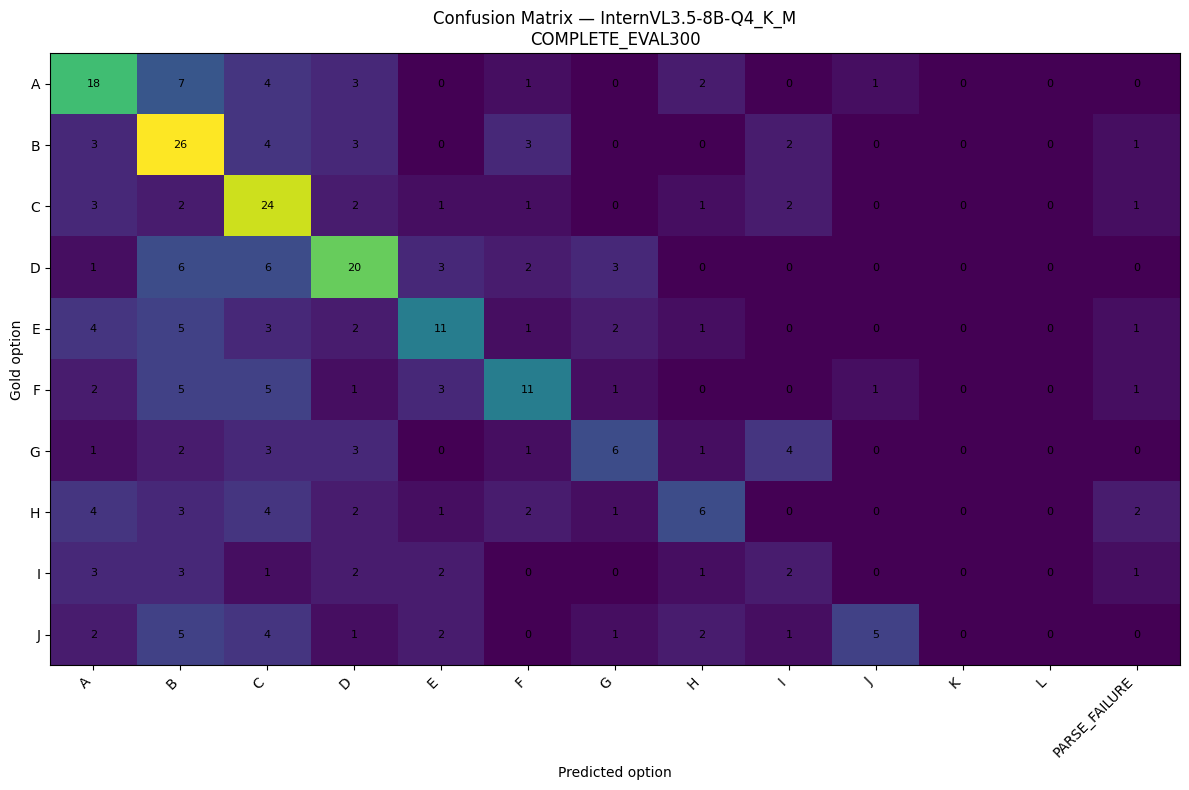

In [23]:
if n_valid:
    max_choices_observed = int(results['n_options'].max())
    observed_choice_labels = choice_letters(max_choices_observed)
    labels = observed_choice_labels + ['PARSE_FAILURE']

    cm = confusion_matrix(yt, yp, labels=labels)

    # Gold labels occupy only rows actually present in the dataset.
    gold_labels_present = [
        label for label in observed_choice_labels
        if label in set(yt)
    ]
    row_indices = [labels.index(label) for label in gold_labels_present]
    cm_display = cm[row_indices, :]

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(cm_display, aspect='auto')

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(range(len(gold_labels_present)))
    ax.set_yticklabels(gold_labels_present)

    ax.set_xlabel('Predicted option')
    ax.set_ylabel('Gold option')
    ax.set_title(f'Confusion Matrix — {MODEL}\n{status}')

    for i in range(cm_display.shape[0]):
        for j in range(cm_display.shape[1]):
            ax.text(
                j, i, str(cm_display[i, j]),
                ha='center', va='center', fontsize=8
            )

    fig.tight_layout()
    fig.savefig(
        PLOTS_DIR / 'confusion_matrix.png',
        dpi=180,
        bbox_inches='tight',
    )
    plt.show()


# 19. Two-stage runtime, throughput, token and output-length metrics


In [24]:
def num(series):
    return pd.to_numeric(series, errors="coerce")


def safe_sum(frame, column):
    return float(num(frame[column]).fillna(0).sum()) if len(frame) and column in frame else 0.0


answer_prompt_tokens = safe_sum(results, "prompt_tokens")
answer_completion_tokens = safe_sum(results, "completion_tokens")
answer_total_tokens = safe_sum(results, "total_tokens")
answer_latency_s = safe_sum(results, "latency_s")
sg_prompt_tokens = safe_sum(scene_graph_results, "prompt_tokens")
sg_completion_tokens = safe_sum(scene_graph_results, "completion_tokens")
sg_total_tokens = safe_sum(scene_graph_results, "total_tokens")
sg_latency_s = safe_sum(scene_graph_results, "latency_s")

eff = {
    "successful_scene_graph_calls": int(n_scene_graph_valid),
    "successful_final_answer_calls": int(n_valid),
    "successful_calls_total": int(n_scene_graph_valid + n_valid),
    "scene_graph_prompt_tokens": sg_prompt_tokens,
    "scene_graph_completion_tokens": sg_completion_tokens,
    "scene_graph_total_tokens": sg_total_tokens,
    "final_answer_prompt_tokens": answer_prompt_tokens,
    "final_answer_completion_tokens": answer_completion_tokens,
    "final_answer_total_tokens": answer_total_tokens,
    "p2_total_prompt_tokens": sg_prompt_tokens + answer_prompt_tokens,
    "p2_total_completion_tokens": sg_completion_tokens + answer_completion_tokens,
    "p2_total_tokens": sg_total_tokens + answer_total_tokens,
    "scene_graph_successful_latency_s": sg_latency_s,
    "final_answer_successful_latency_s": answer_latency_s,
    "p2_successful_latency_s": sg_latency_s + answer_latency_s,
    "p2_total_tokens_per_completed_item": (
        (sg_total_tokens + answer_total_tokens) / n_valid if n_valid else np.nan
    ),
    "scene_graph_json_valid_rate": (
        float(scene_graph_results["scene_graph_json_valid"].mean())
        if n_scene_graph_valid else np.nan
    ),
    "scene_graph_truncation_rate": (
        float(scene_graph_results["truncated"].mean())
        if n_scene_graph_valid else np.nan
    ),
    "final_answer_truncation_rate": float(results["truncated"].mean()) if n_valid else np.nan,
    "mean_scene_graph_completion_tokens": (
        float(num(scene_graph_results["completion_tokens"]).mean())
        if n_scene_graph_valid else np.nan
    ),
    "mean_final_answer_completion_tokens": (
        float(num(results["completion_tokens"]).mean()) if n_valid else np.nan
    ),
}
display(pd.DataFrame([eff]).T.rename(columns={0: "value"}).round(5))


,value
successful_scene_graph_calls,3.450000e+02
successful_final_answer_calls,3.000000e+02
successful_calls_total,6.450000e+02
scene_graph_prompt_tokens,4.376060e+05
scene_graph_completion_tokens,1.184200e+05
scene_graph_total_tokens,5.560260e+05
final_answer_prompt_tokens,5.527390e+05
final_answer_completion_tokens,1.526220e+05
final_answer_total_tokens,7.053610e+05
p2_total_prompt_tokens,9.903450e+05


# 20. Latency and completion-token distributions

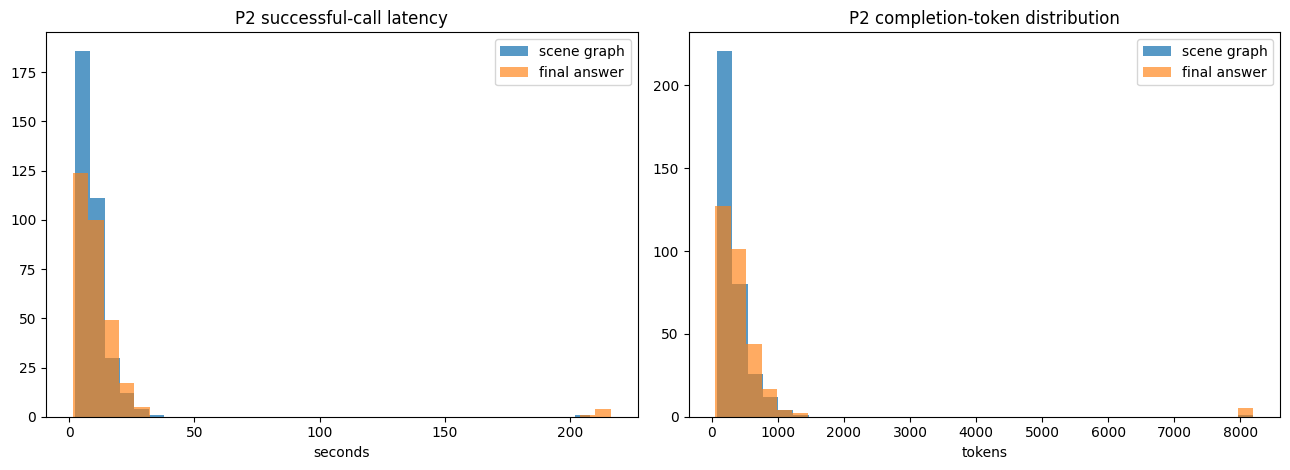

In [25]:
if n_scene_graph_valid or n_valid:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    if n_scene_graph_valid:
        axes[0].hist(num(scene_graph_results["latency_s"]).dropna(), bins=35, alpha=.75, label="scene graph")
        axes[1].hist(num(scene_graph_results["completion_tokens"]).dropna(), bins=35, alpha=.75, label="scene graph")
    if n_valid:
        axes[0].hist(num(results["latency_s"]).dropna(), bins=35, alpha=.65, label="final answer")
        axes[1].hist(num(results["completion_tokens"]).dropna(), bins=35, alpha=.65, label="final answer")
    axes[0].set_title("P2 successful-call latency")
    axes[0].set_xlabel("seconds")
    axes[1].set_title("P2 completion-token distribution")
    axes[1].set_xlabel("tokens")
    for axis in axes:
        axis.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "p2_latency_and_tokens.png", dpi=180, bbox_inches="tight")
    plt.show()


# 21. Subject, domain, difficulty, image-type and image-count analyses

In [26]:
DOMAIN={'Art and Design':['Art','Art_Theory','Design','Music'],'Business':['Accounting','Economics','Finance','Manage','Marketing'],
 'Science':['Biology','Chemistry','Geography','Math','Physics'],'Health and Medicine':['Basic_Medical_Science','Clinical_Medicine','Diagnostics_and_Laboratory_Medicine','Pharmacy','Public_Health'],
 'Humanities and Social Science':['History','Literature','Sociology','Psychology'],'Tech and Engineering':['Agriculture','Architecture_and_Engineering','Computer_Science','Electronics','Energy_and_Power','Materials','Mechanical_Engineering']}
S2D={s:d for d,ss in DOMAIN.items() for s in ss}
def group_acc(df,col): return df.groupby(col,dropna=False).agg(n=('sample_id','size'),correct=('answer_correct','sum'),accuracy=('answer_correct','mean'),mean_latency_s=('latency_s','mean'),mean_completion_tokens=('completion_tokens','mean')).reset_index()
if n_valid:
    results['domain']=results['subject'].map(S2D).fillna('Other/Unmapped')
    subject=group_acc(results,'subject'); domain=group_acc(results,'domain'); diff=group_acc(results,'topic_difficulty'); imgt=group_acc(results,'img_type'); imgc=group_acc(results,'image_count')
    subject.to_csv(SUBJECT_CSV,index=False); domain.to_csv(DOMAIN_CSV,index=False); diff.to_csv(DIFF_CSV,index=False); imgt.to_csv(IMGTYPE_CSV,index=False); imgc.to_csv(IMGCOUNT_CSV,index=False)
    print('Domain'); display(domain.round(4)); print('Difficulty'); display(diff.round(4)); print('Image count'); display(imgc.round(4)); print('Subject'); display(subject.round(4))


Domain


,domain,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Art and Design,40,18,0.4500,6.4178,233.0250
1,Business,50,23,0.4600,10.6009,406.1400
2,Health and Medicine,50,23,0.4600,7.3552,285.0200
3,Humanities and Social Science,40,21,0.5250,8.4172,294.3750
4,Science,50,20,0.4000,13.6257,519.0200
5,Tech and Engineering,70,24,0.3429,26.1044,1014.5286


Difficulty


,topic_difficulty,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Easy,88,45,0.5114,11.2573,429.6023
1,Hard,88,29,0.3295,15.6061,592.4659
2,Medium,124,55,0.4435,13.1921,505.4839


Image count


,image_count,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,1,278,115,0.4137,13.4236,521.4388
1,2,12,9,0.7500,13.6273,413.8333
2,3,1,0,0.0000,7.6594,241.0000
3,4,5,2,0.4000,9.1903,270.0000
4,5,4,3,0.7500,12.7236,276.2500


Subject


,subject,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Accounting,10,4,0.4,11.7201,466.1
1,Agriculture,10,5,0.5,6.0135,221.2
2,Architecture_and_Engineering,10,4,0.4,17.3375,694.1
3,Art,10,2,0.2,7.1223,271.8
4,Art_Theory,10,6,0.6,7.6492,262.9
5,Basic_Medical_Science,10,3,0.3,4.1899,156.6
6,Biology,10,1,0.1,9.1993,346.8
7,Chemistry,10,5,0.5,7.5997,279.0
8,Clinical_Medicine,10,5,0.5,9.4578,379.8
9,Computer_Science,10,4,0.4,12.1384,401.0


# 22. Answer-position bias diagnostics

,letter,gold_count,predicted_count
0,A,36,41
1,B,42,64
2,C,37,58
3,D,41,39
4,E,30,23
5,F,30,22
6,G,21,14
7,H,25,14
8,I,15,11
9,J,23,7


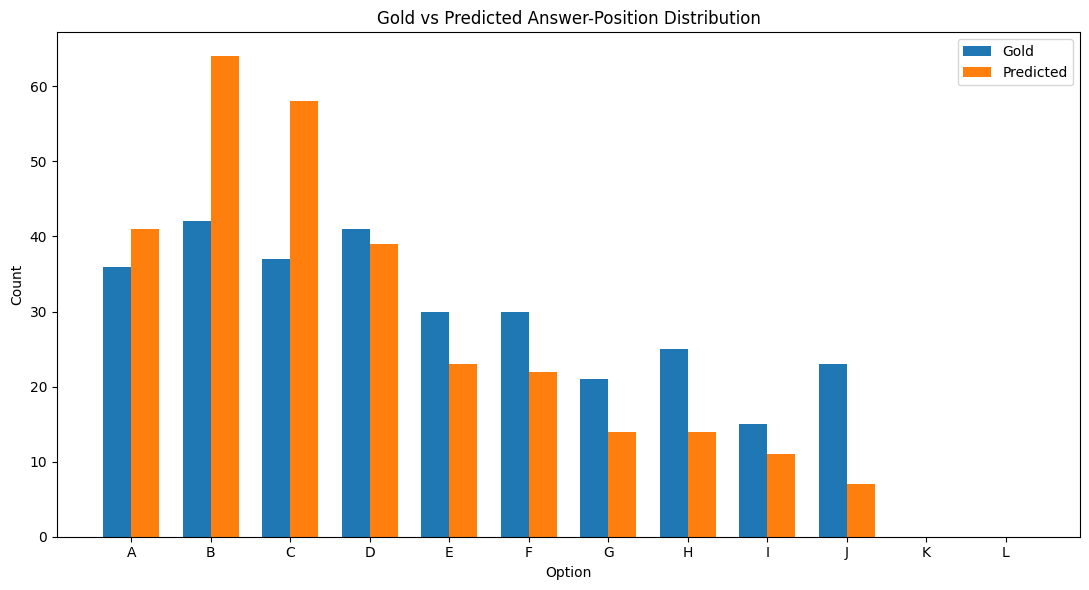

In [27]:
if n_valid:
    position_labels = choice_letters(int(results['n_options'].max()))

    g = results['gold_answer'].value_counts().reindex(position_labels, fill_value=0)
    p = results['answer_prediction'].value_counts().reindex(position_labels, fill_value=0)

    pos = pd.DataFrame({
        'letter': position_labels,
        'gold_count': g.values,
        'predicted_count': p.values,
    })
    display(pos)

    x = np.arange(len(position_labels))
    w = .35
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(x - w/2, pos['gold_count'], w, label='Gold')
    ax.bar(x + w/2, pos['predicted_count'], w, label='Predicted')
    ax.set_xticks(x)
    ax.set_xticklabels(position_labels)
    ax.set_xlabel('Option')
    ax.set_ylabel('Count')
    ax.set_title('Gold vs Predicted Answer-Position Distribution')
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR/'answer_positions.png', dpi=180, bbox_inches='tight')
    plt.show()


# 23. Consolidated paper-ready summary

In [28]:
summary = {
    'analysis_status': status,
    'complete': complete,
    'experiment_id': EXPERIMENT_ID,
    'experiment_signature': EXPERIMENT_SIGNATURE,
    'protocol_version': PROTOCOL_VERSION,
    'parser_version': PARSER_VERSION,
    'scene_graph_json_parser_version': SCENE_GRAPH_JSON_PARSER_VERSION,
    'parser_spec_sha256': PARSER_SPEC_SHA256,
    'scoring_signature': SCORING_SIGNATURE,
    'evaluation_cohort_id': EVALUATION_COHORT_ID,
    'model': MODEL,
    'provider': PROVIDER,
    'api_method': API_METHOD,
    'dataset_revision': DATASET_REVISION,
    'n_dataset': n_total,
    'n_valid': n_valid,
    'n_missing': n_total - n_valid,
    'coverage': coverage,
    'expected_scene_graph_units': expected_scene_graph_n,
    'n_scene_graph_valid': n_scene_graph_valid,
    'scene_graph_coverage': scene_graph_coverage,
    'scene_graph_json_valid_rate': (
        None if pd.isna(scene_graph_json_valid_rate)
        else float(scene_graph_json_valid_rate)
    ),
    'scene_graph_truncation_rate': (
        None if pd.isna(scene_graph_truncation_rate)
        else float(scene_graph_truncation_rate)
    ),
    'prompt_id': PROMPT_ID,
    'prompt_family': PROMPT_FAMILY,
    'prompt_suffix_sha256': PROMPT_SUFFIX_SHA,
    'prompt_template_sha256': PROMPT_TEMPLATE_SHA,
    'question_prefix_added': False,
    'selection_protocol': SELECTION_PROTOCOL_NAME,
    'selected_ids_sha256': SELECTED_IDS_CANONICAL_SHA256,
    'source_rows': len(source_ds),
    'classification': classification,
    'efficiency': eff,
    'primary_answer_parse_rate': None if pd.isna(parse_rate) else float(parse_rate),
    'exact_format_compliance_rate': None if pd.isna(fmt) else float(fmt),
    'primary_diagnostic_disagreement_rate': (
        None if pd.isna(diagnostic_disagreement_rate)
        else float(diagnostic_disagreement_rate)
    ),
    'truncation_rate': None if pd.isna(trunc) else float(trunc),
}
SUMMARY_JSON.write_text(
    json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8'
)
flat_summary = {
    'analysis_status': status,
    'complete': complete,
    'experiment_signature': EXPERIMENT_SIGNATURE,
    'protocol_version': PROTOCOL_VERSION,
    'parser_version': PARSER_VERSION,
    'scene_graph_json_parser_version': SCENE_GRAPH_JSON_PARSER_VERSION,
    'parser_spec_sha256': PARSER_SPEC_SHA256,
    'scoring_signature': SCORING_SIGNATURE,
    'model': MODEL,
    'provider': PROVIDER,
    'api_method': API_METHOD,
    'dataset_revision': DATASET_REVISION,
    'n_dataset': n_total,
    'n_valid': n_valid,
    'n_missing': n_total - n_valid,
    'coverage': coverage,
    'expected_scene_graph_units': expected_scene_graph_n,
    'n_scene_graph_valid': n_scene_graph_valid,
    'scene_graph_coverage': scene_graph_coverage,
    **classification,
    **eff,
}
pd.DataFrame([flat_summary]).to_csv(SUMMARY_CSV, index=False)
display(pd.DataFrame([flat_summary]).T.rename(columns={0: 'value'}))


,value
analysis_status,COMPLETE_EVAL300
complete,True
experiment_signature,42b07d48ca6e0d0f6ada16fb2d450ae389434176e80ffa...
protocol_version,P2_PER_IMAGE_SCENE_GRAPH_INTERNVL35_8B_Q4KM_EV...
parser_version,deterministic_final_line_answer_v1
...,...
scene_graph_json_valid_rate,0.895652
scene_graph_truncation_rate,0.002899
final_answer_truncation_rate,0.016667
mean_scene_graph_completion_tokens,343.246377


# 24. Professional qualitative audit viewer

In [29]:
def br(x): return html.escape(str(x or '')).replace('\n','<br>')
if GENERATE_HTML_AUDIT and n_valid:
    cards=[]
    for _,r in results.sort_values('execution_order').iterrows():
        imgs=''.join(f'<img src="{html.escape(p)}" style="max-width:420px;max-height:320px;margin:6px;border:1px solid #ddd">' for p in str(r['image_files']).split(';') if p)
        opts=json.loads(r['options_json']); ol='<ol type="A">'+''.join(f'<li>{html.escape(str(o))}</li>' for o in opts)+'</ol>'
        verdict='CORRECT' if bool(r['answer_correct']) else 'WRONG'
        cards.append(f"""<section style="border:1px solid #bbb;padding:16px;margin:18px 0"><h2>{html.escape(str(r['sample_id']))} — {verdict}</h2>
        <p><b>Subject:</b> {html.escape(str(r['subject']))}<br><b>Primary answer prediction:</b> {html.escape(str(r['answer_prediction']))}<br><b>Primary parse method:</b> {html.escape(str(r['answer_parse_method']))}<br><b>Exact requested format:</b> {html.escape(str(bool(r['exact_format_compliant'])))}<br><b>Gold:</b> {html.escape(str(r['gold_answer']))} — {html.escape(str(r['gold_option_text']))}</p>
        <div>{imgs}</div><h3>Scene graphs supplied to final stage</h3><div style="background:#eef6ff;padding:10px">{br(r['scene_graphs_json'])}</div><h3>Question</h3><p>{br(r['question'])}</p><h3>Options</h3>{ol}<h3>Visible model response</h3><div style="background:#f6f6f6;padding:10px">{br(r['visible_response'])}</div>
        <h3>Model-provided reasoning field</h3><div style="background:#fafafa;padding:10px">{br(r['reasoning_content'])}</div><h3>Gold explanation — intentionally excluded from inference records</h3><div style="background:#fff9e8;padding:10px">{br(r['gold_explanation'])}</div></section>""")
    doc=f'<!doctype html><html><head><meta charset="utf-8"><title>{EXPERIMENT_ID}</title></head><body style="font-family:Arial;max-width:1200px;margin:auto;padding:20px"><h1>{EXPERIMENT_ID}</h1><p><b>Status:</b> {status}; {n_valid}/{n_total}</p>'+''.join(cards)+'</body></html>'
    AUDIT_HTML.write_text(doc,encoding='utf-8'); print('Saved',AUDIT_HTML)


Saved /kaggle/working/internvl35_8b_q4km_p2_per_image_scene_graph_eval300_MAX8192_CTX16384_localinput_v1/audit_viewer.html


# 25. README_RESULTS.md and final completion gate

In [30]:
def pct(value):
    return "N/A" if value is None or pd.isna(value) else f"{100*float(value):.2f}%"

readme = f"""# {EXPERIMENT_ID}

## Status
**{status}** — final answers {n_valid}/{n_total}; scene graphs {n_scene_graph_valid}/{expected_scene_graph_n}.

## P2 method
- one scene-graph model call per unique image column in each sample
- question images use the `[Question Image k]` template
- option images use the `[Option A Image]` template
- repeated image references reuse one generated graph
- final message repeats each occurrence as `label → image → its graph`
- raw scene-graph visible output is injected verbatim
- JSON validity is audited and never used as a content-retry trigger

## Dataset
- `{DATASET_REPO}` / `{DATASET_CONFIG}` / `{DATASET_SPLIT}`
- revision `{DATASET_REVISION}`
- selected IDs SHA256 `{SELECTED_IDS_CANONICAL_SHA256}`
- 300 rows, 30 subjects, 10 items per subject

## Model and generation — both stages (local Kaggle input)
- model `{MODEL}` / `{QUANTIZATION}`
- local model `{MODEL_PATH}` / SHA256 `{MODEL_SHA_OBSERVED}`
- local projector `{MMPROJ_PATH}` / SHA256 `{MMPROJ_SHA_OBSERVED}`
- model SHA256 `{MODEL_SHA_OBSERVED}`
- projector SHA256 `{MMPROJ_SHA_OBSERVED}`
- local runtime `{LLAMA_BIN}` / SHA256 `{LLAMA_SHA_OBSERVED}`
- temperature `{TEMPERATURE}`; top-p/top-k not sent
- max output tokens `{MAX_TOKENS}`
- context `{CTX_SIZE}`; seed `{API_SEED}`; native thinking `{NATIVE_THINKING}` (no model-specific thinking request parameter; llama reasoning parser off)

## Prompt hashes
- scene-graph instruction `{SCENE_GRAPH_INSTRUCTION_SHA256}`
- question-image template `{QUESTION_IMAGE_SG_TEMPLATE_SHA256}`
- option-image template `{OPTION_IMAGE_SG_TEMPLATE_SHA256}`
- final-answer template `{FINAL_ANSWER_TEMPLATE_SHA256}`

## Scheduling and resume
- main timeout `{REQUEST_TIMEOUT_S}` seconds
- deferred timeout `{DEFERRED_REQUEST_TIMEOUT_S}` seconds
- scene graphs and final answers are checkpointed independently
- only missing graph units/final answers are sent after validated resume
- valid truncated, malformed-JSON and parse-failure outputs are retained

## Frozen scoring
- parser `{PARSER_VERSION}`
- parser SHA256 `{PARSER_SPEC_SHA256}`
- scene-graph JSON diagnostic parser `{SCENE_GRAPH_JSON_PARSER_VERSION}`
- primary outcome: deterministic last-line answer accuracy
- no random fallback; truncated final answers are incorrect

## Headline results
- primary answer accuracy: {pct(classification.get('primary_answer_accuracy'))}
- scene-graph JSON-valid rate: {pct(scene_graph_json_valid_rate)}
- scene-graph truncation rate: {pct(scene_graph_truncation_rate)}
- final-answer truncation rate: {pct(trunc)}
- total P2 tokens: {eff.get('p2_total_tokens', 'N/A')}

Final results are reportable only when both stages have complete coverage.
"""
README.write_text(readme, encoding="utf-8")
print(readme)


# MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P2-PerImageSceneGraph__LocalLlamaCpp__ImageGraphInterleaved__ValidatedTwoStageResume__LongDeferredTimeout__Temperature0__Seed42__MAX8192__CTX16384__LocalInput

## Status
**COMPLETE_EVAL300** — final answers 300/300; scene graphs 345/345.

## P2 method
- one scene-graph model call per unique image column in each sample
- question images use the `[Question Image k]` template
- option images use the `[Option A Image]` template
- repeated image references reuse one generated graph
- final message repeats each occurrence as `label → image → its graph`
- raw scene-graph visible output is injected verbatim
- JSON validity is audited and never used as a content-retry trigger

## Dataset
- `MMMU/MMMU_Pro` / `standard (10 options)` / `test`
- revision `563f3e84bb3b90893083a1f039cfa13077f2302b`
- selected IDs SHA256 `db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3`
- 300 rows, 30 subjects, 10 items per subject

## Model and generation — b

# 27. Suggested Methods wording for the InternVL3.5-8B P2 experiment

methods = f"""
We evaluated a two-stage per-image scene-graph prompting condition (P2) using
{MODEL} on the frozen balanced MMMU-Pro Eval300 cohort. For each unique image
column in a sample, the model was called once with the full question and answer
options to generate a question-conditioned scene graph in JSON format. Question
images and option images used separate role-specific templates. Every valid HTTP
200 scene-graph response was retained regardless of JSON validity or truncation,
and its visible text was injected verbatim into the final answer stage.

The final multimodal message followed the original numbered-marker occurrence
order. Each occurrence was represented by its semantic label, the corresponding
image, and immediately that image's scene graph. Repeated references repeated
the image–graph pair while reusing the one graph generated for that source image.

Both stages used the locally attached {MODEL} ({QUANTIZATION}) GGUF and F16
multimodal projector. The model, projector, and llama runtime were resolved from
the same Kaggle input source and verified by SHA-256
({MODEL_SHA_OBSERVED}, {MMPROJ_SHA_OBSERVED}, and {LLAMA_SHA_OBSERVED},
respectively). Local inference ran on two NVIDIA T4 GPUs.

Both stages used temperature {TEMPERATURE}, no explicit top-p/top-k, a
{MAX_TOKENS}-token output cap, context size {CTX_SIZE}, and fixed seed
{API_SEED}. No model-specific thinking request parameter or thinking system
prompt was supplied for InternVL3.5; llama reasoning parsing was disabled with
`--reasoning off`.

Scene graphs and final answers were checkpointed independently. Resume required
the exact experiment signature and record-level validation including image
hashes, semantic roles, graph text hashes, graph bundle hashes, and final pairing
order. Only infrastructure failures were retried; successful content was never
regenerated because of malformed JSON, answer formatting, or truncation. Final
accuracy used frozen parser {PARSER_VERSION} and was reportable only after
complete coverage of both P2 stages.
""".strip()

print(methods)
(WORKDIR / "METHODS_SUGGESTION.txt").write_text(methods + "\n", encoding="utf-8")
